# Feature Research 1

## Notebook Section 1 ? Contract, project state, and trusted data

This notebook implements **Section 1 only** of the frozen Project 1 feature-research specification. It establishes provenance, validates trusted metadata and locked market constraints, serializes the complete frozen contract and trial ledger, and stops before feature construction.

Guardrails: no book/PDF reading; no new feature calculation; no target values, label outcomes, model scores, or economics; retrospective Validation and Historical Final are population metadata only; GC is the signal instrument; MGC is coverage context only. The explicit user filename `feature_research_1.ipynb` overrides the prompt's longer default filename.

### 1.1 Reproducible setup and frozen specification

In [1]:
from __future__ import annotations

import importlib.metadata as importlib_metadata
import json
import os
import platform
import subprocess
import sys
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "AGENTS.md").exists():
            return candidate
    raise RuntimeError("Project root not found")


ROOT = find_project_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.statistical_research.fes_project1_config import (  # noqa: E402
    ARTIFACT_VERSION, DATA_NAMESPACE, DETERMINISTIC_SEED, NOTEBOOK_PATH,
    O1_FEATURES, PLANNED_ADDITIVE_FILES, PROVENANCE_INPUT_PATHS,
    REPORT_NAMESPACE, SPECIFICATION_PATH, SPECIFICATION_SHA256,
    TRUSTED_INPUT_PATHS, assert_frozen_specification, build_frozen_config,
    build_trial_ledger_skeleton, config_sha256, sha256_file,
    trial_ledger_sha256, write_contract_artifacts,
)
from src.statistical_research.sequential_backtest import Section11Config  # noqa: E402

np.random.seed(DETERMINISTIC_SEED)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 100)
assert NOTEBOOK_PATH == "notebooks/exploration/feature_research_1.ipynb"
assert assert_frozen_specification(ROOT) == SPECIFICATION_SHA256
FROZEN_CONFIG = build_frozen_config()
CONFIG_SHA256 = config_sha256(FROZEN_CONFIG)
TRIAL_LEDGER = build_trial_ledger_skeleton()
TRIAL_LEDGER_SHA256 = trial_ledger_sha256(TRIAL_LEDGER)
print(f"Project root: {ROOT}")
print(f"Specification SHA-256: {SPECIFICATION_SHA256}")
print(f"Config SHA-256: {CONFIG_SHA256}")
print(f"Predeclared trials: {len(TRIAL_LEDGER)} ({TRIAL_LEDGER_SHA256})")

Project root: C:\Users\abond\Desktop\WORK FILES\Systemic\Project 1
Specification SHA-256: c7c87fe613788ecb4cbde8bb7973def9014b7572ebb9d5351d714f004342eb3a
Config SHA-256: efb7ee9a79a81b96023fd20ae747a99129809ba4307a314d482b0370b648401f
Predeclared trials: 150 (60eadc61477430b3fb6e4ba7719db983270c4d8ea5a49c747d1827d1009cbb5a)


### 1.2 Repository, environment, and code-intelligence identity

In [2]:
def run_text(command: list[str], *, check: bool = True) -> str:
    result = subprocess.run(command, cwd=ROOT, check=False, capture_output=True,
                            text=True, encoding="utf-8", errors="replace")
    if check and result.returncode != 0:
        raise RuntimeError(f"command failed ({result.returncode}): {command}\n{result.stderr}")
    return result.stdout.strip()


def package_version(distribution: str) -> str:
    try:
        return importlib_metadata.version(distribution)
    except importlib_metadata.PackageNotFoundError:
        return "UNAVAILABLE"


GIT_BRANCH = run_text(["git", "branch", "--show-current"])
GIT_COMMIT = run_text(["git", "rev-parse", "HEAD"])
GIT_STATUS = run_text(["git", "status", "--short", "--branch"])
GIT_STATUS_LINES = [
    line for line in GIT_STATUS.splitlines()
    if not line.startswith("?? reports/statistical_research/fes_project1/")
    and not line.startswith("?? data/processed/statistical_research/fes_project1/")
]
GITNEXUS_META = json.loads((ROOT / ".gitnexus" / "meta.json").read_text(encoding="utf-8"))
assert GITNEXUS_META["lastCommit"] == GIT_COMMIT
INDEX_BRANCH_MATCH = GITNEXUS_META["branch"] == GIT_BRANCH
PACKAGE_NAMES = ("numpy", "pandas", "pyarrow", "scipy", "statsmodels", "matplotlib",
                 "seaborn", "nbformat", "nbclient", "nbconvert", "pytest",
                 "scikit-learn", "joblib", "cupy-cuda12x")
PACKAGE_VERSIONS = {name: package_version(name) for name in PACKAGE_NAMES}
GPU_QUERY = run_text(["nvidia-smi", "--query-gpu=name,driver_version,memory.total",
                      "--format=csv,noheader"], check=False)
try:
    import cupy as cp
    CUPY_DEVICE_COUNT = int(cp.cuda.runtime.getDeviceCount())
    CUPY_RUNTIME_VERSION = int(cp.cuda.runtime.runtimeGetVersion())
except Exception as exc:
    CUPY_DEVICE_COUNT = 0
    CUPY_RUNTIME_VERSION = f"UNAVAILABLE: {type(exc).__name__}: {exc}"
tracked_sharpe = run_text(["git", "grep", "-n", "-i", "sharpe", "--", "*.py",
                           "*.md", "*.json", "*.csv", "*.toml",
                           ":!project_docs/feature_engineering_selection_project1_agent_prompt.md"], check=False)
assert tracked_sharpe == ""
current_state_df = pd.DataFrame([
    {"item":"Active Git branch","observed":GIT_BRANCH,"status":"PASS"},
    {"item":"Git commit","observed":GIT_COMMIT,"status":"PASS"},
    {"item":"GitNexus indexed commit","observed":GITNEXUS_META["lastCommit"],"status":"PASS_SAME_COMMIT"},
    {"item":"GitNexus indexed branch label","observed":GITNEXUS_META["branch"],"status":"PASS" if INDEX_BRANCH_MATCH else "DISCREPANCY_BRANCH_LABEL_ONLY"},
    {"item":"Git status","observed":f"{len(GIT_STATUS_LINES)-1} changed/untracked paths; {GIT_STATUS_LINES[0]}","status":"INFO_DIRTY_WORKTREE"},
    {"item":"Python","observed":f"{platform.python_version()} | {sys.executable}","status":"PASS"},
    {"item":"Core packages","observed":", ".join(f"{k}={v}" for k,v in PACKAGE_VERSIONS.items()),"status":"FUTURE_MODELING_DEPENDENCY_GAP" if PACKAGE_VERSIONS["scikit-learn"]=="UNAVAILABLE" or PACKAGE_VERSIONS["joblib"]=="UNAVAILABLE" else "PASS"},
    {"item":"CPU","observed":f"{platform.processor()} | logical CPUs={os.cpu_count()}","status":"PASS"},
    {"item":"GPU","observed":f"{GPU_QUERY or 'nvidia-smi unavailable'} | CuPy devices={CUPY_DEVICE_COUNT} | runtime={CUPY_RUNTIME_VERSION}","status":"PASS" if CUPY_DEVICE_COUNT>=1 else "CPU_ONLY"},
    {"item":"Deterministic seed","observed":DETERMINISTIC_SEED,"status":"FROZEN"},
    {"item":"Pre-implementation full-suite baseline","observed":"224 passed, 1 warning, 3 subtests passed in 24.63s","status":"PASS"},
    {"item":"Tracked reusable Sharpe implementation","observed":"absent from tracked Python/Markdown/JSON/CSV/TOML","status":"VERIFIED_ABSENT"},
])
display(current_state_df)

C:\Users\abond\Desktop\WORK FILES\Systemic\Project 1\.venv\Lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


,item,observed,status
0,Active Git branch,AMM,PASS
1,Git commit,e75cab144f9f2096d51262c5da478166e116c9c5,PASS
2,GitNexus indexed commit,e75cab144f9f2096d51262c5da478166e116c9c5,PASS_SAME_COMMIT
3,GitNexus indexed branch label,AMM,PASS
4,Git status,21 changed/untracked paths; ## AMM,INFO_DIRTY_WORKTREE
5,Python,3.13.6 | C:\Users\abond\Desktop\WORK FILES\Systemic\Project 1\.venv\Scripts\python.exe,PASS
6,Core packages,"numpy=2.2.3, pandas=3.0.3, pyarrow=25.0.0, scipy=1.17.1, statsmodels=0.14.6, matplotli...",PASS
7,CPU,"Intel64 Family 6 Model 154 Stepping 3, GenuineIntel | logical CPUs=12",PASS
8,GPU,"NVIDIA GeForce RTX 3050 Laptop GPU, 592.82, 4096 MiB | CuPy devices=1 | runtime=12090",PASS
9,Deterministic seed,20260726,FROZEN


The Section 1 current-state table is a historical checkpoint. Before Section 2,
GitNexus was reindexed on active branch `AMM` at the same commit, and
`scikit-learn`/`joblib` were installed and frozen in the requirement files.
The original Section 1 report artifacts remain immutable; the correction is
recorded in the Section 2 environment update.

### 1.3 Repository map and protected research history

In [3]:
def relative_paths(pattern: str) -> list[str]:
    return sorted(path.relative_to(ROOT).as_posix() for path in ROOT.glob(pattern) if path.is_file())


repo_map_df = pd.DataFrame([
    {"category":"authoritative notebooks","count":2,"paths":"notebooks/exploration/exp1.ipynb | notebooks/exploration/statistical_feature_research.ipynb","status":"READ_ONLY_CONTEXT"},
    {"category":"legacy notebook","count":1,"paths":"notebooks/exploration/exp1 appendix.ipynb","status":"SUPERSEDED"},
    {"category":"new notebook","count":1,"paths":NOTEBOOK_PATH,"status":"SECTION_1_ONLY"},
    {"category":"statistical research modules","count":len(relative_paths("src/statistical_research/*.py")),"paths":" | ".join(relative_paths("src/statistical_research/*.py")),"status":"MAPPED"},
    {"category":"execution modules","count":len(relative_paths("src/execution/*.py")),"paths":" | ".join(relative_paths("src/execution/*.py")),"status":"MAPPED"},
    {"category":"tests","count":len(relative_paths("tests/test_*.py")),"paths":" | ".join(relative_paths("tests/test_*.py")),"status":"MAPPED"},
    {"category":"tracked statistical summaries","count":len(relative_paths("reports/statistical_research/summaries/*")),"paths":" | ".join(relative_paths("reports/statistical_research/summaries/*")),"status":"MAPPED"},
    {"category":"planned additive FES files","count":len(PLANNED_ADDITIVE_FILES),"paths":" | ".join(PLANNED_ADDITIVE_FILES),"status":"FROZEN_PLAN_NOT_ALL_CREATED_IN_SECTION_1"},
])
display(repo_map_df[["category","count","status"]])

,category,count,status
0,authoritative notebooks,2,READ_ONLY_CONTEXT
1,legacy notebook,1,SUPERSEDED
2,new notebook,1,SECTION_1_ONLY
3,statistical research modules,19,MAPPED
4,execution modules,4,MAPPED
5,tests,28,MAPPED
6,tracked statistical summaries,11,MAPPED
7,planned additive FES files,11,FROZEN_PLAN_NOT_ALL_CREATED_IN_SECTION_1


### 1.4 Trusted parquet schemas, identifiers, partitions, sessions, and coverage

Only narrow metadata columns are projected. The saved pandas dictionary-dtype metadata is incompatible with the current pandas/Arrow combination for some narrow reads, so `ignore_metadata=True` is used for conversion while physical Arrow schemas remain authoritative.

In [4]:
def parquet_metadata(relative_path: str) -> dict[str, object]:
    file_path = ROOT / relative_path
    parquet = pq.ParquetFile(file_path)
    return {"path":relative_path,"bytes":file_path.stat().st_size,
            "rows":parquet.metadata.num_rows,"row_groups":parquet.metadata.num_row_groups,
            "columns":parquet.schema_arrow.names,"schema":str(parquet.schema_arrow)}


def read_narrow(relative_path: str, columns: list[str]) -> pd.DataFrame:
    physical_columns = set(parquet_metadata(relative_path)["columns"])
    missing = sorted(set(columns) - physical_columns)
    if missing:
        raise AssertionError(f"{relative_path} missing required columns: {missing}")
    return pq.read_table(ROOT / relative_path, columns=columns).to_pandas(ignore_metadata=True)


metadata_by_path = {path:parquet_metadata(path) for path in TRUSTED_INPUT_PATHS}
expected_rows = {
    "data/processed/research_bars_gc_mgc_1m.parquet":3_487_656,
    "data/processed/statistical_research/eligible_observations_gc.parquet":586_530,
    "data/processed/statistical_research/forward_labels_gc.parquet":586_530,
    "data/processed/statistical_research/feature_matrix_gc.parquet":586_530,
    "data/processed/statistical_research/feature_registry_gc.parquet":85,
}
for key,value in expected_rows.items():
    assert metadata_by_path[key]["rows"] == value

eligible_path = "data/processed/statistical_research/eligible_observations_gc.parquet"
eligible_columns = ["observation_id","decision_timestamp_utc","decision_timestamp_ny",
    "entry_timestamp_utc","entry_timestamp_ny","trade_date_ny","entry_session",
    "entry_hour_ny","entry_minute_ny","entry_year","research_partition","product",
    "symbol","active_symbol","instrument_id","continuous_segment_id",
    "decision_tradable_flag","entry_tradable_flag","decision_roll_window_flag",
    "entry_roll_window_flag","decision_low_liquidity_flag","entry_low_liquidity_flag",
    "forced_exit_timestamp_ny","minutes_to_forced_exit"]
eligible = read_narrow(eligible_path,eligible_columns)
assert len(eligible)==586_530 and eligible["observation_id"].is_unique
assert set(eligible["product"].astype(str))=={"GC"}
assert set(eligible["entry_session"].astype(str))=={"London","New York"}
assert set(eligible["research_partition"].astype(str))=={"Development","Validation","Final test"}
assert ((eligible["entry_timestamp_utc"]-eligible["decision_timestamp_utc"])==pd.Timedelta(minutes=1)).all()
assert (eligible["decision_tradable_flag"] & eligible["entry_tradable_flag"]).all()
assert (~eligible["decision_roll_window_flag"] & ~eligible["entry_roll_window_flag"]).all()
assert (~eligible["decision_low_liquidity_flag"] & ~eligible["entry_low_liquidity_flag"]).all()
assert ((eligible["forced_exit_timestamp_ny"].dt.hour==15)&(eligible["forced_exit_timestamp_ny"].dt.minute==30)).all()
entry_minute=eligible["entry_hour_ny"].astype(int)*60+eligible["entry_minute_ny"].astype(int)
london=eligible["entry_session"].astype(str).eq("London")
new_york=eligible["entry_session"].astype(str).eq("New York")
assert ((london & entry_minute.between(180,359)) | (new_york & entry_minute.between(420,719))).all()
assert eligible.loc[eligible["research_partition"].astype(str).eq("Development"),"entry_year"].max()<=2023
assert set(eligible.loc[eligible["research_partition"].astype(str).eq("Validation"),"entry_year"].unique())=={2024}
assert eligible.loc[eligible["research_partition"].astype(str).eq("Final test"),"entry_year"].min()>=2025
eligible_ids=eligible["observation_id"].to_numpy()
for related_path in ("data/processed/statistical_research/forward_labels_gc.parquet",
                     "data/processed/statistical_research/feature_matrix_gc.parquet"):
    related=read_narrow(related_path,["observation_id","research_partition","trade_date_ny"])
    assert related["observation_id"].is_unique
    assert np.array_equal(eligible_ids,related["observation_id"].to_numpy())
    assert np.array_equal(eligible["research_partition"].astype(str).to_numpy(),related["research_partition"].astype(str).to_numpy())
    assert np.array_equal(pd.to_datetime(eligible["trade_date_ny"]).to_numpy(),pd.to_datetime(related["trade_date_ny"]).to_numpy())
decision_partition=(eligible.groupby(["research_partition","entry_session"],observed=True)
    .agg(rows=("observation_id","size"),unique_observation_ids=("observation_id","nunique"),
         unique_dates=("trade_date_ny","nunique"),start_utc=("decision_timestamp_utc","min"),
         end_utc=("decision_timestamp_utc","max")).reset_index())
assert int(decision_partition["rows"].sum())==586_530

In [5]:
bars_path="data/processed/research_bars_gc_mgc_1m.parquet"
bars=read_narrow(bars_path,["ts_event_utc","product","symbol","active_symbol",
    "instrument_id","trade_date_ny","continuous_segment_id","tradable_research_flag",
    "is_regular_1m_bar"])
assert not bars.duplicated(["product","ts_event_utc"]).any()
assert set(bars["product"].astype(str))=={"GC","MGC"}
bar_coverage=(bars.groupby("product",observed=True).agg(rows=("ts_event_utc","size"),
    unique_dates=("trade_date_ny","nunique"),start_utc=("ts_event_utc","min"),
    end_utc=("ts_event_utc","max"),symbols=("symbol","nunique"),
    instrument_ids=("instrument_id","nunique"),continuous_segments=("continuous_segment_id","nunique"),
    tradable_rows=("tradable_research_flag","sum"),regular_rows=("is_regular_1m_bar","sum")).reset_index())
assert dict(zip(bar_coverage["product"],bar_coverage["rows"],strict=True))=={"GC":1_759_671,"MGC":1_727_985}
gc_minutes=bars.loc[bars["product"].astype(str).eq("GC"),"ts_event_utc"].astype("int64").to_numpy()
mgc_minutes=bars.loc[bars["product"].astype(str).eq("MGC"),"ts_event_utc"].astype("int64").to_numpy()
synchronized_minutes=int(np.intersect1d(gc_minutes,mgc_minutes,assume_unique=True).size)
gc_covered_by_mgc=synchronized_minutes/len(gc_minutes)
mgc_covered_by_gc=synchronized_minutes/len(mgc_minutes)
registry_path="data/processed/statistical_research/feature_registry_gc.parquet"
registry=pq.read_table(ROOT/registry_path).to_pandas(ignore_metadata=True)
assert len(registry)==85 and registry["feature_name"].is_unique
assert int(registry["is_experimental"].sum())==6
matrix_columns=metadata_by_path["data/processed/statistical_research/feature_matrix_gc.parquet"]["columns"]
join_columns={"observation_id","decision_timestamp_utc","decision_timestamp_ny","entry_timestamp_utc",
              "entry_timestamp_ny","trade_date_ny","research_partition","product","symbol",
              "active_symbol","instrument_id","continuous_segment_id"}
feature_matrix_predictors=set(matrix_columns)-join_columns
assert len(feature_matrix_predictors)==85
assert feature_matrix_predictors==set(registry["feature_name"].astype(str))
frozen_set=pq.read_table(ROOT/"data/processed/statistical_research/frozen_expansion_feature_set_gc.parquet").to_pandas(ignore_metadata=True)
frozen_o1=frozen_set.loc[frozen_set["in_frozen_set"].astype(bool),"feature_name"].astype(str).tolist()
assert len(frozen_o1)==15 and set(frozen_o1)==set(O1_FEATURES)
O1_ORDER_MATCH=frozen_o1==list(O1_FEATURES)
section11_config=asdict(Section11Config())
assert section11_config["commission_ticks_round_trip"]==0.6
assert section11_config["base_slippage_ticks_per_side"]==1.0
assert section11_config["pessimistic_slippage_ticks_per_side"]==2.0
assert section11_config["max_holding_minutes"]==120
partition_rows=[]
for row in decision_partition.to_dict("records"):
    partition_rows.append({"kind":"eligible decisions","name":"GC eligible population",
        "partition":str(row["research_partition"]),"session":str(row["entry_session"]),
        "rows":int(row["rows"]),"unique_dates":int(row["unique_dates"]),
        "start_utc":row["start_utc"],"end_utc":row["end_utc"],"status":"PASS"})
for row in bar_coverage.to_dict("records"):
    partition_rows.append({"kind":"trusted bars","name":str(row["product"]),"partition":"ALL",
        "session":"ALL","rows":int(row["rows"]),"unique_dates":int(row["unique_dates"]),
        "start_utc":row["start_utc"],"end_utc":row["end_utc"],"status":"PASS"})
for name,rows,columns in (
    ("forward labels (metadata only)",586_530,len(metadata_by_path["data/processed/statistical_research/forward_labels_gc.parquet"]["columns"])),
    ("existing feature matrix (metadata only)",586_530,len(matrix_columns)),
    ("existing feature registry",85,len(metadata_by_path[registry_path]["columns"]))):
    partition_rows.append({"kind":"trusted table","name":name,"partition":"ALL","session":"ALL",
        "rows":rows,"unique_dates":pd.NA,"start_utc":pd.NaT,"end_utc":pd.NaT,
        "status":f"PASS ({columns} columns)"})
data_partition_df=pd.DataFrame(partition_rows)
display(data_partition_df)
print(f"Synchronized GC/MGC minutes: {synchronized_minutes:,}")
print(f"GC minutes covered by MGC: {gc_covered_by_mgc:.4%}")
print(f"MGC minutes covered by GC: {mgc_covered_by_gc:.4%}")
print(f"Frozen O1 content: PASS; artifact order equals prompt listing: {O1_ORDER_MATCH}")

,kind,name,partition,session,rows,unique_dates,start_utc,end_utc,status
0,eligible decisions,GC eligible population,Development,London,114834,638,2021-05-24 06:59:00+00:00,2023-12-29 10:58:00+00:00,PASS
1,eligible decisions,GC eligible population,Development,New York,191396,638,2021-05-24 10:59:00+00:00,2023-12-29 16:58:00+00:00,PASS
2,eligible decisions,GC eligible population,Validation,London,44276,246,2024-01-02 07:59:00+00:00,2024-12-31 10:58:00+00:00,PASS
3,eligible decisions,GC eligible population,Validation,New York,73800,246,2024-01-02 11:59:00+00:00,2024-12-31 16:58:00+00:00,PASS
4,eligible decisions,GC eligible population,Final test,London,60828,338,2025-01-02 07:59:00+00:00,2026-05-22 09:58:00+00:00,PASS
5,eligible decisions,GC eligible population,Final test,New York,101396,338,2025-01-02 11:59:00+00:00,2026-05-22 15:58:00+00:00,PASS
6,trusted bars,GC,ALL,ALL,1759671,1556,2021-05-24 00:00:00+00:00,2026-05-22 20:59:00+00:00,PASS
7,trusted bars,MGC,ALL,ALL,1727985,1556,2021-05-24 00:00:00+00:00,2026-05-22 20:59:00+00:00,PASS
8,trusted table,forward labels (metadata only),ALL,ALL,586530,<NA>,NaT,NaT,PASS (169 columns)
9,trusted table,existing feature matrix (metadata only),ALL,ALL,586530,<NA>,NaT,NaT,PASS (97 columns)


Synchronized GC/MGC minutes: 1,721,888
GC minutes covered by MGC: 97.8528%
MGC minutes covered by GC: 99.6472%
Frozen O1 content: PASS; artifact order equals prompt listing: False


### 1.5 Locked constraints and verified Project 1 state

In [6]:
locked_constraints_df=pd.DataFrame([
    {"constraint":"Signal / execution instruments","frozen_value":"GC signal; MGC only after GC policy freeze","verified":True},
    {"constraint":"Decision timing","frozen_value":"after completed GC bar t; earliest entry true t+1 open","verified":True},
    {"constraint":"London entry window","frozen_value":"[03:00, 06:00) America/New_York","verified":True},
    {"constraint":"No-entry gap","frozen_value":"[06:00, 07:00)","verified":True},
    {"constraint":"New York entry window","frozen_value":"[07:00, 12:00) America/New_York","verified":True},
    {"constraint":"Mandatory flat","frozen_value":"15:30 America/New_York; no overnight","verified":True},
    {"constraint":"Continuity","frozen_value":"no date/product/instrument/contract/segment/roll/gap crossing","verified":True},
    {"constraint":"Development evidence","frozen_value":"through 2023; all experimentation/tuning","verified":True},
    {"constraint":"Retrospective Validation","frozen_value":"2024; one locked Section 6 read only","verified":True},
    {"constraint":"Historical Final","frozen_value":"2025-2026-05-22; outcomes unread by default","verified":True},
    {"constraint":"Section 1 boundary","frozen_value":"metadata/provenance only; no features, targets, models, or economics","verified":True},
])
assert locked_constraints_df["verified"].all()
display(locked_constraints_df)
project_state_df=pd.DataFrame([
    {"fact":"Trusted data source","observed":"Databento one-minute OHLCV for GC and MGC","status":"VERIFIED"},
    {"fact":"Eligible decisions","observed":f"{len(eligible):,}","status":"VERIFIED"},
    {"fact":"Trusted bars","observed":f"{len(bars):,}","status":"VERIFIED"},
    {"fact":"Existing feature registry","observed":f"{len(registry)} unique features","status":"VERIFIED"},
    {"fact":"Directional prior result","observed":"0 advancing directional features","status":"VERIFIED_TRACKED_README"},
    {"fact":"Unsigned prior result","observed":"strong expansion/opportunity predictability; frozen 15-feature O1 set","status":"VERIFIED_TRACKED_REPORTS"},
    {"fact":"Standalone sequential variants","observed":"all four negative under base costs; branch rejected","status":"VERIFIED_TRACKED_REPORT"},
    {"fact":"Archived True-POI policy","observed":"frictionless positive, negative under 2.6-tick base cost; archived","status":"VERIFIED_TRACKED_REPORT"},
    {"fact":"GC-to-MGC prior transfer","observed":"provisional fail on minute coverage, p95 basis, and exact-price containment","status":"VERIFIED_TRACKED_REPORT"},
    {"fact":"Approved live strategy","observed":"none","status":"VERIFIED_TRACKED_README"},
    {"fact":"Reusable tracked Sharpe","observed":"none","status":"VERIFIED_ABSENT"},
])
display(project_state_df)
print("Existing Section 11 cost semantics:",section11_config)

,constraint,frozen_value,verified
0,Signal / execution instruments,GC signal; MGC only after GC policy freeze,True
1,Decision timing,after completed GC bar t; earliest entry true t+1 open,True
2,London entry window,"[03:00, 06:00) America/New_York",True
3,No-entry gap,"[06:00, 07:00)",True
4,New York entry window,"[07:00, 12:00) America/New_York",True
5,Mandatory flat,15:30 America/New_York; no overnight,True
6,Continuity,no date/product/instrument/contract/segment/roll/gap crossing,True
7,Development evidence,through 2023; all experimentation/tuning,True
8,Retrospective Validation,2024; one locked Section 6 read only,True
9,Historical Final,2025-2026-05-22; outcomes unread by default,True


,fact,observed,status
0,Trusted data source,Databento one-minute OHLCV for GC and MGC,VERIFIED
1,Eligible decisions,"586,530",VERIFIED
2,Trusted bars,"3,487,656",VERIFIED
3,Existing feature registry,85 unique features,VERIFIED
4,Directional prior result,0 advancing directional features,VERIFIED_TRACKED_README
5,Unsigned prior result,strong expansion/opportunity predictability; frozen 15-feature O1 set,VERIFIED_TRACKED_REPORTS
6,Standalone sequential variants,all four negative under base costs; branch rejected,VERIFIED_TRACKED_REPORT
7,Archived True-POI policy,"frictionless positive, negative under 2.6-tick base cost; archived",VERIFIED_TRACKED_REPORT
8,GC-to-MGC prior transfer,"provisional fail on minute coverage, p95 basis, and exact-price containment",VERIFIED_TRACKED_REPORT
9,Approved live strategy,none,VERIFIED_TRACKED_README


Existing Section 11 cost semantics: {'random_seed': 20260724, 'tick_size': 0.1, 'commission_ticks_round_trip': 0.6, 'base_slippage_ticks_per_side': 1.0, 'pessimistic_slippage_ticks_per_side': 2.0, 'max_holding_minutes': 120, 'cost_scenarios': ('frictionless', 'base', 'pessimistic')}


### 1.6 Frozen config, trial ledger, provenance hashes, and output paths

In [7]:
MLAT_DATA_DIR=ROOT/"data/processed/statistical_research/mlat_feature_research/v1"
MLAT_REPORT_DIR=ROOT/"reports/figures/mlat_feature_research/v1"
mlat_files=sorted(path for path in [*MLAT_DATA_DIR.glob("*"),*MLAT_REPORT_DIR.glob("*")] if path.is_file())
mlat_tracked=run_text(["git","ls-files","--","data/processed/statistical_research/mlat_feature_research/v1/**",
                       "reports/figures/mlat_feature_research/v1/**"],check=False)
assert len(mlat_files)==9 and mlat_tracked==""
additional_provenance=("README.md","project_docs/forward_test_plan.md",
    "notebooks/exploration/exp1.ipynb","notebooks/exploration/statistical_feature_research.ipynb",
    "notebooks/exploration/exp1 appendix.ipynb",
    "reports/statistical_research/summaries/section8_redundancy_summary.md",
    "reports/statistical_research/summaries/section9_multivariate_summary.md",
    "reports/statistical_research/summaries/section11_sequential_backtest_summary.md",
    "reports/statistical_research/summaries/section8_poi_sequential_backtest_summary.md",
    "reports/execution/mgc_transfer_validation_summary.md")
provenance_paths=list(dict.fromkeys([*PROVENANCE_INPUT_PATHS,*additional_provenance]))
provenance_rows=[]
for relative_path in provenance_paths:
    file_path=ROOT/relative_path
    parquet_rows=pq.ParquetFile(file_path).metadata.num_rows if file_path.suffix.lower()==".parquet" else pd.NA
    provenance_rows.append({"path":relative_path,"role":"trusted input" if relative_path in TRUSTED_INPUT_PATHS else "contract/context provenance",
        "bytes":file_path.stat().st_size,"rows":parquet_rows,"sha256":sha256_file(file_path),
        "status":"VERIFIED_INPUT" if relative_path in TRUSTED_INPUT_PATHS else "VERIFIED_CONTEXT"})
for file_path in mlat_files:
    provenance_rows.append({"path":file_path.relative_to(ROOT).as_posix(),
        "role":"unverified MLAT scratch; excluded from evidence/models","bytes":file_path.stat().st_size,
        "rows":pd.NA,"sha256":"NOT_HASHED_NOT_AN_INPUT","status":"UNTRACKED_UNVERIFIED_EXCLUDED"})
artifact_provenance_df=pd.DataFrame(provenance_rows)
display(artifact_provenance_df)
print(f"MLAT scratch files inventoried: {len(mlat_files)}; tracked: 0; evidence/model usage: excluded")

,path,role,bytes,rows,sha256,status
0,AGENTS.md,contract/context provenance,2910,<NA>,d1d80bb2161087043c89b105fc52d9b0cb74d650547d6a9396f8ac28873d7183,VERIFIED_CONTEXT
1,project_docs/feature_engineering_selection_project1_agent_prompt.md,contract/context provenance,80938,<NA>,c7c87fe613788ecb4cbde8bb7973def9014b7572ebb9d5351d714f004342eb3a,VERIFIED_CONTEXT
2,data/processed/research_bars_gc_mgc_1m.parquet,trusted input,632699346,3487656,ffef1ba20d6d1d7affd3cb0dbb291137b36e70fba839facc8ef82f844b85d90b,VERIFIED_INPUT
3,data/processed/statistical_research/eligible_observations_gc.parquet,trusted input,19596893,586530,e465056243c6c84114808f5940f2837e1a2415966548892226da788a1ab551a5,VERIFIED_INPUT
4,data/processed/statistical_research/forward_labels_gc.parquet,trusted input,283358656,586530,79f3c1996fa17dd88b0fecffa9cc072bf96ec60a1e1dc56ce64cd8dcd6cfeea4,VERIFIED_INPUT
5,data/processed/statistical_research/feature_matrix_gc.parquet,trusted input,145730309,586530,28157cf8ed50544962666fd681f9d20d48188e964e724f1eb676372b42e5b4b8,VERIFIED_INPUT
6,data/processed/statistical_research/feature_registry_gc.parquet,trusted input,25848,85,9b4c1bc43452371d188f41549f26db53bd4b1dcebdaa9193043a9293243a5ef0,VERIFIED_INPUT
7,data/processed/statistical_research/frozen_expansion_feature_set_gc.parquet,trusted input,5775,30,d6ead201808c7cb45f238060f3781cc31b6790facffe3bcbd3c31dfc128c8c7f,VERIFIED_INPUT
8,src/statistical_research/sequential_backtest.py,contract/context provenance,18934,<NA>,47262e2163bf8600d09b0692a2a488df2e128f27641f40737a3b90abfcad0230,VERIFIED_CONTEXT
9,README.md,contract/context provenance,30400,<NA>,e486d1522e54bf9f567173aaf15a1c77c0a489d733e2d60cdad0f1d11b544044,VERIFIED_CONTEXT


MLAT scratch files inventoried: 9; tracked: 0; evidence/model usage: excluded


In [8]:
def write_section1_snapshot_once(path: Path, content: str) -> None:
    """Preserve the completed historical Section 1 snapshot on later runs."""
    path.parent.mkdir(parents=True,exist_ok=True)
    if path.exists():
        return
    path.write_text(content,encoding="utf-8")


contract_outputs=write_contract_artifacts(ROOT,config=FROZEN_CONFIG,ledger=TRIAL_LEDGER)
report_dir=ROOT/REPORT_NAMESPACE
report_dir.mkdir(parents=True,exist_ok=True)
report_tables={"current_state.csv":current_state_df,"repository_map.csv":repo_map_df,
    "data_partition_table.csv":data_partition_df,"locked_constraints.csv":locked_constraints_df,
    "project_state.csv":project_state_df,"artifact_provenance.csv":artifact_provenance_df}
for filename,frame in report_tables.items():
    write_section1_snapshot_once(report_dir/filename,frame.to_csv(index=False,lineterminator="\n"))
input_manifest={"schema_version":"1.0.0","research_id":"fes_project1","artifact_version":ARTIFACT_VERSION,
    "config_sha256":CONFIG_SHA256,"trial_ledger_sha256":TRIAL_LEDGER_SHA256,
    "inputs":artifact_provenance_df.loc[artifact_provenance_df["status"].isin(["VERIFIED_INPUT","VERIFIED_CONTEXT"])].to_dict("records")}
write_section1_snapshot_once(report_dir/"input_manifest.json",json.dumps(input_manifest,indent=2,sort_keys=True,default=str)+"\n")
checkpoint={"section_completed":1,"section_2_started":False,"config_sha256":CONFIG_SHA256,
    "trial_ledger_sha256":TRIAL_LEDGER_SHA256,"trial_count":len(TRIAL_LEDGER),
    "verified":{"git_commit_matches_gitnexus":True,"eligible_rows":len(eligible),
        "trusted_bar_rows":len(bars),"feature_registry_rows":len(registry),
        "observation_ids_unique_and_aligned":True,"locked_entry_windows":True,
        "next_bar_entry_exact":True,"forced_exit_1530":True,"o1_feature_content":True,
        "tracked_sharpe_absent":True},
    "discrepancies":[f"GitNexus branch label {GITNEXUS_META['branch']} differs from active branch {GIT_BRANCH}; commit matches",
        "Notebook filename follows explicit user override","scikit-learn and joblib are absent; resolve before Section 5",
        "saved dictionary pandas metadata requires ignore_metadata=True under current pandas/pyarrow",
        "MLAT namespace is untracked and unverified; excluded",
        "O1 content matches exactly as a set; artifact row order differs from prompt listing" if not O1_ORDER_MATCH else "O1 content and order match"],
    "baseline_full_tests":"224 passed, 1 warning, 3 subtests passed in 24.63s",
    "output_namespaces":{"data":DATA_NAMESPACE,"reports":REPORT_NAMESPACE},
    "planned_additive_files":list(PLANNED_ADDITIVE_FILES)}
write_section1_snapshot_once(report_dir/"section1_checkpoint.json",json.dumps(checkpoint,indent=2,sort_keys=True)+"\n")
output_paths=[contract_outputs["config_path"],contract_outputs["trial_ledger_json_path"],
    contract_outputs["trial_ledger_csv_path"],*[f"{REPORT_NAMESPACE}/{name}" for name in report_tables],
    f"{REPORT_NAMESPACE}/input_manifest.json",f"{REPORT_NAMESPACE}/section1_checkpoint.json"]
display(pd.DataFrame({"output_path":output_paths}))
print(f"Frozen config SHA-256: {CONFIG_SHA256}")
print(f"Trial ledger SHA-256: {TRIAL_LEDGER_SHA256}")
print(f"Output data namespace: {DATA_NAMESPACE}")
print(f"Output report namespace: {REPORT_NAMESPACE}")

,output_path
0,data/processed/statistical_research/fes_project1/v1/frozen_config.json
1,data/processed/statistical_research/fes_project1/v1/trial_ledger_skeleton.json
2,data/processed/statistical_research/fes_project1/v1/trial_ledger_skeleton.csv
3,reports/statistical_research/fes_project1/v1/current_state.csv
4,reports/statistical_research/fes_project1/v1/repository_map.csv
5,reports/statistical_research/fes_project1/v1/data_partition_table.csv
6,reports/statistical_research/fes_project1/v1/locked_constraints.csv
7,reports/statistical_research/fes_project1/v1/project_state.csv
8,reports/statistical_research/fes_project1/v1/artifact_provenance.csv
9,reports/statistical_research/fes_project1/v1/input_manifest.json


Frozen config SHA-256: efb7ee9a79a81b96023fd20ae747a99129809ba4307a314d482b0370b648401f
Trial ledger SHA-256: 60eadc61477430b3fb6e4ba7719db983270c4d8ea5a49c747d1827d1009cbb5a
Output data namespace: data/processed/statistical_research/fes_project1/v1
Output report namespace: reports/statistical_research/fes_project1/v1


### 1.7 Section 1 checkpoint

Section 1 remains complete and immutable. Its original current-state report
recorded the then-observed stale GitNexus branch label and absent future
modeling dependencies. Before starting Section 2, the index was refreshed to
branch `AMM` at the same commit and the authorized dependencies were installed
and frozen. Those changes are additive and are captured by the Section 2
environment-update artifact; the Section 1 snapshot itself is not overwritten.

No Section 1 target, model, policy, or economic result was computed.

# Section 2 — Scalar path features and interactions

This section implements exactly F01–F10, H01, and I01–I04 from the
frozen prompt. Calculations use GC bars only, production continuity
precedence plus an outer `trade_date_ny` reset, exact one-minute
decision mapping, `float64` working arrays, and `float32` saved
scalars. No label or target table is loaded.

Development is the only diagnostic population. Validation receives
deterministic outcome-free rows in sealed artifacts only; it is not
summarized, plotted, screened, or inspected. Historical Final is not
read or materialized.

### 2.1 Frozen formulas, hierarchy, and missingness actions

The registry below is authoritative for formulas, roles, source
inputs, minimum history, reset behavior, expected ranges, and book
provenance. Formula-defined zero denominators remain numeric zero and
are counted. Only F07–F09 may use
`DEGENERATE_STATISTIC`; ordinary warm-up never creates a model
indicator.

In [9]:
from io import BytesIO

import matplotlib.pyplot as plt
from IPython.display import Image

from src.statistical_research.fes_project1_features import (  # noqa: E402
    BASE_FEATURE_NAMES, CAUSE_COLUMN_SUFFIX, COMPARATOR_MAP,
    COMPARATOR_NAMES, DEGENERATE_PERMITTED_FEATURES,
    INTERACTION_FEATURE_NAMES, MISSINGNESS_ACTIONS,
    OBSERVATION_COLUMNS, PARENT_FEATURE_NAMES,
    SECTION2_FEATURE_NAMES, SOURCE_COLUMNS,
    build_coverage_audit, build_distribution_diagnostics,
    build_integrity_audit, build_named_comparator_correlations,
    build_scalar_feature_matrix,
)

SECTION2_PARTITIONS = ("Development", "Validation")
section2_eligible = pd.read_parquet(
    ROOT / "data/processed/statistical_research/eligible_observations_gc.parquet",
    columns=list(OBSERVATION_COLUMNS),
    filters=[("research_partition", "in", list(SECTION2_PARTITIONS))],
)
assert set(section2_eligible["research_partition"].astype(str).unique()) == set(SECTION2_PARTITIONS)
assert "Final test" not in set(section2_eligible["research_partition"].astype(str))
assert section2_eligible["observation_id"].is_unique

existing_columns = list(dict.fromkeys(
    ["observation_id", *PARENT_FEATURE_NAMES, *COMPARATOR_NAMES]
))
section2_existing = pd.read_parquet(
    ROOT / "data/processed/statistical_research/feature_matrix_gc.parquet",
    columns=existing_columns,
    filters=[("research_partition", "in", list(SECTION2_PARTITIONS))],
)
assert section2_existing["observation_id"].is_unique
assert set(section2_existing["observation_id"]) == set(section2_eligible["observation_id"])

last_decision_timestamp = pd.Timestamp(
    section2_eligible["decision_timestamp_utc"].max()
)
last_decision_bar_id = int(section2_eligible["decision_bar_id"].max())
raw_bar_columns = [name for name in SOURCE_COLUMNS if name != "source_row_id"]
section2_bar_table = pq.read_table(
    ROOT / "data/processed/research_bars_gc_mgc_1m.parquet",
    columns=raw_bar_columns,
    filters=[
        ("product", "=", "GC"),
        ("ts_event_utc", "<=", last_decision_timestamp),
    ],
)
section2_bars = section2_bar_table.to_pandas()
section2_bars.insert(
    0,
    "source_row_id",
    np.arange(len(section2_bars), dtype=np.int64),
)
assert len(section2_bars) == last_decision_bar_id + 1
assert pd.Timestamp(section2_bars.iloc[-1]["ts_event_utc"]) == last_decision_timestamp
assert tuple(section2_bars.columns) == SOURCE_COLUMNS

section2_build = build_scalar_feature_matrix(
    section2_bars,
    section2_eligible,
    section2_existing,
    allowed_partitions=SECTION2_PARTITIONS,
    chunk_size=20_000,
)
section2_registry = section2_build.registry
missingness_actions_df = pd.DataFrame.from_records(MISSINGNESS_ACTIONS)
display(section2_registry)
display(missingness_actions_df)

,feature_id,feature_name,role,formula,inputs,history,minimum_raw_bars,expected_range,book_provenance,availability,reset_boundary,calculation_dtype,saved_dtype,source_function,version
0,F01,ret_trimmed_mean_30_bps,directional,mean of r[t-29:t] after sorting and removing exactly three observations from each tail,close,30 returns / 31 closes,31,unbounded,Ch. 6.1 robust transformation; Ch. 9.4 trimming/profile standardization,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,fes_project1_features.build_scalar_feature_matrix,1.0.0
1,F02,ret_mad_30_bps,opportunity_risk,1.4826 * median(abs(r - median(r))); all-identical -> 0,close,30 returns / 31 closes,31,"[0,+inf)",Ch. 3.2.1 robust error summaries; Ch. 9.4 robust profile scale,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,fes_project1_features.build_scalar_feature_matrix,1.0.0
2,F03,ret_tail_balance_60,directional,(abs(q90)-abs(q10))/(abs(q90)+abs(q10)); zero denominator -> 0,close,60 returns / 61 closes,61,"[-1,1]",Ch. 9 profile summarization; Ch. 3 robust/rank reasoning,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,fes_project1_features.build_scalar_feature_matrix,1.0.0
3,F04,ret_outlier_fraction_60,opportunity_risk,mean(abs(r-median(r)) > 3*(1.4826*MAD)); zero scale -> 0,close,60 returns / 61 closes,61,"[0,1]",Ch. 6.1 outlier-resistant smoothing; Ch. 9.4 trimming,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,fes_project1_features.build_scalar_feature_matrix,1.0.0
4,F05,price_path_curvature_30_atr,directional_path_shape,"quadratic beta2 from ATR20-normalized 31-close path on x in [-1,1]",close|atr_20,31 closes and decision ATR20,31,unbounded,Ch. 6.2.1 polynomial/basis representations; Ch. 9.3 profile curvature,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,fes_project1_features.build_scalar_feature_matrix,1.0.0
5,F06,ordered_draw_balance_30,directional_path_shape,(max ordered run-up - max ordered drawdown)/(sum); zero sum -> 0,close,31 closes,31,"[-1,1]",Ch. 9 ordered profile reduction,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,fes_project1_features.build_scalar_feature_matrix,1.0.0
6,F07,return_acf_energy_60,opportunity_regime,"sqrt(mean(Pearson_ACF_lag_k**2, k=1..5))",close,60 returns / 61 closes,61,"[0,1]",Ch. 9.2 and Ch. 9.5 profile autocorrelation,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,fes_project1_features.build_scalar_feature_matrix,1.0.0
7,F08,lagged_volume_return_spearman_30,directional_participation_lead,"Spearman_average_rank(ZV[i-1], r[i]), i=t-29..t",close|volume_zscore_60,30 pairs; 90 raw bars for earliest complete lagged ZV,90,"[-1,1]",Ch. 9.5 within-profile correlation,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,fes_project1_features.build_scalar_feature_matrix,1.0.0
8,F09,range_volume_spearman_30,opportunity_liquidity_state,"Spearman_average_rank(TR[i]/ATR20[i], ZV[i]), i=t-29..t",high|low|close|atr_20|volume_zscore_60,30 pairs; 89 raw bars for earliest complete concurrent ZV,89,"[-1,1]",Ch. 9.5 within-profile correlation,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,fes_project1_features.build_scalar_feature_matrix,1.0.0
9,F10,volume_profile_slope_30,opportunity_participation_regime,"OLS beta for ZV[t-29:t] on x in [-1,1]",volume_zscore_60,30 ZV values; 89 raw bars for earliest complete ZV,89,unbounded,Ch. 9 profile reduction by slope,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,fes_project1_features.build_scalar_feature_matrix,1.0.0


,cause_group,scalar_action,model_indicator
0,COMPLETE,retain,none
1,SOURCE_START_OR_BOUNDARY_WARMUP,exclude_from_matched_comparison,none
2,SOURCE_INPUT_NULL_OR_NONPOSITIVE_ATR,fail_integrity_audit,none
3,DEGENERATE_STATISTIC_F07_TO_F09_ONLY,training_fold_median_imputation,fixed_boolean_feature__degenerate
4,FORMULA_DEFINED_ZERO,retain_numeric_zero_and_count,none


### 2.2 Exact observation joins and sealed partition materialization

The builder maps `decision_bar_id` and
`decision_timestamp_utc` to the same trusted source row, then joins
all existing interaction parents and named comparators one-to-one on
`observation_id`. Partition splitting happens only after construction.

In [10]:
development_mask = section2_build.matrix["research_partition"].astype(str).eq("Development")
validation_mask = section2_build.matrix["research_partition"].astype(str).eq("Validation")
development_scalar = section2_build.matrix.loc[development_mask].reset_index(drop=True)
validation_scalar_sealed = section2_build.matrix.loc[validation_mask].reset_index(drop=True)

def align_by_observation_id(ids: pd.DataFrame, frame: pd.DataFrame) -> pd.DataFrame:
    aligned = ids.merge(
        frame,
        on="observation_id",
        how="left",
        validate="one_to_one",
        sort=False,
    )
    assert np.array_equal(
        aligned["observation_id"].to_numpy(),
        ids["observation_id"].to_numpy(),
    )
    return aligned

development_ids = development_scalar[["observation_id"]]
validation_ids = validation_scalar_sealed[["observation_id"]]
development_missing = align_by_observation_id(
    development_ids, section2_build.missing_reasons
)
validation_missing_sealed = align_by_observation_id(
    validation_ids, section2_build.missing_reasons
)
development_zero_flags = align_by_observation_id(
    development_ids, section2_build.zero_scale_flags
)
validation_zero_flags_sealed = align_by_observation_id(
    validation_ids, section2_build.zero_scale_flags
)
assert len(development_scalar) == 306_230
assert len(validation_scalar_sealed) == 118_076
assert all(development_scalar[name].dtype == np.dtype("float32")
           for name in SECTION2_FEATURE_NAMES)
assert all(validation_scalar_sealed[name].dtype == np.dtype("float32")
           for name in SECTION2_FEATURE_NAMES)
display(section2_build.construction_audit.loc[
    ~section2_build.construction_audit["item"].isin(
        ["selected_observations", "selected_partitions"]
    )
])

,item,value
0,source_rows,1271455
3,historical_final_materialized,False
4,outcome_columns_accepted,False
5,source_sorted_during_build,False
6,decision_bar_ids_exact,True
7,decision_timestamps_exact,True
8,parent_join_key,observation_id
9,parent_join_cardinality,one_to_one
10,legal_group_count,64520
11,ny_date_outer_reset,True


### 2.3 Development-only completeness, integrity, and redundancy

Missingness is reported by exact reason and session. Distribution
summaries contain feature values only. Redundancy is Spearman
correlation against the prompt's named tracked comparators; the
unverified MLAT scratch namespace remains excluded. No target
association is calculated.

In [11]:
development_existing = section2_existing.loc[
    section2_existing["observation_id"].isin(development_scalar["observation_id"])
].copy()
section2_coverage = build_coverage_audit(
    development_scalar, development_missing
)
section2_integrity = build_integrity_audit(
    development_scalar,
    development_missing,
    development_zero_flags,
)
section2_distributions = build_distribution_diagnostics(
    development_scalar
)
section2_correlations = build_named_comparator_correlations(
    development_scalar, development_existing
)
assert section2_integrity["status"].eq("PASS").all()
assert int(section2_integrity["integrity_failure_rows"].sum()) == 0
assert int(section2_integrity["infinite_rows"].sum()) == 0
assert not any(
    token in "|".join(section2_correlations.columns).lower()
    for token in ("target", "forward", "future", "label")
)

focused_test_raw = run_text(
    [sys.executable, "-m", "pytest", "-q", "--color=no", "tests/test_fes_project1_features.py"]
)
assert "26 passed" in focused_test_raw
focused_test_output = "26 passed"
section2_test_table = pd.DataFrame.from_records([
    {"test_group": "scalar formulas", "coverage": "F01-F10 hand-computed synthetic cases", "status": "PASS"},
    {"test_group": "hierarchy/interactions", "coverage": "H01 clipping, I01-I04 formulas, exact observation join", "status": "PASS"},
    {"test_group": "causality", "coverage": "future mutation and source truncation invariance", "status": "PASS"},
    {"test_group": "boundaries", "coverage": "gap/date/product/contract/instrument/segment/invalid-roll/15:30 eligibility", "status": "PASS"},
    {"test_group": "missingness contract", "coverage": "precedence, action table, source-null, ATR, degeneracy", "status": "PASS"},
    {"test_group": "focused pytest", "coverage": focused_test_output, "status": "PASS"},
])

complete_coverage = section2_coverage.loc[
    section2_coverage["cause"].eq("COMPLETE"),
    ["feature_name", "entry_session", "rows", "rate", "complete_ny_dates"],
]
display(complete_coverage)
display(section2_integrity)
display(section2_test_table)
display(section2_correlations)

heatmap_values = (
    section2_correlations.pivot(
        index="feature_name",
        columns="comparator_slot",
        values="spearman_correlation",
    )
    .reindex(BASE_FEATURE_NAMES)
    .reindex(columns=[1, 2, 3])
)
feature_ids = section2_registry.set_index("feature_name")["feature_id"]
fig, axis = plt.subplots(figsize=(7.5, 5.5))
image = axis.imshow(
    heatmap_values.to_numpy(dtype=float),
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    aspect="auto",
)
axis.set_xticks(range(3), labels=["Comparator 1", "Comparator 2", "Comparator 3"])
axis.set_yticks(
    range(len(BASE_FEATURE_NAMES)),
    labels=[f"{feature_ids[name]}  {name}" for name in BASE_FEATURE_NAMES],
)
axis.set_title("Development Spearman redundancy — frozen named comparators")
for row in range(heatmap_values.shape[0]):
    for column in range(heatmap_values.shape[1]):
        value = heatmap_values.iat[row, column]
        if np.isfinite(value):
            axis.text(
                column,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if abs(value) > 0.55 else "black",
                fontsize=8,
            )
fig.colorbar(image, ax=axis, shrink=0.8, label="Spearman correlation")
fig.tight_layout()

,feature_name,entry_session,rows,rate,complete_ny_dates
11,ret_trimmed_mean_30_bps,London,114707,0.998894,638
23,ret_trimmed_mean_30_bps,New York,191350,0.999760,638
35,ret_mad_30_bps,London,114707,0.998894,638
47,ret_mad_30_bps,New York,191350,0.999760,638
59,ret_tail_balance_60,London,114592,0.997893,638
71,ret_tail_balance_60,New York,191261,0.999295,638
83,ret_outlier_fraction_60,London,114592,0.997893,638
95,ret_outlier_fraction_60,New York,191261,0.999295,638
107,price_path_curvature_30_atr,London,114707,0.998894,638
119,price_path_curvature_30_atr,New York,191350,0.999760,638


,feature_name,rows,complete_rows,finite_rows,infinite_rows,below_range_rows,above_range_rows,unique_complete_values,constant,near_constant_std_le_1e-8,exact_duplicate_of,formula_defined_zero_rows,degenerate_rows,integrity_failure_rows,status
0,ret_trimmed_mean_30_bps,306230,306057,306057,0,0,0,286287,False,False,,0,0,0,PASS
1,ret_mad_30_bps,306230,306057,306057,0,0,0,137939,False,False,,0,0,0,PASS
2,ret_tail_balance_60,306230,305853,305853,0,0,0,104794,False,False,,0,0,0,PASS
3,ret_outlier_fraction_60,306230,305853,305853,0,0,0,18,False,False,,0,0,0,PASS
4,price_path_curvature_30_atr,306230,306057,306057,0,0,0,274386,False,False,,0,0,0,PASS
5,ordered_draw_balance_30,306230,306057,306057,0,0,0,7446,False,False,,0,0,0,PASS
6,return_acf_energy_60,306230,305853,305853,0,0,0,302394,False,False,,0,0,0,PASS
7,lagged_volume_return_spearman_30,306230,305659,305659,0,0,0,86909,False,False,,0,0,0,PASS
8,range_volume_spearman_30,306230,305667,305667,0,0,0,22714,False,False,,0,0,0,PASS
9,volume_profile_slope_30,306230,305667,305667,0,0,0,304981,False,False,,0,0,0,PASS


,test_group,coverage,status
0,scalar formulas,F01-F10 hand-computed synthetic cases,PASS
1,hierarchy/interactions,"H01 clipping, I01-I04 formulas, exact observation join",PASS
2,causality,future mutation and source truncation invariance,PASS
3,boundaries,gap/date/product/contract/instrument/segment/invalid-roll/15:30 eligibility,PASS
4,missingness contract,"precedence, action table, source-null, ATR, degeneracy",PASS
5,focused pytest,26 passed,PASS


,feature_name,comparator_slot,comparator_name,complete_pairs,spearman_correlation,absolute_spearman_correlation
0,ret_trimmed_mean_30_bps,1,return_30m_atr,306057,0.913506,0.913506
1,ret_trimmed_mean_30_bps,2,normalized_ols_slope_30,306057,0.825106,0.825106
2,ret_trimmed_mean_30_bps,3,efficiency_ratio_30,306057,0.012071,0.012071
3,ret_mad_30_bps,1,atr_20,306057,0.859062,0.859062
4,ret_mad_30_bps,2,realized_volatility_30,306057,0.886675,0.886675
5,ret_tail_balance_60,1,directional_energy_balance_15_exp,305853,0.357403,0.357403
6,ret_outlier_fraction_60,1,current_range_over_atr,305853,-0.014430,0.014430
7,ret_outlier_fraction_60,2,realized_volatility_ratio_5_30,305853,-0.038691,0.038691
8,ret_outlier_fraction_60,3,liquidity_vacuum_score_exp,305363,-0.010910,0.010910
9,price_path_curvature_30_atr,1,normalized_ols_slope_30,306057,0.045372,0.045372


### 2.4 Immutable artifacts, reload equality, and hashes

Every Section 2 artifact is additive. Existing files are accepted only
when their reloaded content is exactly equal; conflicting v1 content
raises instead of being overwritten. Validation reload checks confirm
schema, order, and hashes without displaying or summarizing its rows.

,artifact,sha256
0,data/processed/statistical_research/fes_project1/v1/scalar_features_development_gc.par...,0e75bf4020d3dd1cbcb96a753bec2c3bbb2008a75d3b37f0491e83e8a1d574ee
1,data/processed/statistical_research/fes_project1/v1/scalar_missing_reasons_development...,6bdf797da2bf15e1639b2fe0b28fa1cb59568a5282a80b60b0c30fdc5347672b
2,data/processed/statistical_research/fes_project1/v1/scalar_zero_scale_flags_developmen...,b8d59be7285bcccf041c6d58064307c0b26f4e380cfb336c59cd4ffe0711e18b
3,data/processed/statistical_research/fes_project1/v1/scalar_features_validation_sealed_...,5950626330be14308539d8e3b168a381439d1ce24fe5ffbbc52c2674c478d9fd
4,data/processed/statistical_research/fes_project1/v1/scalar_missing_reasons_validation_...,9529c12f4b850ec4ca856b19b48e9d8bf9b9e5bd84f53f0217fd035fe347fed9
5,data/processed/statistical_research/fes_project1/v1/scalar_zero_scale_flags_validation...,86194a719dab753751d4f7ef8d78931a5a5cc04419bef53d5a9b2eaf40a29c09
6,data/processed/statistical_research/fes_project1/v1/scalar_feature_registry_gc.parquet,11f71f250fd79088b04f69f30b17c3390138e5213705ce78925d900f6956b962
7,reports/statistical_research/fes_project1/v1/section2_coverage_missingness_development...,cc29d7cff72125f88966b03fae1e85983bd32d4fc1eea973cea9c68d10bda2da
8,reports/statistical_research/fes_project1/v1/section2_scalar_integrity_development.csv,56054829b15f216e34e34dda6f3e7c7791f43b5db2965ce30f7d15646aa3fad4
9,reports/statistical_research/fes_project1/v1/section2_distribution_development.csv,7cbf474e9e5da8608f949bc1603b07e2415befddc5c3f4e994c32cd1c44fe15e


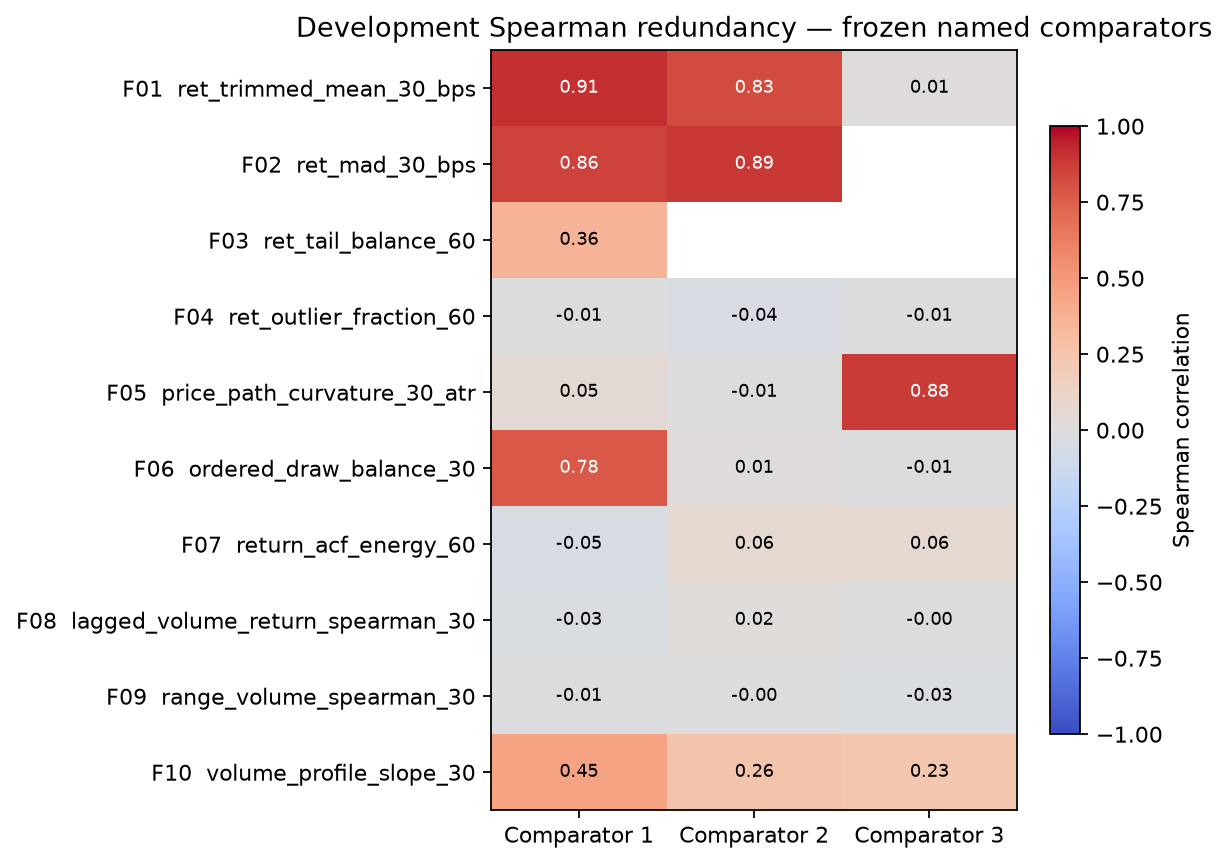

Section 2 artifact manifest: reports/statistical_research/fes_project1/v1/section2_hash_manifest.json
Development integrity failures: 0
Target/outcome tables loaded: False


In [12]:
import hashlib

section2_data_dir = ROOT / DATA_NAMESPACE
section2_report_dir = ROOT / REPORT_NAMESPACE
section2_data_dir.mkdir(parents=True, exist_ok=True)
section2_report_dir.mkdir(parents=True, exist_ok=True)

def write_parquet_exact(path: Path, frame: pd.DataFrame) -> None:
    if path.exists():
        reloaded = pd.read_parquet(path)
        pd.testing.assert_frame_equal(
            reloaded,
            frame,
            check_categorical=False,
            check_like=False,
        )
    else:
        frame.to_parquet(path, index=False, compression="zstd")
    reloaded = pd.read_parquet(path)
    pd.testing.assert_frame_equal(
        reloaded,
        frame,
        check_categorical=False,
        check_like=False,
    )

def write_text_exact(path: Path, content: str) -> None:
    if path.exists():
        if path.read_text(encoding="utf-8") != content:
            raise FileExistsError(f"refusing to overwrite conflicting v1 artifact: {path}")
        return
    path.write_text(content, encoding="utf-8")

def write_bytes_exact(path: Path, content: bytes) -> None:
    if path.exists():
        if path.read_bytes() != content:
            raise FileExistsError(f"refusing to overwrite conflicting v1 artifact: {path}")
        return
    path.write_bytes(content)

data_frames = {
    "scalar_features_development_gc.parquet": development_scalar,
    "scalar_missing_reasons_development_gc.parquet": development_missing,
    "scalar_zero_scale_flags_development_gc.parquet": development_zero_flags,
    "scalar_features_validation_sealed_gc.parquet": validation_scalar_sealed,
    "scalar_missing_reasons_validation_sealed_gc.parquet": validation_missing_sealed,
    "scalar_zero_scale_flags_validation_sealed_gc.parquet": validation_zero_flags_sealed,
    "scalar_feature_registry_gc.parquet": section2_registry,
}
for filename, frame in data_frames.items():
    write_parquet_exact(section2_data_dir / filename, frame)

report_frames = {
    "section2_coverage_missingness_development.csv": section2_coverage,
    "section2_scalar_integrity_development.csv": section2_integrity,
    "section2_distribution_development.csv": section2_distributions,
    "section2_named_comparator_correlations_development.csv": section2_correlations,
    "section2_formula_causality_boundary_tests.csv": section2_test_table,
    "section2_construction_audit.csv": section2_build.construction_audit,
    "section2_missingness_actions.csv": missingness_actions_df,
}
for filename, frame in report_frames.items():
    write_text_exact(
        section2_report_dir / filename,
        frame.to_csv(index=False, lineterminator="\n"),
    )

heatmap_buffer = BytesIO()
fig.savefig(
    heatmap_buffer,
    format="png",
    dpi=160,
    bbox_inches="tight",
    metadata={"Software": "Project 1 FES Section 2"},
)
heatmap_path = section2_report_dir / "section2_named_comparator_heatmap_development.png"
write_bytes_exact(heatmap_path, heatmap_buffer.getvalue())
plt.close(fig)

environment_update = {
    "schema_version": "1.0.0",
    "section": 2,
    "active_branch": GIT_BRANCH,
    "git_commit": GIT_COMMIT,
    "gitnexus_branch": GITNEXUS_META["branch"],
    "gitnexus_commit": GITNEXUS_META["lastCommit"],
    "branch_and_commit_match": bool(
        GITNEXUS_META["branch"] == GIT_BRANCH
        and GITNEXUS_META["lastCommit"] == GIT_COMMIT
    ),
    "installed_dependencies": {
        "scikit-learn": PACKAGE_VERSIONS["scikit-learn"],
        "joblib": PACKAGE_VERSIONS["joblib"],
    },
    "requirements_updated": [
        "requirements.txt",
        "requirements.lock.txt",
    ],
    "section1_snapshot_preserved": True,
    "section1_state_superseded_items": [
        "GitNexus branch label",
        "scikit-learn availability",
        "joblib availability",
    ],
}
environment_path = section2_report_dir / "section2_environment_update.json"
write_text_exact(
    environment_path,
    json.dumps(environment_update, indent=2, sort_keys=True) + "\n",
)

complete_counts = (
    section2_coverage.loc[section2_coverage["cause"].eq("COMPLETE")]
    .groupby("feature_name", observed=True)["rows"]
    .sum()
    .reindex(SECTION2_FEATURE_NAMES)
    .astype(int)
)
zero_counts = section2_integrity.set_index("feature_name")[
    "formula_defined_zero_rows"
].astype(int)
degeneracy_counts = section2_integrity.set_index("feature_name")[
    "degenerate_rows"
].astype(int)
section2_checkpoint = {
    "schema_version": "1.0.0",
    "section_completed": 2,
    "section_3_started": False,
    "branch": GIT_BRANCH,
    "git_commit": GIT_COMMIT,
    "config_sha256": CONFIG_SHA256,
    "implemented": {
        "base_features": list(BASE_FEATURE_NAMES),
        "support_transform": "relative_volume_20_clipped",
        "interactions": list(INTERACTION_FEATURE_NAMES),
    },
    "diagnostic_scope": "Development only",
    "validation_scope": "sealed outcome-free artifacts only",
    "historical_final_materialized": False,
    "target_tables_loaded": False,
    "complete_rows_development": complete_counts.to_dict(),
    "zero_scale_rows_development": zero_counts.to_dict(),
    "degenerate_rows_development": degeneracy_counts.to_dict(),
    "integrity_failure_rows_development": int(
        section2_integrity["integrity_failure_rows"].sum()
    ),
    "focused_tests": focused_test_output,
    "impact_analysis": {
        "symbol": "build_continuity_run_id",
        "risk": "LOW",
        "direct_callers": 3,
        "affected_processes": 1,
        "affected_modules": 2,
        "shared_symbol_modified": False,
    },
}
checkpoint_path = section2_report_dir / "section2_checkpoint.json"
write_text_exact(
    checkpoint_path,
    json.dumps(section2_checkpoint, indent=2, sort_keys=True) + "\n",
)

artifact_paths = [
    *[section2_data_dir / name for name in data_frames],
    *[section2_report_dir / name for name in report_frames],
    heatmap_path,
    environment_path,
    checkpoint_path,
]
artifact_hashes = {
    path.relative_to(ROOT).as_posix(): sha256_file(path)
    for path in artifact_paths
}
hash_manifest = {
    "schema_version": "1.0.0",
    "research_id": "fes_project1",
    "artifact_version": ARTIFACT_VERSION,
    "section": 2,
    "config_sha256": CONFIG_SHA256,
    "artifacts": artifact_hashes,
}
manifest_path = section2_report_dir / "section2_hash_manifest.json"
write_text_exact(
    manifest_path,
    json.dumps(hash_manifest, indent=2, sort_keys=True) + "\n",
)
for relative_path, expected_hash in artifact_hashes.items():
    assert sha256_file(ROOT / relative_path) == expected_hash
assert sha256_file(manifest_path) == hashlib.sha256(
    manifest_path.read_bytes()
).hexdigest()

display(pd.DataFrame(
    [{"artifact": path, "sha256": digest}
     for path, digest in artifact_hashes.items()]
))
display(Image(filename=str(heatmap_path)))
print(f"Section 2 artifact manifest: {manifest_path.relative_to(ROOT).as_posix()}")
print(f"Development integrity failures: {int(section2_integrity['integrity_failure_rows'].sum())}")
print("Target/outcome tables loaded: False")

### 2.5 Checkpoint 2

Section 2 is complete. F01–F10, H01, and I01–I04 are implemented
exactly on the frozen scales with deterministic missing causes,
exact observation joins, range/finite checks, formula-defined-zero
diagnostics, and immutable reload/hash validation.

The compact heatmap is an outcome-free Development redundancy check
against the named tracked comparators. No target association,
screening, modeling, policy selection, or economic evaluation has
occurred. Validation exists only as sealed outcome-free files;
Historical Final has not been materialized.

# Section 3 — Multichannel profile representations

Section 3 constructs one complete, ordered 30-position profile for each eligible
decision bar. The saved P0 block is strictly
`[R_0..R_29, G_0..G_29, Q_0..Q_29]`, where R is the one-bar log return in basis
points, G is true range divided by ATR20, and Q is the trailing-60 log-volume
z-score. The oldest return explicitly requires the same-continuity predecessor
at `t-30`.

No padding, carry-forward, shortening, or boundary crossing is permitted.
Diagnostics below use Development only. Validation is materialized only as
sealed, outcome-free index and raw-profile artifacts; Historical Final and all
target/outcome tables remain unread.

### 3.1 Exact raw P0 construction and completeness

Profile construction reuses the production continuity identity and adds the
locked New York trade-date reset. The exact raw source spans are checked before
derived denominators: 50 closes for R/G predecessors, 49 high/low bars for G,
and 89 volume bars for the earliest Q value.

In [13]:
import gc

from src.statistical_research.fes_project1_profiles import (  # noqa: E402
    P0_COLUMNS, P1_COLUMNS, P2_COLUMNS, P3_COLUMNS,
    PROFILE_CHANNELS, PROFILE_REPRESENTATIONS, REPRESENTATION_COLUMNS,
    FoldLocalPCAProfileTransformer, FoldLocalPLSProfileTransformer,
    FoldLocalProfileTransformer, build_p1_zero_scale_audit,
    build_profile_autocorrelation_diagnostics, build_profile_coverage_audit,
    build_profile_matrix, build_profile_rank_condition_diagnostics,
    transform_profile_representation,
)

# Section 2 artifacts have already been written. Release its large intermediates
# while retaining the trusted bars and eligible-observation identities.
for transient_name in (
    "section2_build", "development_scalar", "validation_scalar_sealed",
    "development_missing", "validation_missing_sealed",
    "development_zero_flags", "validation_zero_flags_sealed",
    "development_existing", "section2_distributions",
):
    globals().pop(transient_name, None)
gc.collect()

section3_build = build_profile_matrix(
    section2_bars,
    section2_eligible,
    allowed_partitions=("Development", "Validation"),
    chunk_size=20_000,
)
section3_index = section3_build.profile_index
section3_raw = section3_build.raw_profiles

development_profile_index = section3_index.loc[
    section3_index["research_partition"].astype(str).eq("Development")
].reset_index(drop=True)
validation_profile_index_sealed = section3_index.loc[
    section3_index["research_partition"].astype(str).eq("Validation")
].reset_index(drop=True)
development_complete_ids = set(
    development_profile_index.loc[
        development_profile_index["profile_complete_30"], "observation_id"
    ]
)
validation_complete_ids = set(
    validation_profile_index_sealed.loc[
        validation_profile_index_sealed["profile_complete_30"], "observation_id"
    ]
)
development_raw_profile = section3_raw.loc[
    section3_raw["observation_id"].isin(development_complete_ids)
].reset_index(drop=True)
validation_raw_profile_sealed = section3_raw.loc[
    section3_raw["observation_id"].isin(validation_complete_ids)
].reset_index(drop=True)

assert len(development_profile_index) == 306_230
assert len(validation_profile_index_sealed) == 118_076
assert len(development_raw_profile) == int(
    development_profile_index["profile_complete_30"].sum()
)
assert len(validation_raw_profile_sealed) == int(
    validation_profile_index_sealed["profile_complete_30"].sum()
)
assert tuple(development_raw_profile.columns[1:]) == P0_COLUMNS
assert tuple(validation_raw_profile_sealed.columns[1:]) == P0_COLUMNS
assert all(development_raw_profile[name].dtype == np.dtype("float32") for name in P0_COLUMNS)
assert all(validation_raw_profile_sealed[name].dtype == np.dtype("float32") for name in P0_COLUMNS)
assert section3_build.channel_lag_schema["column_name"].tolist() == list(P0_COLUMNS)
assert section3_build.channel_lag_schema["stored_index"].tolist() == list(range(90))
assert not set(development_complete_ids).intersection(validation_complete_ids)
assert "Final test" not in set(section3_index["research_partition"].astype(str))

display(section3_build.channel_lag_schema)
display(section3_build.construction_audit)
print(f"Development complete P0 rows: {len(development_raw_profile):,}")
print("Validation: sealed outcome-free P0/index artifacts only")
print("Historical Final materialized: False")
print("Target/outcome tables loaded: False")

,stored_index,column_name,channel_code,channel_name,position,bar_offset_from_t,formula,units,required_input,availability,reset_boundary,calculation_dtype,saved_dtype,version
0,0,R_00,R,return_bps,0,-29,10000*log(C_i/C_(i-1)),basis_points,close and predecessor close,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,1.0.0
1,1,R_01,R,return_bps,1,-28,10000*log(C_i/C_(i-1)),basis_points,close and predecessor close,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,1.0.0
2,2,R_02,R,return_bps,2,-27,10000*log(C_i/C_(i-1)),basis_points,close and predecessor close,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,1.0.0
3,3,R_03,R,return_bps,3,-26,10000*log(C_i/C_(i-1)),basis_points,close and predecessor close,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,1.0.0
4,4,R_04,R,return_bps,4,-25,10000*log(C_i/C_(i-1)),basis_points,close and predecessor close,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,1.0.0
5,5,R_05,R,return_bps,5,-24,10000*log(C_i/C_(i-1)),basis_points,close and predecessor close,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,1.0.0
6,6,R_06,R,return_bps,6,-23,10000*log(C_i/C_(i-1)),basis_points,close and predecessor close,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,1.0.0
7,7,R_07,R,return_bps,7,-22,10000*log(C_i/C_(i-1)),basis_points,close and predecessor close,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,1.0.0
8,8,R_08,R,return_bps,8,-21,10000*log(C_i/C_(i-1)),basis_points,close and predecessor close,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,1.0.0
9,9,R_09,R,return_bps,9,-20,10000*log(C_i/C_(i-1)),basis_points,close and predecessor close,close of completed decision bar t,production continuity_run_id + trade_date_ny outer reset,float64,float32,1.0.0


,item,value
0,source_rows,1271455
1,selected_observations,424306
2,selected_partitions,Development|Validation
3,historical_final_materialized,False
4,outcome_columns_accepted,False
5,source_sorted_during_build,False
6,decision_bar_ids_exact,True
7,decision_timestamps_exact,True
8,profile_positions,30
9,profile_channels,R|G|Q


Development complete P0 rows: 305,667
Validation: sealed outcome-free P0/index artifacts only
Historical Final materialized: False
Target/outcome tables loaded: False


### 3.2 P0–P3 transforms and Development-only diagnostics

P1 trims three sorted values from each tail independently within every
row/channel, then uses the remaining 24 values for a population mean and
standard deviation while preserving the original temporal order. A zero scale
maps that complete channel to zeros and is audited. P2 is the within-channel
first difference of P1. P3 is the causal trailing median of exactly three P1
positions—no centered or longer smoother is used.

The rank, condition, and PCA variance summaries are outcome-free descriptive
diagnostics on Development. They are not persisted transforms and are not used
to evaluate or select a model.

In [14]:
section3_coverage = build_profile_coverage_audit(development_profile_index)
section3_zero_scale = build_p1_zero_scale_audit(development_raw_profile)
section3_autocorrelation = build_profile_autocorrelation_diagnostics(
    development_raw_profile, maximum_lag=10, chunk_size=10_000
)
section3_rank_condition = build_profile_rank_condition_diagnostics(
    development_raw_profile, chunk_size=20_000
)

representation_schema = pd.DataFrame.from_records([
    {
        "representation": "P0",
        "columns": len(P0_COLUMNS),
        "row_transform": "raw ordered R|G|Q channels",
        "column_transform": "training-fold-only StandardScaler",
        "persisted": True,
    },
    {
        "representation": "P1",
        "columns": len(P1_COLUMNS),
        "row_transform": "per-row/channel trim 3 each tail; mean/std(ddof=0) on 24; original order",
        "column_transform": "training-fold-only StandardScaler",
        "persisted": False,
    },
    {
        "representation": "P2",
        "columns": len(P2_COLUMNS),
        "row_transform": "P1 within-channel first difference",
        "column_transform": "training-fold-only StandardScaler",
        "persisted": False,
    },
    {
        "representation": "P3",
        "columns": len(P3_COLUMNS),
        "row_transform": "P1 causal trailing median of positions j-2,j-1,j",
        "column_transform": "training-fold-only StandardScaler",
        "persisted": False,
    },
])
assert representation_schema.set_index("representation")["columns"].to_dict() == {
    "P0": 90, "P1": 90, "P2": 87, "P3": 84
}
assert not representation_schema.loc[
    representation_schema["representation"].ne("P0"), "persisted"
].any()
assert int(section3_zero_scale["zero_scale_rows"].sum()) == 0
assert section3_rank_condition["numerical_rank"].tolist() == [90, 90, 87, 84]
assert np.isfinite(section3_rank_condition["condition_number_standardized"]).all()

complete_coverage = section3_coverage.loc[
    section3_coverage["cause"].eq("COMPLETE")
].reset_index(drop=True)
assert complete_coverage["complete_ny_dates"].astype(int).ge(400).all()
assert complete_coverage["rows"].ge(10_000).all()
autocorrelation_summary = (
    section3_autocorrelation
    .groupby(["representation", "channel_code"], observed=True, as_index=False)
    ["mean_absolute_autocorrelation"].mean()
)

illustrative_positions = np.linspace(
    0, len(development_raw_profile) - 1, num=3, dtype=int
)
illustrative_raw = development_raw_profile.iloc[illustrative_positions].reset_index(drop=True)
illustrative_p1, illustrative_zero = transform_profile_representation(
    illustrative_raw, "P1"
)
assert not illustrative_zero.any()
illustrative_selection = (
    illustrative_raw[["observation_id"]]
    .merge(
        development_profile_index[[
            "observation_id", "decision_timestamp_utc", "trade_date_ny", "entry_session"
        ]],
        on="observation_id",
        how="left",
        validate="one_to_one",
    )
)

illustrative_figure, illustrative_axes = plt.subplots(
    nrows=3, ncols=1, figsize=(9.5, 8.5), sharex=True
)
for row_index, axis in enumerate(illustrative_axes):
    channels = illustrative_p1[row_index].reshape(3, 30)
    for channel_index, channel_code in enumerate(PROFILE_CHANNELS):
        axis.plot(
            np.arange(30), channels[channel_index],
            linewidth=1.4, label=channel_code,
        )
    observation_id = illustrative_selection.iloc[row_index]["observation_id"]
    timestamp = illustrative_selection.iloc[row_index]["decision_timestamp_utc"]
    axis.axhline(0.0, color="black", linewidth=0.6, alpha=0.5)
    axis.set_ylabel("P1 value")
    axis.set_title(f"{observation_id} — {timestamp}")
    axis.grid(alpha=0.2)
illustrative_axes[0].legend(ncol=3, loc="upper right")
illustrative_axes[-1].set_xlabel("ordered profile position (0 = t-29, 29 = t)")
illustrative_figure.suptitle(
    "Three deterministic Development profiles — robust within-channel P1",
    y=1.0,
)
illustrative_figure.tight_layout()

display(representation_schema)
display(complete_coverage)
display(section3_zero_scale)
display(autocorrelation_summary.pivot(
    index="representation", columns="channel_code",
    values="mean_absolute_autocorrelation"
))
display(section3_rank_condition)

,representation,columns,row_transform,column_transform,persisted
0,P0,90,raw ordered R|G|Q channels,training-fold-only StandardScaler,True
1,P1,90,per-row/channel trim 3 each tail; mean/std(ddof=0) on 24; original order,training-fold-only StandardScaler,False
2,P2,87,P1 within-channel first difference,training-fold-only StandardScaler,False
3,P3,84,"P1 causal trailing median of positions j-2,j-1,j",training-fold-only StandardScaler,False


,entry_session,cause,rows,rate,complete_ny_dates
0,London,COMPLETE,114525,0.997309,638
1,New York,COMPLETE,191142,0.998673,638


,channel_code,complete_profiles,zero_scale_rows,zero_scale_rate
0,R,305667,0,0.0
1,G,305667,0,0.0
2,Q,305667,0,0.0


channel_code,G,Q,R
representation,,,
P0,0.167951,0.212989,0.163395
P1,0.167951,0.212989,0.163395
P2,0.210871,0.200624,0.223171
P3,0.275534,0.326134,0.247898


,representation,rows,columns,zero_variance_columns,numerical_rank,effective_rank_entropy,stable_rank,condition_number_standardized,pca_components_80_percent,pca_components_90_percent,pca_components_95_percent,pca_cumulative_variance_3,pca_cumulative_variance_5,pca_cumulative_variance_8,pca_cumulative_variance_12,diagnostic_fit_scope
0,P0,305667,90,0,90,65.024403,10.719147,6.155540,51,61,72,0.186252,0.238618,0.297855,0.362140,full Development; outcome-free diagnostic only; not persisted or used for model fitting
1,P1,305667,90,0,90,70.955324,17.750241,8.822740,51,62,74,0.133070,0.187085,0.250837,0.323788,full Development; outcome-free diagnostic only; not persisted or used for model fitting
2,P2,305667,87,0,87,60.595172,30.342070,23.974636,40,52,61,0.096312,0.156892,0.241784,0.341493,full Development; outcome-free diagnostic only; not persisted or used for model fitting
3,P3,305667,84,0,84,44.208250,9.819009,9.029319,29,45,60,0.237773,0.325375,0.419696,0.531368,full Development; outcome-free diagnostic only; not persisted or used for model fitting


### 3.3 Fold-local transformer interfaces and deterministic tests

Every representation performs column standardization only inside
`fit(training_fold)`. PCA wraps that fold-local standardization and fixes
component signs deterministically. PLS is locked to P2 and refuses to fit
without training-fold targets. Section 3 does not load a target, fit a trusted
PLS model, or report target association/model performance.

In [15]:
transformer_interface_audit = pd.DataFrame.from_records([
    {
        "interface": "FoldLocalProfileTransformer",
        "allowed_representation": "P0|P1|P2|P3",
        "fit_scope": "training fold only",
        "target_required": False,
        "full_development_fit_persisted": False,
        "section3_trusted_fit": False,
        "status": "PASS",
    },
    {
        "interface": "FoldLocalPCAProfileTransformer",
        "allowed_representation": "P0|P1|P2|P3",
        "fit_scope": "training fold only after fold-local column standardization",
        "target_required": False,
        "full_development_fit_persisted": False,
        "section3_trusted_fit": False,
        "status": "PASS",
    },
    {
        "interface": "FoldLocalPLSProfileTransformer",
        "allowed_representation": "P2 only",
        "fit_scope": "training fold only after fold-local column standardization",
        "target_required": True,
        "full_development_fit_persisted": False,
        "section3_trusted_fit": False,
        "status": "PASS",
    },
])

# Instantiate the public interfaces without fitting trusted Development data.
assert FoldLocalProfileTransformer("P0").representation == "P0"
assert FoldLocalPCAProfileTransformer("P1", n_components=3).n_components == 3
assert FoldLocalPLSProfileTransformer(n_components=2).n_components == 2

section3_focused_test_raw = run_text([
    sys.executable, "-m", "pytest", "-q", "--color=no",
    "tests/test_fes_project1_profiles.py",
])
assert "24 passed" in section3_focused_test_raw
section3_focused_test_output = "24 passed"
section3_test_table = pd.DataFrame.from_records([
    {
        "test_group": "raw P0 formulas/schema",
        "coverage": "manual R/G/Q values, exact 90-column order, t-30 predecessor",
        "status": "PASS",
    },
    {
        "test_group": "P1-P3 transforms",
        "coverage": "manual trimmed standardization, zero scale, difference, trailing median, 90/90/87/84 dimensions",
        "status": "PASS",
    },
    {
        "test_group": "causality",
        "coverage": "future mutation and post-decision source truncation invariance",
        "status": "PASS",
    },
    {
        "test_group": "boundaries",
        "coverage": "gap/date/product/contract/instrument/segment/roll reset and 15:30 crossing rejection",
        "status": "PASS",
    },
    {
        "test_group": "missingness/storage",
        "coverage": "precedence, source null, nonpositive ATR, constant-volume z-score, complete-only raw storage",
        "status": "PASS",
    },
    {
        "test_group": "fold-local interfaces",
        "coverage": "scaler isolation, PCA determinism, PLS target requirement/P2 lock/determinism",
        "status": "PASS",
    },
    {
        "test_group": "focused pytest",
        "coverage": section3_focused_test_output,
        "status": "PASS",
    },
])
assert transformer_interface_audit["status"].eq("PASS").all()
assert section3_test_table["status"].eq("PASS").all()
display(transformer_interface_audit)
display(section3_test_table)
print("Trusted target fits performed in Section 3: 0")
print("Model-performance results reported in Section 3: 0")

,interface,allowed_representation,fit_scope,target_required,full_development_fit_persisted,section3_trusted_fit,status
0,FoldLocalProfileTransformer,P0|P1|P2|P3,training fold only,False,False,False,PASS
1,FoldLocalPCAProfileTransformer,P0|P1|P2|P3,training fold only after fold-local column standardization,False,False,False,PASS
2,FoldLocalPLSProfileTransformer,P2 only,training fold only after fold-local column standardization,True,False,False,PASS


,test_group,coverage,status
0,raw P0 formulas/schema,"manual R/G/Q values, exact 90-column order, t-30 predecessor",PASS
1,P1-P3 transforms,"manual trimmed standardization, zero scale, difference, trailing median, 90/90/87/84 d...",PASS
2,causality,future mutation and post-decision source truncation invariance,PASS
3,boundaries,gap/date/product/contract/instrument/segment/roll reset and 15:30 crossing rejection,PASS
4,missingness/storage,"precedence, source null, nonpositive ATR, constant-volume z-score, complete-only raw s...",PASS
5,fold-local interfaces,"scaler isolation, PCA determinism, PLS target requirement/P2 lock/determinism",PASS
6,focused pytest,24 passed,PASS


Trusted target fits performed in Section 3: 0
Model-performance results reported in Section 3: 0


### 3.4 Immutable raw storage, reload equality, memory, and hashes

Only the raw float32 P0 block and its observation index are stored for each
permitted partition. P1–P3 and learned PCA/PLS objects are deliberately absent
from the artifact namespace. Each artifact is reloaded and compared or hashed
before Checkpoint 3 is issued.

,artifact,rows,columns,memory_bytes,disk_bytes_zstd_parquet,memory_mib,disk_mib
0,profile_index_development_gc.parquet,306230,7,8575377,2915864,8.178117,2.780785
1,raw_profile_p0_development_gc.parquet,305667,91,112485588,92372467,107.274616,88.093249
2,profile_index_validation_sealed_gc.parquet,118076,7,3307065,1390686,3.153863,1.326262
3,raw_profile_p0_validation_sealed_gc.parquet,117712,91,43318148,40695916,41.311405,38.810650
4,profile_channel_lag_schema_gc.parquet,90,14,26112,9962,0.024902,0.009501


,artifact,sha256
0,data/processed/statistical_research/fes_project1/v1/profile_index_development_gc.parquet,7e7fdc2f3ecc3cda11bcb5904772e1f90879d174322fb284b06a6b63865e5fd0
1,data/processed/statistical_research/fes_project1/v1/raw_profile_p0_development_gc.parquet,57a4c90ad465936a19c87c1bdcac588e2098f64a1a13e473f120450a823c1790
2,data/processed/statistical_research/fes_project1/v1/profile_index_validation_sealed_gc...,7ee83393139c83d62a8db18cac9149378cc4549a81086e4e2c3a360025ed50e7
3,data/processed/statistical_research/fes_project1/v1/raw_profile_p0_validation_sealed_g...,3ae87365d87cfd84e855a5d1e8130d9facbedf9b93f9f0061435fbcc49d2283d
4,data/processed/statistical_research/fes_project1/v1/profile_channel_lag_schema_gc.parquet,f3f54e08ab6a450ad79b35f8ad437abaf37da62b88bf5c1c334c2c4a4ea48b10
5,reports/statistical_research/fes_project1/v1/section3_representation_schema.csv,ff2201b22fbdd79d9e1bdac76420b7a8e199d85a9790c67ce67b6901990f523b
6,reports/statistical_research/fes_project1/v1/section3_profile_coverage_development.csv,8f824c7aafceb0f7177439f1b986ac294fc2c6982a2e27a29651341cf24bad2e
7,reports/statistical_research/fes_project1/v1/section3_p1_zero_scale_development.csv,062247a65ba1eeead69194eedd0067db78288411e3572b6db7f681da44dfd99f
8,reports/statistical_research/fes_project1/v1/section3_autocorrelation_development.csv,79f0a9b7174271dfb55273c964b51c12cb3599b8521d5dec3b61ef78ee6f4067
9,reports/statistical_research/fes_project1/v1/section3_rank_condition_development.csv,8fa6a5269573051952b89ad95d6c506699274a555ef78d69b2b0a367bc50ad51


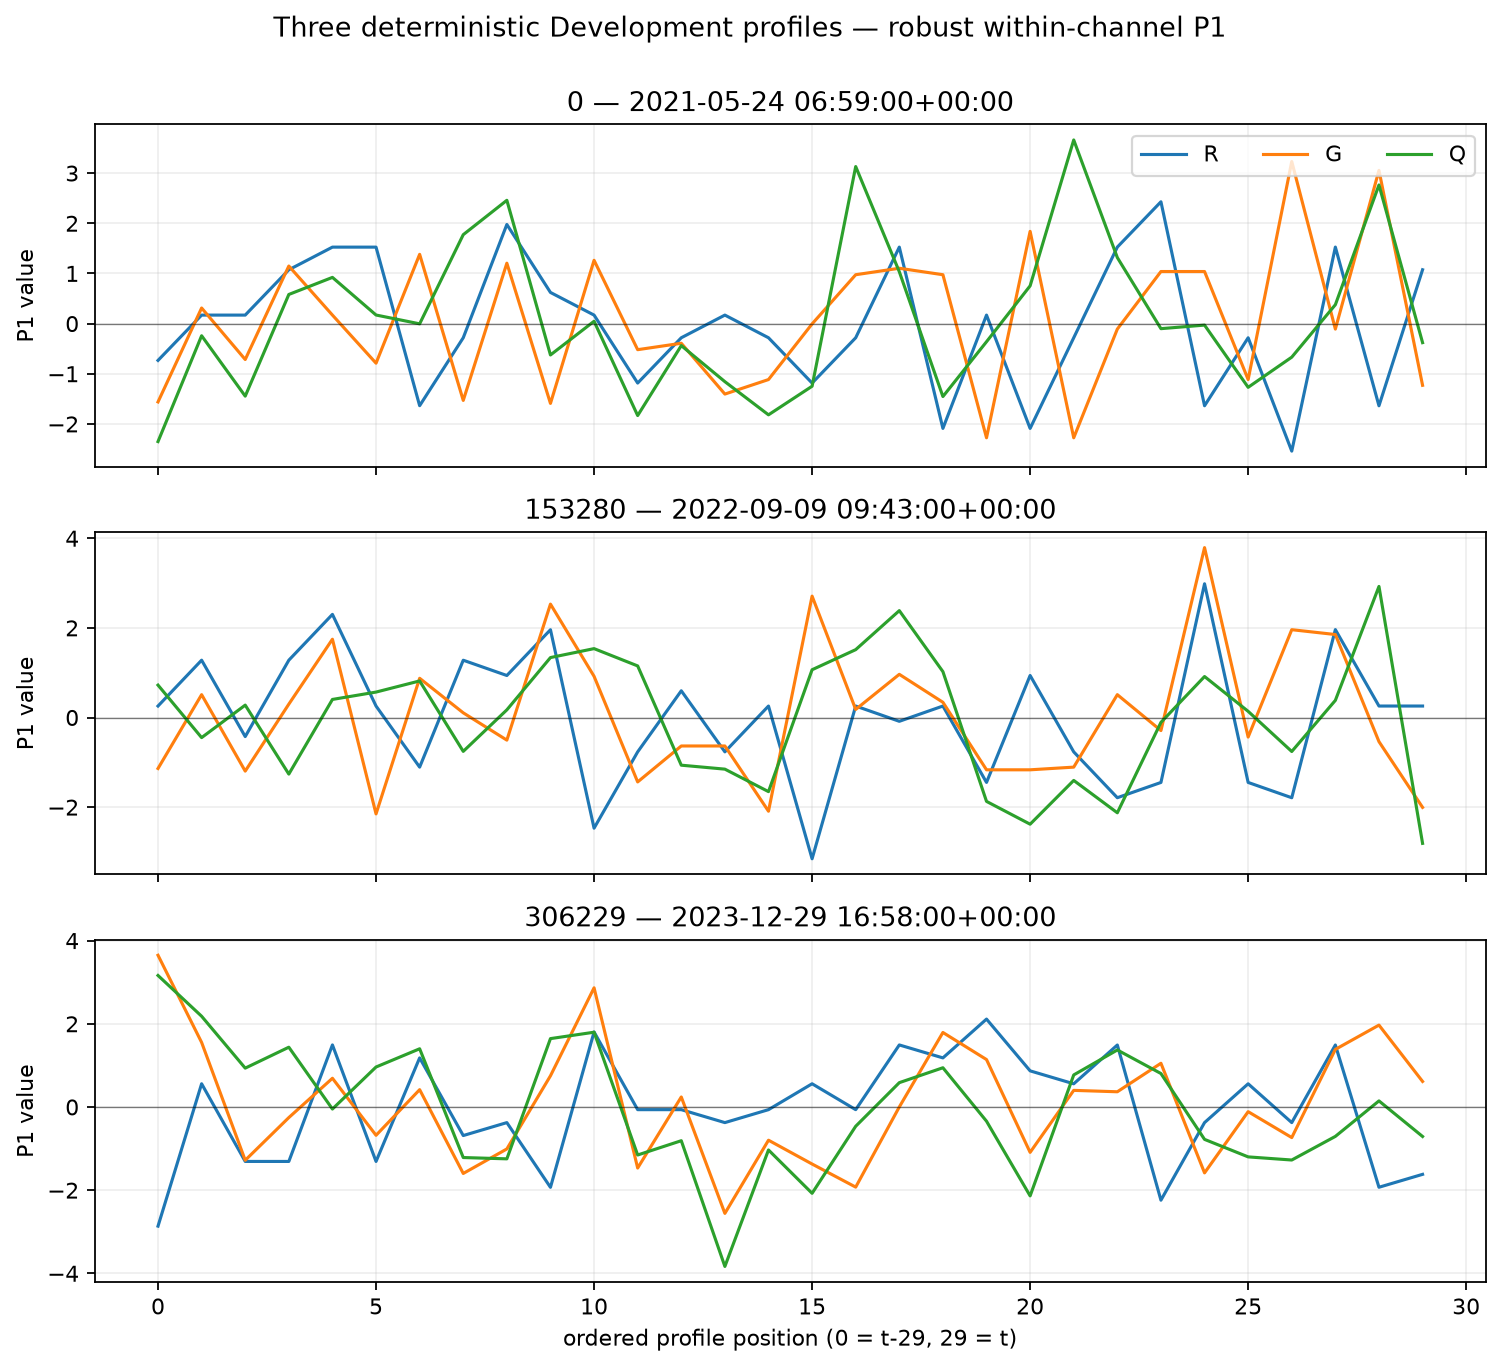

Section 3 artifact manifest: reports/statistical_research/fes_project1/v1/section3_hash_manifest.json
Saved learned full-data PCA/PLS objects: 0
Section 3 reload equality and hash verification: PASS


In [16]:
section3_data_dir = ROOT / DATA_NAMESPACE
section3_report_dir = ROOT / REPORT_NAMESPACE
section3_data_dir.mkdir(parents=True, exist_ok=True)
section3_report_dir.mkdir(parents=True, exist_ok=True)

section3_data_frames = {
    "profile_index_development_gc.parquet": development_profile_index,
    "raw_profile_p0_development_gc.parquet": development_raw_profile,
    "profile_index_validation_sealed_gc.parquet": validation_profile_index_sealed,
    "raw_profile_p0_validation_sealed_gc.parquet": validation_raw_profile_sealed,
    "profile_channel_lag_schema_gc.parquet": section3_build.channel_lag_schema,
}
for filename, frame in section3_data_frames.items():
    write_parquet_exact(section3_data_dir / filename, frame)

memory_footprint = pd.DataFrame.from_records([
    {
        "artifact": filename,
        "rows": len(frame),
        "columns": len(frame.columns),
        "memory_bytes": int(frame.memory_usage(index=True, deep=True).sum()),
        "disk_bytes_zstd_parquet": int((section3_data_dir / filename).stat().st_size),
    }
    for filename, frame in section3_data_frames.items()
])
memory_footprint["memory_mib"] = memory_footprint["memory_bytes"] / (1024 ** 2)
memory_footprint["disk_mib"] = memory_footprint["disk_bytes_zstd_parquet"] / (1024 ** 2)

section3_report_frames = {
    "section3_representation_schema.csv": representation_schema,
    "section3_profile_coverage_development.csv": section3_coverage,
    "section3_p1_zero_scale_development.csv": section3_zero_scale,
    "section3_autocorrelation_development.csv": section3_autocorrelation,
    "section3_rank_condition_development.csv": section3_rank_condition,
    "section3_memory_footprint.csv": memory_footprint,
    "section3_transformer_interface_audit.csv": transformer_interface_audit,
    "section3_formula_causality_boundary_tests.csv": section3_test_table,
    "section3_construction_audit.csv": section3_build.construction_audit,
    "section3_illustrative_profile_selection.csv": illustrative_selection,
}
for filename, frame in section3_report_frames.items():
    write_text_exact(
        section3_report_dir / filename,
        frame.to_csv(index=False, lineterminator="\n"),
    )

illustrative_buffer = BytesIO()
illustrative_figure.savefig(
    illustrative_buffer,
    format="png",
    dpi=160,
    bbox_inches="tight",
    metadata={"Software": "Project 1 FES Section 3"},
)
illustrative_path = (
    section3_report_dir / "section3_illustrative_profiles_development.png"
)
write_bytes_exact(illustrative_path, illustrative_buffer.getvalue())
plt.close(illustrative_figure)

persisted_section3_data_names = [
    path.name for path in section3_data_dir.glob("*")
]
for forbidden_token in (
    "raw_profile_p1_", "raw_profile_p2_", "raw_profile_p3_",
    "pca_model", "pls_model",
):
    assert not any(
        forbidden_token in name.lower()
        for name in persisted_section3_data_names
    )
assert sum(
    "raw_profile_p0_" in name for name in persisted_section3_data_names
) == 2

coverage_checkpoint = {
    row["entry_session"]: {
        "complete_rows": int(row["rows"]),
        "complete_rate": float(row["rate"]),
        "complete_ny_dates": int(row["complete_ny_dates"]),
    }
    for row in complete_coverage.to_dict("records")
}
rank_checkpoint = {
    row["representation"]: {
        "columns": int(row["columns"]),
        "numerical_rank": int(row["numerical_rank"]),
        "effective_rank_entropy": float(row["effective_rank_entropy"]),
        "condition_number_standardized": float(row["condition_number_standardized"]),
        "pca_components_80_percent": int(row["pca_components_80_percent"]),
        "pca_components_90_percent": int(row["pca_components_90_percent"]),
        "pca_components_95_percent": int(row["pca_components_95_percent"]),
    }
    for row in section3_rank_condition.to_dict("records")
}
section3_checkpoint = {
    "schema_version": "1.0.0",
    "section_completed": 3,
    "section_4_started": False,
    "branch": GIT_BRANCH,
    "git_commit": GIT_COMMIT,
    "config_sha256": CONFIG_SHA256,
    "raw_profile_contract": {
        "stored_order": "R_0..R_29|G_0..G_29|Q_0..Q_29",
        "stored_dtype": "float32",
        "complete_rows_only": True,
        "predecessor_t_minus_30_required": True,
        "dimensions": {"P0": 90, "P1": 90, "P2": 87, "P3": 84},
    },
    "diagnostic_scope": "Development only; outcome-free",
    "validation_scope": "sealed outcome-free P0/index artifacts only",
    "historical_final_materialized": False,
    "target_tables_loaded": False,
    "model_performance_reported": False,
    "coverage_development": coverage_checkpoint,
    "p1_zero_scale_rows": {
        row["channel_code"]: int(row["zero_scale_rows"])
        for row in section3_zero_scale.to_dict("records")
    },
    "rank_condition_development": rank_checkpoint,
    "fold_local_interfaces": {
        "column_standardization": True,
        "pca": True,
        "pls_p2_only_and_target_required": True,
        "trusted_pls_fit_in_section3": False,
        "full_data_learned_transform_persisted": False,
    },
    "storage": {
        "development_raw_rows": len(development_raw_profile),
        "development_raw_memory_bytes": int(
            development_raw_profile.memory_usage(index=True, deep=True).sum()
        ),
        "validation_raw_rows_sealed": len(validation_raw_profile_sealed),
        "reload_equality": True,
        "hash_verification": True,
    },
    "focused_tests": section3_focused_test_output,
    "impact_analysis": {
        "symbol": "build_continuity_run_id",
        "risk": "LOW",
        "direct_callers": 3,
        "affected_processes": 1,
        "affected_modules": 2,
        "shared_symbol_modified": False,
    },
    "sample_floor": {
        "minimum_complete_rows_per_session": 10_000,
        "minimum_complete_dates_per_session": 400,
        "passed": True,
    },
}
section3_checkpoint_path = section3_report_dir / "section3_checkpoint.json"
write_text_exact(
    section3_checkpoint_path,
    json.dumps(section3_checkpoint, indent=2, sort_keys=True) + "\n",
)

section3_artifact_paths = [
    *[section3_data_dir / name for name in section3_data_frames],
    *[section3_report_dir / name for name in section3_report_frames],
    illustrative_path,
    section3_checkpoint_path,
]
section3_artifact_hashes = {
    path.relative_to(ROOT).as_posix(): sha256_file(path)
    for path in section3_artifact_paths
}
section3_hash_manifest = {
    "schema_version": "1.0.0",
    "research_id": "fes_project1",
    "artifact_version": ARTIFACT_VERSION,
    "section": 3,
    "config_sha256": CONFIG_SHA256,
    "artifacts": section3_artifact_hashes,
}
section3_manifest_path = section3_report_dir / "section3_hash_manifest.json"
write_text_exact(
    section3_manifest_path,
    json.dumps(section3_hash_manifest, indent=2, sort_keys=True) + "\n",
)
for relative_path, expected_hash in section3_artifact_hashes.items():
    assert sha256_file(ROOT / relative_path) == expected_hash

display(memory_footprint)
display(pd.DataFrame([
    {"artifact": relative_path, "sha256": digest}
    for relative_path, digest in section3_artifact_hashes.items()
]))
display(Image(filename=str(illustrative_path)))
print(f"Section 3 artifact manifest: {section3_manifest_path.relative_to(ROOT).as_posix()}")
print("Saved learned full-data PCA/PLS objects: 0")
print("Section 3 reload equality and hash verification: PASS")

### 3.5 Checkpoint 3

Section 3 is complete. The exact 90-column float32 P0 profile is stored for
complete observations with a categorical missing reason retained for every
eligible observation. P1, P2, and P3 have verified dimensions of 90, 87, and
84; their formulas, causality, boundary behavior, zero-scale handling, and
fold-local fitting rules pass the focused deterministic suite.

Development clears both predeclared sample floors in each entry session.
Outcome-free autocorrelation, effective-rank, condition, and PCA variance
diagnostics are saved alongside three deterministic illustrative profiles.
Validation remains sealed and outcome-free; Historical Final, targets, target
associations, model performance, and economic results remain untouched.

# Section 4 — Development-only feature evidence

Section 4 opens only Development outcomes. Retrospective Validation labels,
Validation scores/economics, and Historical Final remain physically
inaccessible. The frozen evidence families contain exactly 20 confirmatory
base-feature tests, 40 separately corrected exploratory tests, and eight
hierarchical incremental interaction tests.

All multiplicity families, targets, sessions, gates, comparator sets,
quintiles, folds, and ridge settings were declared before this outcome read.
`DEV_SUPPORT` and `DEV_INCREMENTAL_SUPPORT` are Development evidence labels—not
final feature advancement and not permission to alter the predeclared M2–M4
model matrices.

### 4.1 Locked Development access and complete evidence build

The trusted existing-feature and forward-label parquet reads carry a physical
`research_partition == Development` filter and project only the needed columns.
The Section 2 scalar artifact is already Development-only. The loader has no
partition argument, and every joined frame is audited before target access.

In [17]:
from src.statistical_research.fes_project1_modeling import (  # noqa: E402
    CONFIRMATORY_FAMILY, EXPLORATORY_FAMILY, INTERACTION_FAMILY,
    Section4EvidenceConfig, build_section4_evidence,
    load_development_evidence_inputs,
)

# Prior sections are immutable and already persisted. Remove their large
# intermediates so Section 4 contains only explicitly reloaded Development rows.
for transient_name in list(globals()):
    if (
        transient_name.startswith("section2_")
        or transient_name.startswith("section3_")
        or transient_name.startswith("validation_")
        or transient_name in {"bars", "eligible", "registry"}
    ):
        globals().pop(transient_name, None)
gc.collect()

SECTION4_CONFIG = Section4EvidenceConfig()
section4_inputs = load_development_evidence_inputs(ROOT)
section4_result = build_section4_evidence(
    section4_inputs,
    SECTION4_CONFIG,
)

assert len(section4_result.confirmatory_results) == 20
assert len(section4_result.exploratory_results) == 40
assert len(section4_result.interaction_results) == 8
assert len(section4_result.complete_trial_ledger) == 150
assert section4_result.complete_trial_ledger.loc[
    section4_result.complete_trial_ledger["notebook_section"].eq(4), "status"
].str.startswith("COMPLETED").all()
assert section4_result.complete_trial_ledger.loc[
    ~section4_result.complete_trial_ledger["notebook_section"].eq(4), "status"
].eq("PLANNED").all()
assert section4_result.access_audit.loc[
    section4_result.access_audit["source"].str.contains(
        "Validation|Historical Final", case=False, regex=True
    ),
    "rows_loaded",
].eq(0).all()
assert section4_result.confirmatory_results["raw_p_value"].notna().all()
assert section4_result.exploratory_results["raw_p_value"].notna().all()
assert section4_result.interaction_results["raw_p_value"].notna().all()

display(section4_result.access_audit)
print("Section 4 Development rows:", len(section4_inputs.forward_labels))
print("Retrospective Validation outcome rows loaded: 0")
print("Historical Final outcome rows loaded: 0")
print("Declared evidence families: 20 confirmatory / 40 exploratory / 8 interaction")

,source,read_scope,rows_loaded,partitions_loaded,outcomes_loaded
0,data/processed/statistical_research/fes_project1/v1/scalar_features_development_gc.par...,presealed Development feature artifact,306230,Development,False
1,data/processed/statistical_research/feature_matrix_gc.parquet,physical parquet filter: Development,306230,Development,False
2,data/processed/statistical_research/forward_labels_gc.parquet,physical parquet filter: Development; projected labels,306230,Development,True
3,retrospective Validation labels,inaccessible until locked Section 6 batch,0,,False
4,Historical Final labels,inaccessible,0,,False


Section 4 Development rows: 306230
Retrospective Validation outcome rows loaded: 0
Historical Final outcome rows loaded: 0
Declared evidence families: 20 confirmatory / 40 exploratory / 8 interaction


### 4.2 Confirmatory, exploratory, quintile, and overlap evidence

Daily Spearman IC uses the New York date as the dependence block and requires at
least ten complete observations per date. Raw p-values are two-sided one-sample
t-tests of the daily IC series. Benjamini–Hochberg correction is global across
the declared 20-test confirmatory family; the 40 exploratory tests receive a
separate global correction and cannot advance a feature.

Quintiles use linear interpolation and are fitted independently by
feature/session on Development. Joint partial rank IC residualizes candidate and
target average ranks against the exact tracked comparator set on each
date/session, requiring a full-rank comparator design.

In [18]:
base_feature_evidence = section4_result.base_feature_evidence.copy()
exploratory_evidence = section4_result.exploratory_results.copy()
partial_ic_evidence = section4_result.partial_ic_results.copy()
quintile_edges = section4_result.quintile_edges.copy()
quintile_hashes = (
    quintile_edges[[
        "feature_name", "session", "quantile_method", "edge_set_sha256"
    ]]
    .drop_duplicates()
    .sort_values(["session", "feature_name"])
    .reset_index(drop=True)
)

base_display_columns = [
    "feature_name", "session", "target", "observation_count",
    "trading_date_count", "daily_ic_mean", "daily_ic_ci_low",
    "daily_ic_ci_high", "raw_p_value", "bh_q_value",
    "bucket_monotonicity", "top_bottom_spread_ticks",
    "partial_ic_mean", "absolute_partial_ic_retention",
    "development_label", "failed_gates",
]
display(base_feature_evidence[base_display_columns])
display(quintile_hashes)
display(
    exploratory_evidence.groupby(
        ["session", "target"], observed=True, as_index=False
    ).agg(
        tests=("trial_id", "size"),
        raw_p_le_0_05=("raw_p_value", lambda values: int((values <= 0.05).sum())),
        bh_q_le_0_10=("bh_q_value", lambda values: int((values <= 0.10).sum())),
    )
)
print(
    "Development base support labels:",
    base_feature_evidence["development_label"].value_counts().to_dict(),
)

# Figure 1: confirmatory daily-IC forest.
forest = base_feature_evidence.sort_values(
    ["session", "feature_name"], kind="mergesort"
).reset_index(drop=True)
figure_confirmatory, axis = plt.subplots(figsize=(10.5, 8.0))
positions = np.arange(len(forest))
colors = np.where(
    forest["development_label"].eq("DEV_SUPPORT"), "#1b9e77", "#7570b3"
)
lower_error = forest["daily_ic_mean"] - forest["daily_ic_ci_low"]
upper_error = forest["daily_ic_ci_high"] - forest["daily_ic_mean"]
for position, row in forest.iterrows():
    axis.errorbar(
        row["daily_ic_mean"], position,
        xerr=np.array([[lower_error.iloc[position]], [upper_error.iloc[position]]]),
        fmt="o", color=colors[position], capsize=2.5, markersize=5,
    )
axis.axvline(0.0, color="black", linewidth=0.8)
axis.set_yticks(
    positions,
    labels=[
        f"{row.session} · {row.feature_name}"
        for row in forest.itertuples(index=False)
    ],
)
axis.set_xlabel("mean daily Spearman IC (95% date-bootstrap CI)")
axis.set_title("Development confirmatory family — exact 20 tests")
axis.grid(axis="x", alpha=0.2)
figure_confirmatory.tight_layout()

# Figure 2: raw versus jointly controlled partial IC.
figure_partial, axis = plt.subplots(figsize=(7.5, 7.0))
for label, group in base_feature_evidence.groupby(
    "development_label", observed=True, sort=True
):
    axis.scatter(
        group["daily_ic_mean"], group["partial_ic_mean"],
        s=45, alpha=0.85,
        label=label,
    )
limit = float(
    np.nanmax(
        np.abs(
            base_feature_evidence[["daily_ic_mean", "partial_ic_mean"]]
            .to_numpy(dtype=float)
        )
    )
)
axis.plot([-limit, limit], [-limit, limit], linestyle="--", color="black", linewidth=0.8)
axis.axhline(0.0, color="grey", linewidth=0.6)
axis.axvline(0.0, color="grey", linewidth=0.6)
axis.set_xlabel("raw mean daily IC")
axis.set_ylabel("joint partial mean daily IC")
axis.set_title("Development overlap control — tracked comparators jointly residualized")
axis.legend()
axis.grid(alpha=0.2)
figure_partial.tight_layout()

# Figure 3: row-standardized quintile response shape.
bucket_matrix = (
    section4_result.bucket_results.pivot(
        index="trial_id", columns="bucket_index", values="mean_target_atr"
    )
    .reindex(base_feature_evidence["trial_id"])
)
bucket_values = bucket_matrix.to_numpy(dtype=float)
bucket_mean = np.nanmean(bucket_values, axis=1, keepdims=True)
bucket_std = np.nanstd(bucket_values, axis=1, keepdims=True)
bucket_z = np.divide(
    bucket_values - bucket_mean,
    bucket_std,
    out=np.zeros_like(bucket_values),
    where=bucket_std > 0.0,
)
figure_buckets, axis = plt.subplots(figsize=(8.0, 8.0))
bucket_image = axis.imshow(bucket_z, cmap="coolwarm", vmin=-2.0, vmax=2.0, aspect="auto")
axis.set_xticks(range(5), labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
axis.set_yticks(
    range(len(base_feature_evidence)),
    labels=[
        f"{row.session} · {row.feature_name}"
        for row in base_feature_evidence.itertuples(index=False)
    ],
)
axis.set_title("Development-fitted quintile response shape (row standardized)")
figure_buckets.colorbar(bucket_image, ax=axis, label="within-test response z-score")
figure_buckets.tight_layout()

,feature_name,session,target,observation_count,trading_date_count,daily_ic_mean,daily_ic_ci_low,daily_ic_ci_high,raw_p_value,bh_q_value,bucket_monotonicity,top_bottom_spread_ticks,partial_ic_mean,absolute_partial_ic_retention,development_label,failed_gates
0,ret_trimmed_mean_30_bps,London,forward_return_60_atr,114413,638,-0.269988,-0.292245,-0.246528,2.294583e-93,1.529722e-92,-0.1,-1.392043,-0.062011,0.229683,DEV_NO_SUPPORT,gate_bucket_monotonicity|gate_partial_overlap|gate_direction_spread
1,ret_tail_balance_60,London,forward_return_60_atr,114328,638,-0.243875,-0.269380,-0.216265,1.851543e-59,6.171809e-59,0.0,-0.641809,-0.217013,0.889853,DEV_NO_SUPPORT,gate_bucket_monotonicity|gate_direction_spread
2,price_path_curvature_30_atr,London,forward_return_60_atr,114413,638,-0.036453,-0.048932,-0.023886,2.465839e-08,4.109732e-08,0.3,0.268103,-0.000590,0.016180,DEV_NO_SUPPORT,gate_bucket_monotonicity|gate_partial_overlap|gate_direction_spread
3,ordered_draw_balance_30,London,forward_return_60_atr,114413,638,-0.247467,-0.269282,-0.226886,1.340284e-87,6.701419e-87,-0.1,-1.043292,-0.051048,0.206282,DEV_NO_SUPPORT,gate_bucket_monotonicity|gate_partial_overlap|gate_direction_spread
4,lagged_volume_return_spearman_30,London,forward_return_60_atr,114262,638,0.065645,0.040730,0.091056,4.605888e-07,6.579840e-07,0.2,-0.358562,0.064955,0.989496,DEV_NO_SUPPORT,gate_bucket_monotonicity|gate_direction_spread
5,ret_mad_30_bps,London,future_range_60_atr,114413,638,-0.290414,-0.312106,-0.268440,1.647006e-98,1.647006e-97,-1.0,27.578686,-0.003805,0.013102,DEV_NO_SUPPORT,gate_partial_overlap
6,ret_outlier_fraction_60,London,future_range_60_atr,114328,638,-0.032616,-0.060656,-0.005563,1.366657e-02,1.708321e-02,-0.5,-0.934622,-0.032003,0.981223,DEV_NO_SUPPORT,gate_bucket_monotonicity
7,return_acf_energy_60,London,future_range_60_atr,114328,638,0.030571,0.005870,0.055503,1.754459e-02,2.064070e-02,0.9,0.122409,0.025851,0.845615,DEV_SUPPORT,
8,range_volume_spearman_30,London,future_range_60_atr,114265,638,-0.101875,-0.125767,-0.077725,8.249113e-16,1.833136e-15,-1.0,4.480957,-0.074073,0.727095,DEV_SUPPORT,
9,volume_profile_slope_30,London,future_range_60_atr,114265,638,-0.065840,-0.084550,-0.047244,5.853203e-12,1.170641e-11,-0.9,1.392465,0.005052,0.076731,DEV_NO_SUPPORT,gate_partial_overlap


,feature_name,session,quantile_method,edge_set_sha256
0,lagged_volume_return_spearman_30,London,linear,e82ebc55d018c328e070d5a1b8e23873019b986d8680767fa53836743eb5d3c8
1,ordered_draw_balance_30,London,linear,6faf422a32e12b178e547f7f7ca7c4ece3220795a0b2b3ddf1f4d2fb6e4d3cd3
2,price_path_curvature_30_atr,London,linear,8896431457029d6e5f11f5a460d3895bd4956d0b103ab7a362f3300bde2bdfc5
3,range_volume_spearman_30,London,linear,f35381de9f6a43b7cfe51a62aa89615fe58619529df8835b4b4ba8f6cc1a99e8
4,ret_mad_30_bps,London,linear,f510f0796aad3e5d7153e184f66b7f8a30cdaf1ad36655e8bdc22a42b0bef08c
5,ret_outlier_fraction_60,London,linear,f7e0a5f2e2cf6ae771492cfb654c6dcffacf0e220e522d5a99a1249c7d1e6f4a
6,ret_tail_balance_60,London,linear,68abe94342ef44520e31d36df2456b92cf0c384dbb5e7d6e8f48b7b82cf48c5f
7,ret_trimmed_mean_30_bps,London,linear,ab6e8b581e661f8e33728e543f64b39f138d4f44a99edff0e7700da78a0494bf
8,return_acf_energy_60,London,linear,b583f9e492d690507257d3c7d520c8250fac25eb151225db0778439d93b02e14
9,volume_profile_slope_30,London,linear,0a37f8c2fb1192c9d9732ac6ba515fd3497f50bf15f0664567a29d23ea6ebf99


,session,target,tests,raw_p_le_0_05,bh_q_le_0_10
0,London,forward_return_30_atr,10,6,6
1,London,forward_return_60_atr,5,1,1
2,London,future_range_60_atr,5,1,0
3,New York,forward_return_30_atr,10,6,6
4,New York,forward_return_60_atr,5,1,1
5,New York,future_range_60_atr,5,1,1


Development base support labels: {'DEV_NO_SUPPORT': 16, 'DEV_SUPPORT': 4}


### 4.3 Matched nested incremental interaction evidence

Each I01–I04 comparison uses the exact D1 anchor plus hierarchy-required main
effects versus the identical design plus the interaction. Dates, common support,
purges, inner folds, and outer assessment rows are matched. Ridge alpha is tuned
inside each outer training set using the frozen six-value grid. The cached inner
ridge path is algebraically identical to SVD ridge; every selected outer model is
fit with `sklearn.linear_model.Ridge(fit_intercept=True, solver="svd")`.

The eight daily-IC-delta tests receive one global BH correction.
`DEV_INCREMENTAL_SUPPORT` requires q ≤ 0.10, mean delta ≥ 0.01, and a 95% date
bootstrap interval strictly above zero.

In [19]:
interaction_evidence = section4_result.interaction_results.copy()
assert section4_result.interaction_fold_audit["status"].eq("EVALUATED").all()
assert section4_result.interaction_fold_audit["assessment_dates"].eq(63).all()
assert section4_result.interaction_fold_audit["valid_inner_folds"].ge(2).all()
assert section4_result.interaction_fold_audit["outer_fold_sha256"].str.len().eq(64).all()

display(interaction_evidence[[
    "interaction_id", "interaction_name", "session",
    "outer_folds_evaluated", "paired_trading_date_count",
    "mean_daily_ic_delta", "daily_ic_delta_ci_low",
    "daily_ic_delta_ci_high", "raw_p_value", "bh_q_value",
    "development_label", "failed_gates",
]])
display(
    section4_result.stability.groupby(
        ["evidence_type", "session", "period_type"], observed=True, as_index=False
    ).agg(
        rows=("trial_id", "size"),
        sign_agreement_rate=("overall_sign_agreement", "mean"),
        minimum_dates=("trading_date_count", "min"),
    )
)

interaction_forest = interaction_evidence.sort_values(
    ["session", "interaction_id"], kind="mergesort"
).reset_index(drop=True)
figure_interactions, axis = plt.subplots(figsize=(9.0, 5.5))
positions = np.arange(len(interaction_forest))
colors = np.where(
    interaction_forest["development_label"].eq("DEV_INCREMENTAL_SUPPORT"),
    "#1b9e77",
    "#d95f02",
)
lower_error = (
    interaction_forest["mean_daily_ic_delta"]
    - interaction_forest["daily_ic_delta_ci_low"]
)
upper_error = (
    interaction_forest["daily_ic_delta_ci_high"]
    - interaction_forest["mean_daily_ic_delta"]
)
for position, row in interaction_forest.iterrows():
    axis.errorbar(
        row["mean_daily_ic_delta"], position,
        xerr=np.array([[lower_error.iloc[position]], [upper_error.iloc[position]]]),
        fmt="o", color=colors[position], capsize=3, markersize=6,
    )
axis.axvline(0.0, color="black", linewidth=0.8)
axis.axvline(0.01, color="grey", linestyle="--", linewidth=0.8, label="minimum delta")
axis.set_yticks(
    positions,
    labels=[
        f"{row.session} · {row.interaction_id} {row.interaction_name}"
        for row in interaction_forest.itertuples(index=False)
    ],
)
axis.set_xlabel("paired mean daily-IC delta (95% date-bootstrap CI)")
axis.set_title("Development nested incremental interaction family — exact 8 tests")
axis.legend()
axis.grid(axis="x", alpha=0.2)
figure_interactions.tight_layout()

section4_focused_test_raw = run_text([
    sys.executable, "-m", "pytest", "-q", "--color=no",
    "tests/test_fes_project1_modeling.py",
])
assert "16 passed" in section4_focused_test_raw
section4_focused_test_output = "16 passed"
section4_test_table = pd.DataFrame.from_records([
    {
        "test_group": "access boundary",
        "coverage": "physical Development parquet filter; Validation/Final rejection",
        "status": "PASS",
    },
    {
        "test_group": "univariate/partial evidence",
        "coverage": "20/40 families, BH, average-rank daily IC, quintiles, joint OLS residualization",
        "status": "PASS",
    },
    {
        "test_group": "chronological resampling",
        "coverage": "exact date blocks, embargo, hashes, hierarchy, degeneracy handling",
        "status": "PASS",
    },
    {
        "test_group": "fold-local ridge",
        "coverage": "cached path equivalence to sklearn SVD; selected outer fits use sklearn SVD",
        "status": "PASS",
    },
    {
        "test_group": "signal/noise behavior",
        "coverage": "planted interaction detected; independent interactions rejected",
        "status": "PASS",
    },
    {
        "test_group": "trial ledger",
        "coverage": "exactly 68 Section 4 trials completed; 82 later trials remain planned",
        "status": "PASS",
    },
    {
        "test_group": "focused pytest",
        "coverage": section4_focused_test_output,
        "status": "PASS",
    },
])
display(section4_test_table)

,interaction_id,interaction_name,session,outer_folds_evaluated,paired_trading_date_count,mean_daily_ic_delta,daily_ic_delta_ci_low,daily_ic_delta_ci_high,raw_p_value,bh_q_value,development_label,failed_gates
0,I01,curvature_coherence_30,London,6,378,-0.003003,-0.005721,-0.000322,0.033455,0.267637,DEV_NO_INCREMENTAL_SUPPORT,gate_bh_q|gate_mean_delta|gate_ci_above_zero
1,I02,tail_pressure_activity_60,London,6,378,-0.001341,-0.002863,0.000192,0.078981,0.315925,DEV_NO_INCREMENTAL_SUPPORT,gate_bh_q|gate_mean_delta|gate_ci_above_zero
2,I03,lagged_volume_confirmation_30,London,6,378,-0.001120,-0.002850,0.000653,0.223030,0.356848,DEV_NO_INCREMENTAL_SUPPORT,gate_bh_q|gate_mean_delta|gate_ci_above_zero
3,I04,vwap_trend_alignment_30,London,6,378,0.001043,-0.010366,0.012004,0.855737,0.895991,DEV_NO_INCREMENTAL_SUPPORT,gate_bh_q|gate_mean_delta|gate_ci_above_zero
4,I01,curvature_coherence_30,New York,6,378,0.000166,-0.002210,0.002567,0.895991,0.895991,DEV_NO_INCREMENTAL_SUPPORT,gate_bh_q|gate_mean_delta|gate_ci_above_zero
5,I02,tail_pressure_activity_60,New York,6,378,0.000102,-0.000242,0.000424,0.538829,0.718439,DEV_NO_INCREMENTAL_SUPPORT,gate_bh_q|gate_mean_delta|gate_ci_above_zero
6,I03,lagged_volume_confirmation_30,New York,6,378,-0.000986,-0.002179,0.000317,0.136297,0.336536,DEV_NO_INCREMENTAL_SUPPORT,gate_bh_q|gate_mean_delta|gate_ci_above_zero
7,I04,vwap_trend_alignment_30,New York,6,378,-0.006756,-0.016602,0.002876,0.168268,0.336536,DEV_NO_INCREMENTAL_SUPPORT,gate_bh_q|gate_mean_delta|gate_ci_above_zero


,evidence_type,session,period_type,rows,sign_agreement_rate,minimum_dates
0,base_feature_raw_ic,London,quarter,110,0.936364,26
1,base_feature_raw_ic,London,year,30,1.000000,152
2,base_feature_raw_ic,New York,quarter,110,0.836364,26
3,base_feature_raw_ic,New York,year,30,0.866667,152
4,interaction_incremental_ic,London,quarter,28,0.607143,18
5,interaction_incremental_ic,London,year,8,0.750000,141
6,interaction_incremental_ic,New York,quarter,28,0.571429,18
7,interaction_incremental_ic,New York,year,8,0.750000,141


,test_group,coverage,status
0,access boundary,physical Development parquet filter; Validation/Final rejection,PASS
1,univariate/partial evidence,"20/40 families, BH, average-rank daily IC, quintiles, joint OLS residualization",PASS
2,chronological resampling,"exact date blocks, embargo, hashes, hierarchy, degeneracy handling",PASS
3,fold-local ridge,cached path equivalence to sklearn SVD; selected outer fits use sklearn SVD,PASS
4,signal/noise behavior,planted interaction detected; independent interactions rejected,PASS
5,trial ledger,exactly 68 Section 4 trials completed; 82 later trials remain planned,PASS
6,focused pytest,16 passed,PASS


### 4.4 Immutable evidence artifacts, figures, ledger, and hashes

The complete 150-row ledger is preserved: all 68 Section 4 trials receive their
observed Development status and metrics, while all 82 later trials remain
`PLANNED`. Frozen quintile edges, daily evidence, nested fold identities,
integrity/redundancy diagnostics, and no more than four diagnostic figures are
saved and hash-verified. No model object, Validation result, policy, or economic
output is created.

,notebook_section,status,size
0,4,COMPLETED_DEV_NO_INCREMENTAL_SUPPORT,8
1,4,COMPLETED_DEV_NO_SUPPORT,16
2,4,COMPLETED_DEV_SUPPORT,4
3,4,COMPLETED_EXPLORATORY_NO_ADVANCEMENT_ROLE,40
4,5,PLANNED,68
5,6,PLANNED,12
6,7,PLANNED,2


,artifact,sha256
0,data/processed/statistical_research/fes_project1/v1/section4_daily_ic_development.parquet,64623e81a0450e989c0dfb2ce59d1d5e800c6f54989195d502269d1bc120c4d9
1,data/processed/statistical_research/fes_project1/v1/section4_quintile_edges_developmen...,701a63ca60db38a5ff5292b8f05754bbf9618e62d493a10434457357ee241da9
2,data/processed/statistical_research/fes_project1/v1/section4_interaction_daily_delta_d...,5619be0198a942cd013f30c2b146dcb67c20edff5ec2739f3c1cf415119b447e
3,data/processed/statistical_research/fes_project1/v1/section4_interaction_fold_audit_de...,7f42603a6492fc3c6b9c5359c9a5f34aa8cae85c9d712ad52d3624cbc26dbe0d
4,data/processed/statistical_research/fes_project1/v1/section4_interaction_tuning_audit_...,4e5fada9ec99079073a92e972181f99a7a606ee6cbb1f57db93201aac672dce4
5,data/processed/statistical_research/fes_project1/v1/section4_complete_trial_ledger.par...,370fe7eefcf2b1cc063048b0fee31f519518f8b9e6c78ff35fe4cee65eb382bd
6,reports/statistical_research/fes_project1/v1/section4_base_feature_evidence_developmen...,9baf7daa860fa08125abf45a28fe7bffa7c7a504907c2149de8b137f0d045a2a
7,reports/statistical_research/fes_project1/v1/section4_confirmatory_screen_development.csv,6ec999bddde8d77148772b4094bfd98c5cd06ecbf25491ac83440b052f63c954
8,reports/statistical_research/fes_project1/v1/section4_exploratory_screen_development.csv,1ba1c7981ab3907b5ce7d2c09966f004a6323994fb25e1bc0d8c8a4095a2b92b
9,reports/statistical_research/fes_project1/v1/section4_partial_ic_development.csv,15acef82ebd89828c752ceac873820dcffd71ce01d4591028529c4ccbc3baf1b


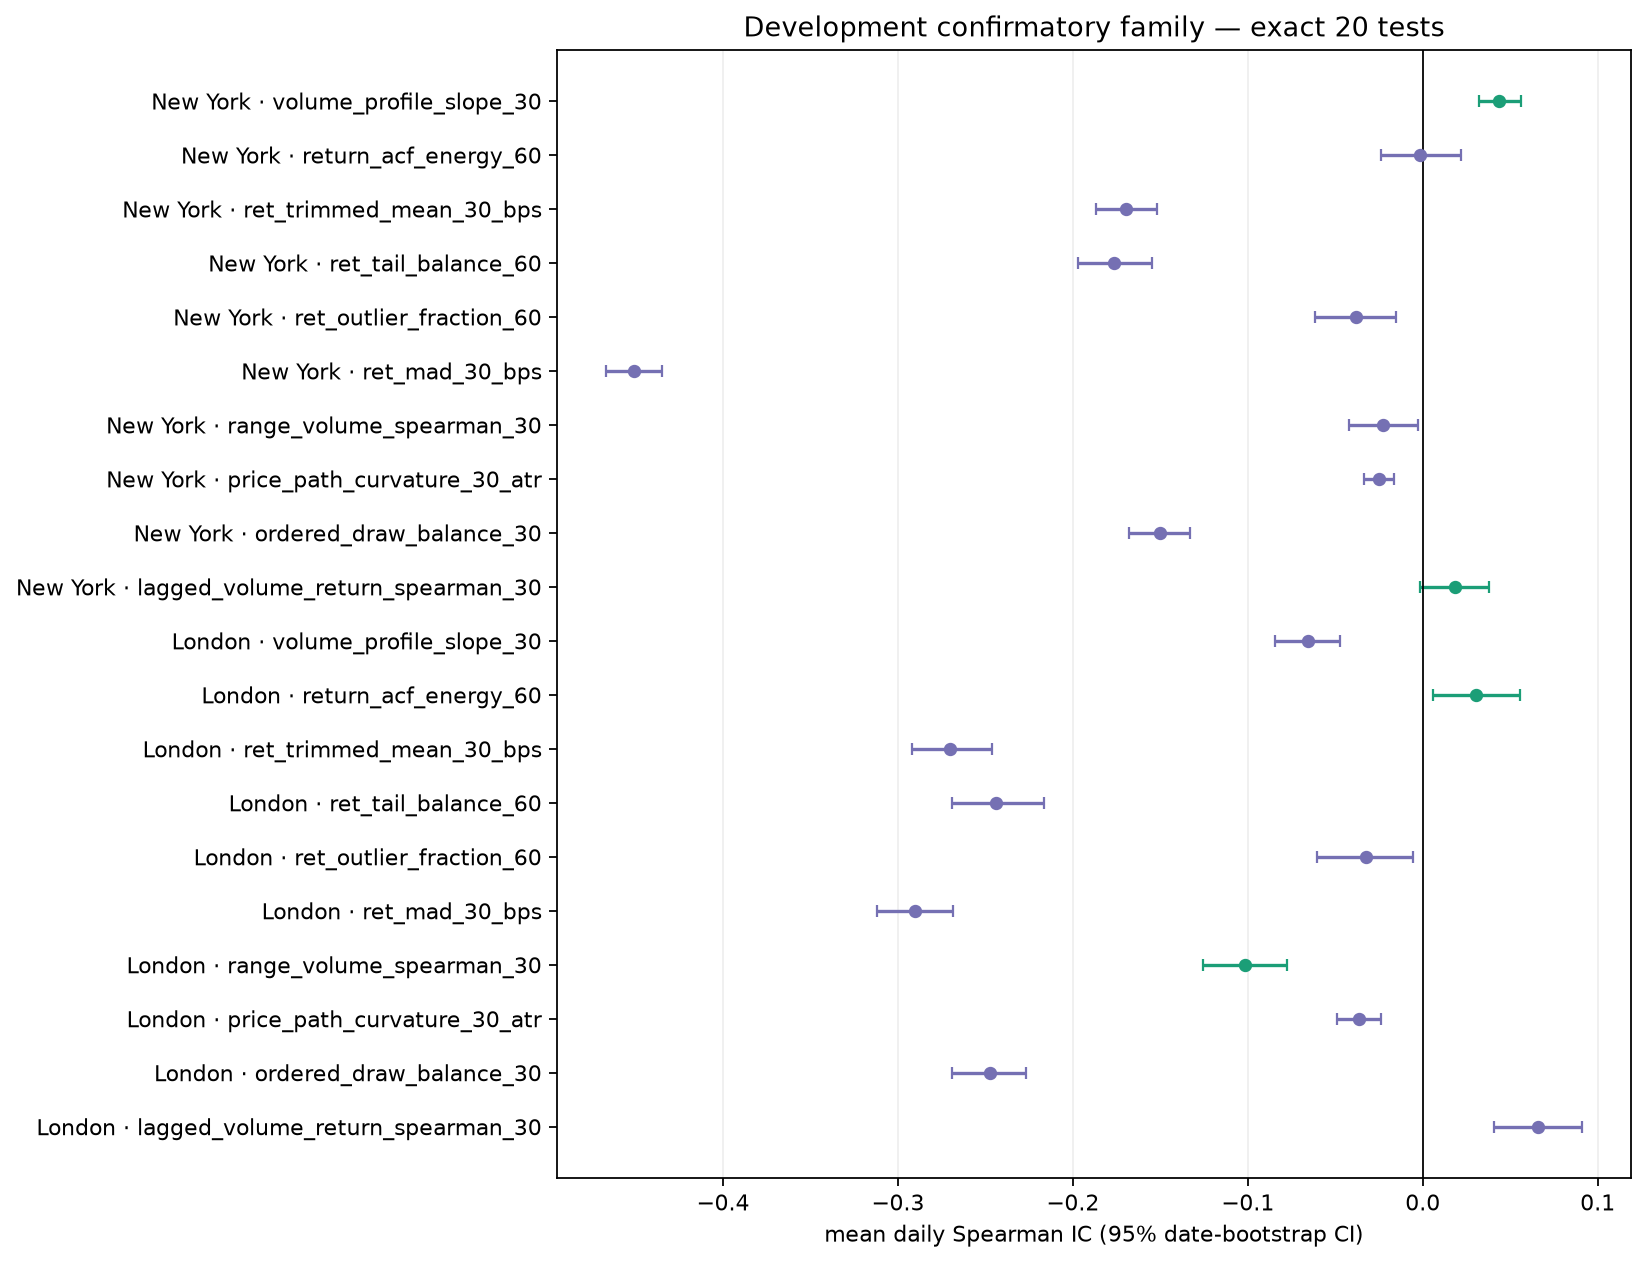

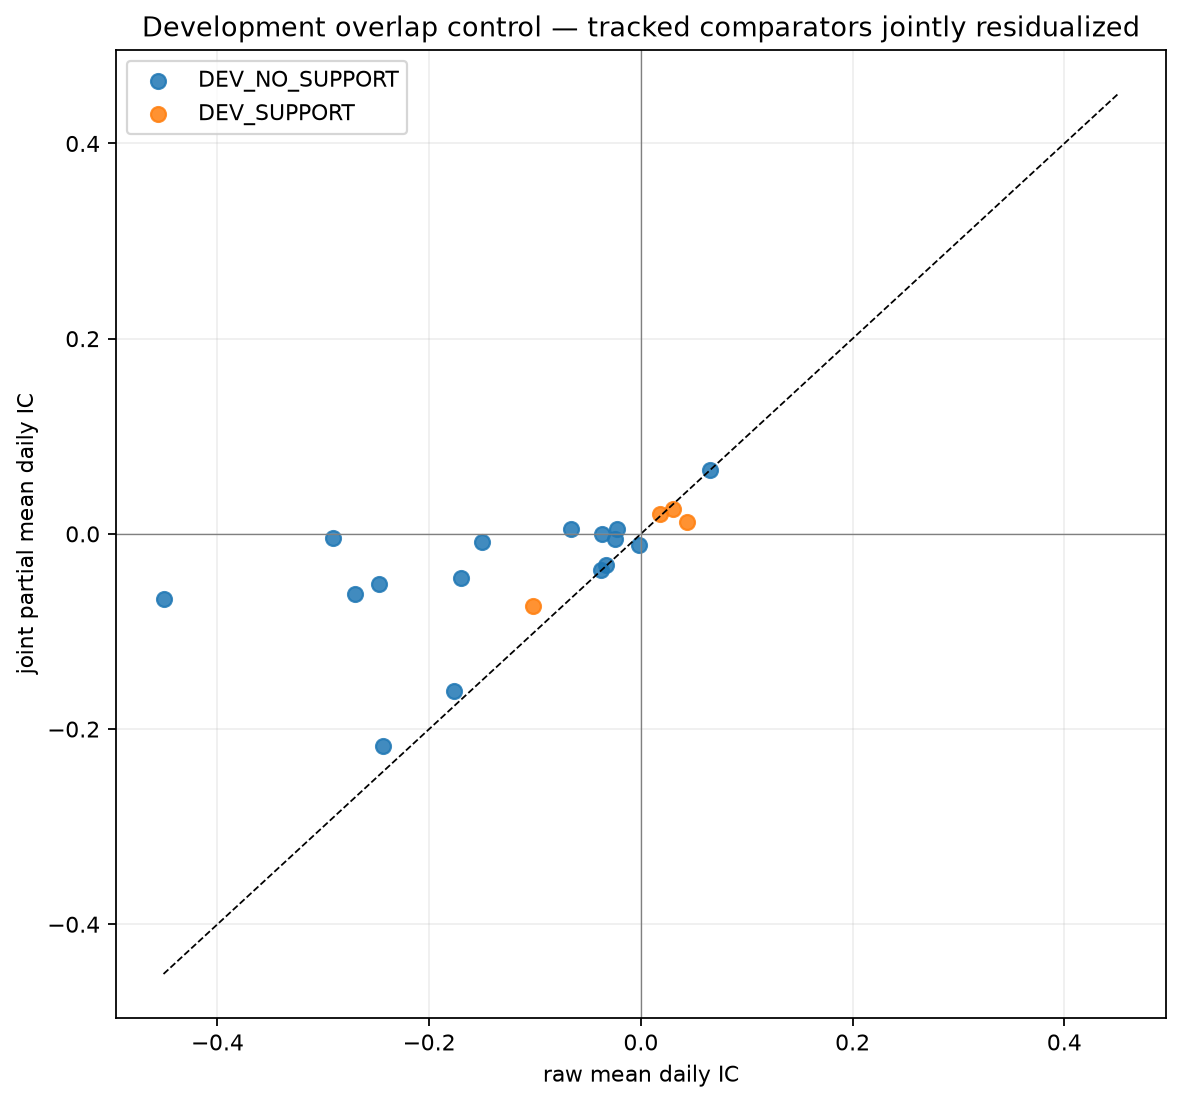

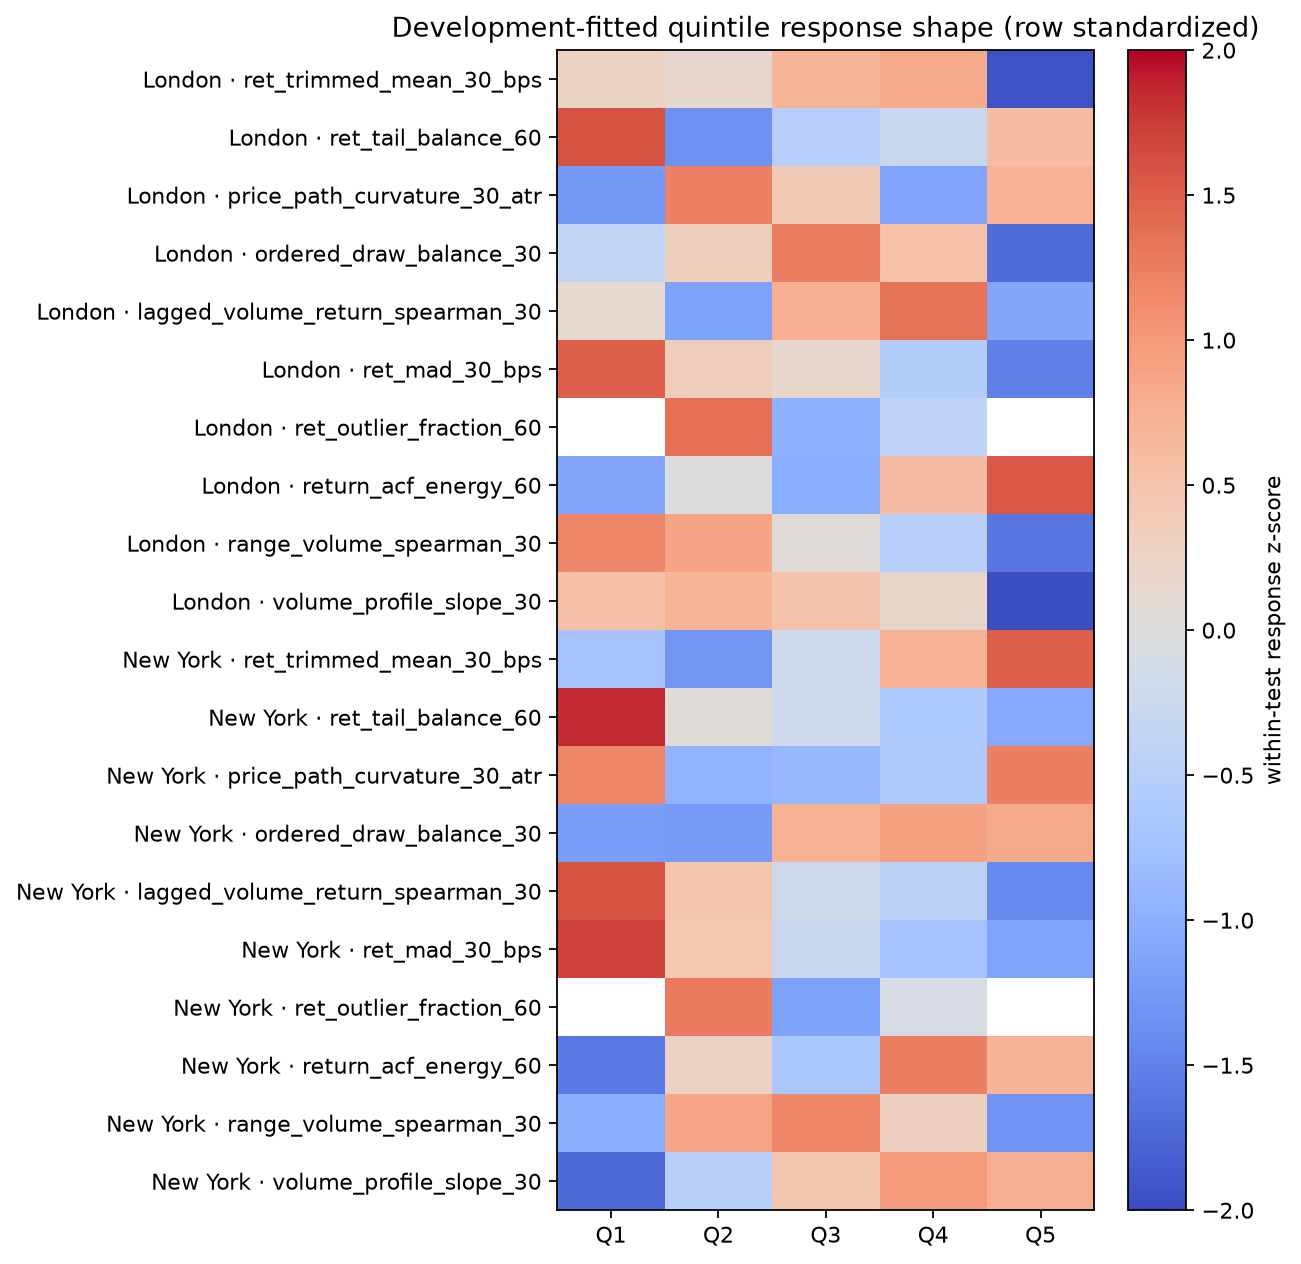

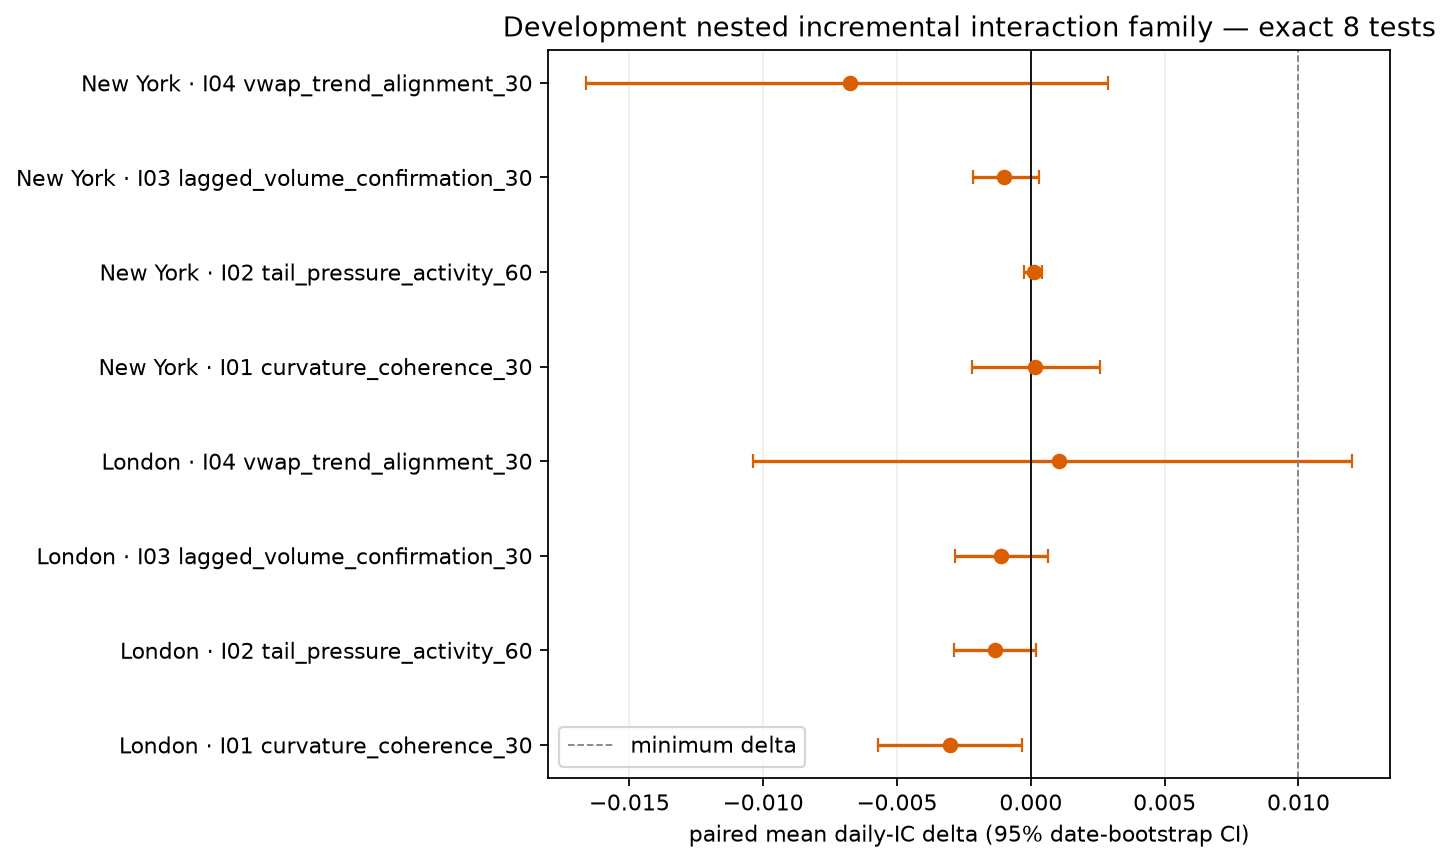

Section 4 artifact manifest: reports/statistical_research/fes_project1/v1/section4_hash_manifest.json
Modeling remains justified: True
Retrospective Validation/Historical Final rows accessed: 0


In [20]:
section4_data_dir = ROOT / DATA_NAMESPACE
section4_report_dir = ROOT / REPORT_NAMESPACE
section4_data_dir.mkdir(parents=True, exist_ok=True)
section4_report_dir.mkdir(parents=True, exist_ok=True)

section4_data_frames = {
    "section4_daily_ic_development.parquet": section4_result.daily_ic,
    "section4_quintile_edges_development.parquet": section4_result.quintile_edges,
    "section4_interaction_daily_delta_development.parquet": section4_result.interaction_daily_deltas,
    "section4_interaction_fold_audit_development.parquet": section4_result.interaction_fold_audit,
    "section4_interaction_tuning_audit_development.parquet": section4_result.interaction_tuning_audit,
    "section4_complete_trial_ledger.parquet": section4_result.complete_trial_ledger,
}
for filename, frame in section4_data_frames.items():
    write_parquet_exact(section4_data_dir / filename, frame)

section4_report_frames = {
    "section4_base_feature_evidence_development.csv": section4_result.base_feature_evidence,
    "section4_confirmatory_screen_development.csv": section4_result.confirmatory_results,
    "section4_exploratory_screen_development.csv": section4_result.exploratory_results,
    "section4_partial_ic_development.csv": section4_result.partial_ic_results,
    "section4_quintile_bucket_evidence_development.csv": section4_result.bucket_results,
    "section4_quintile_hashes_development.csv": quintile_hashes,
    "section4_interaction_incremental_development.csv": section4_result.interaction_results,
    "section4_stability_development.csv": section4_result.stability,
    "section4_distribution_stability_development.csv": section4_result.distribution_stability,
    "section4_integrity_audit_development.csv": section4_result.integrity_audit,
    "section4_correlations_existing85_development.csv": section4_result.correlations_with_existing,
    "section4_access_audit.csv": section4_result.access_audit,
    "section4_complete_trial_ledger.csv": section4_result.complete_trial_ledger,
    "section4_tests.csv": section4_test_table,
}
for filename, frame in section4_report_frames.items():
    write_text_exact(
        section4_report_dir / filename,
        frame.to_csv(index=False, lineterminator="\n"),
    )

section4_figures = {
    "section4_confirmatory_ic_development.png": figure_confirmatory,
    "section4_partial_ic_development.png": figure_partial,
    "section4_quintile_response_development.png": figure_buckets,
    "section4_interaction_incremental_development.png": figure_interactions,
}
section4_figure_paths = []
for filename, figure in section4_figures.items():
    buffer = BytesIO()
    figure.savefig(
        buffer,
        format="png",
        dpi=160,
        bbox_inches="tight",
        metadata={"Software": "Project 1 FES Section 4"},
    )
    path = section4_report_dir / filename
    write_bytes_exact(path, buffer.getvalue())
    section4_figure_paths.append(path)
    plt.close(figure)
assert len(section4_figure_paths) == 4

base_support_records = base_feature_evidence[[
    "trial_id", "feature_name", "session", "development_label", "failed_gates"
]].to_dict("records")
interaction_support_records = interaction_evidence[[
    "trial_id", "interaction_id", "session", "development_label", "failed_gates"
]].to_dict("records")
quintile_hash_records = quintile_hashes.to_dict("records")
modeling_justified = bool(
    base_feature_evidence["development_label"].eq("DEV_SUPPORT").any()
    or interaction_evidence["development_label"].eq(
        "DEV_INCREMENTAL_SUPPORT"
    ).any()
)
section4_checkpoint = {
    "schema_version": "1.0.0",
    "section_completed": 4,
    "section_5_started": False,
    "branch": GIT_BRANCH,
    "git_commit": GIT_COMMIT,
    "config_sha256": CONFIG_SHA256,
    "access_boundary": {
        "development_outcome_rows": len(section4_inputs.forward_labels),
        "retrospective_validation_outcome_rows": 0,
        "historical_final_outcome_rows": 0,
        "physical_development_filter_verified": True,
    },
    "multiplicity_families": {
        CONFIRMATORY_FAMILY: {
            "declared": 20,
            "raw_p_values": 20,
            "bh_q_values": 20,
        },
        EXPLORATORY_FAMILY: {
            "declared": 40,
            "raw_p_values": 40,
            "bh_q_values": 40,
            "advancement_role": False,
        },
        INTERACTION_FAMILY: {
            "declared": 8,
            "raw_p_values": 8,
            "bh_q_values": 8,
        },
    },
    "base_feature_support": base_support_records,
    "interaction_support": interaction_support_records,
    "frozen_quintile_hashes": quintile_hash_records,
    "trial_ledger": {
        "total_rows": len(section4_result.complete_trial_ledger),
        "section4_completed_rows": int(
            section4_result.complete_trial_ledger["notebook_section"].eq(4).sum()
        ),
        "later_planned_rows": int(
            (
                ~section4_result.complete_trial_ledger["notebook_section"].eq(4)
            ).sum()
        ),
    },
    "modeling_remains_justified": modeling_justified,
    "modeling_rule": (
        "Proceed with predeclared nested model ladder; Development labels do "
        "not alter frozen M2-M4 matrices."
    ),
    "focused_tests": section4_focused_test_output,
    "impact_analysis": {
        "load_forward_labels_for_evaluation": {
            "risk": "LOW",
            "direct_callers": 1,
            "affected_processes": 1,
            "affected_modules": 1,
            "shared_symbol_modified": False,
        },
        "_walk_forward_folds": {
            "risk": "LOW",
            "direct_callers": 2,
            "affected_processes": 1,
            "affected_modules": 1,
            "shared_symbol_modified": False,
        },
        "implementation": "additive fes_project1_modeling.py",
    },
}
section4_checkpoint_path = section4_report_dir / "section4_checkpoint.json"
write_text_exact(
    section4_checkpoint_path,
    json.dumps(section4_checkpoint, indent=2, sort_keys=True) + "\n",
)

section4_artifact_paths = [
    *[section4_data_dir / name for name in section4_data_frames],
    *[section4_report_dir / name for name in section4_report_frames],
    *section4_figure_paths,
    section4_checkpoint_path,
]
section4_artifact_hashes = {
    path.relative_to(ROOT).as_posix(): sha256_file(path)
    for path in section4_artifact_paths
}
section4_hash_manifest = {
    "schema_version": "1.0.0",
    "research_id": "fes_project1",
    "artifact_version": ARTIFACT_VERSION,
    "section": 4,
    "config_sha256": CONFIG_SHA256,
    "frozen_trial_ledger_sha256": TRIAL_LEDGER_SHA256,
    "artifacts": section4_artifact_hashes,
}
section4_manifest_path = section4_report_dir / "section4_hash_manifest.json"
write_text_exact(
    section4_manifest_path,
    json.dumps(section4_hash_manifest, indent=2, sort_keys=True) + "\n",
)
for relative_path, expected_hash in section4_artifact_hashes.items():
    assert sha256_file(ROOT / relative_path) == expected_hash

display(
    section4_result.complete_trial_ledger.groupby(
        ["notebook_section", "status"], observed=True, as_index=False
    ).size()
)
display(pd.DataFrame([
    {"artifact": relative_path, "sha256": digest}
    for relative_path, digest in section4_artifact_hashes.items()
]))
for figure_path in section4_figure_paths:
    display(Image(filename=str(figure_path)))
print(f"Section 4 artifact manifest: {section4_manifest_path.relative_to(ROOT).as_posix()}")
print(f"Modeling remains justified: {modeling_justified}")
print("Retrospective Validation/Historical Final rows accessed: 0")

### 4.5 Checkpoint 4

Section 4 is complete. All Development support and failure labels are mechanical
applications of the frozen gates. The full 20/40/8 family accounting, joint
partial IC, frozen quintiles and hashes, nested interaction deltas, stability,
integrity, all-85 redundancy inventory, and complete 150-row ledger are
persisted.

These results are Development evidence only. They do not finalize advancement,
remove terms from M2–M4, create a trading policy, or authorize a Validation read.
The predeclared nested modeling ladder remains the next permitted step.

# Section 5 - Development nested models and full policy freeze

Section 5 opens **Development outcomes only**. Retrospective Validation outcomes, Historical Final outcomes, and every GC/MGC economic result remain physically unread. All continuous comparisons use the frozen `FINAL_HEAD_TO_HEAD_SUPPORT`; broader scalar/profile coverage remains a secondary coverage diagnostic.

The exact date design is 252 training dates, one embargo date, and 63 outer assessment dates, stepping 64 dates; inner tuning uses 126 training dates, one embargo date, and 21 assessment dates, stepping 22. Target-exit purges are applied at `>=` the first assessment decision timestamp. The resulting six complete outer folds provide 378 OOF dates per session/target.

### 5.1 Development-only build, exact folds, and access boundary

The additive Section 5 engine fits M0-M8, S0-S2, P0-P3 PCA, target-specific P2 PLS, and all six declared expansion classifiers. Completed session/horizon caches are contractual checkpoints: they are reused only when the frozen numerical contract hash matches.

In [21]:
import hashlib
import joblib
from IPython.display import Image, Markdown

from src.statistical_research.fes_project1_nested import (  # noqa: E402
    Section5Config,
    build_section5_development,
    save_section5_outputs,
)

section5_config = Section5Config()
section5_result = build_section5_development(
    ROOT, config=section5_config, use_cache=True, progress=True,
)
section5_outputs = save_section5_outputs(section5_result, ROOT)

assert set(section5_result.access_audit.loc[
    section5_result.access_audit['outcomes_loaded'], 'partitions_loaded'
]) == {'Development'}
assert section5_result.access_audit.loc[
    section5_result.access_audit['source'].str.contains(
        'Validation|Historical Final|economic', case=False, regex=True
    ), 'rows_loaded'
].eq(0).all()
outer_fold_table = section5_result.fold_table.loc[
    section5_result.fold_table['level'].eq('outer')
].copy()
assert outer_fold_table['assessment_date_count'].eq(63).all()
assert outer_fold_table.groupby(['session', 'horizon_minutes']).size().eq(6).all()

print(f"Section 5 artifacts: {section5_outputs['artifact_count']}")
print(f"Manifest SHA-256: {section5_outputs['manifest_sha256']}")
print(f"Policy SHA-256: {section5_outputs['policy_sha256']}")
display(outer_fold_table[[
    'session', 'horizon_minutes', 'fold_id', 'train_date_count',
    'embargo_date', 'assessment_first_date', 'assessment_last_date',
    'purged_train_rows', 'fold_sha256',
]])
display(section5_result.support_coverage)
display(section5_result.access_audit)

Section 5 cache: loaded London h=60


Section 5 cache: loaded London h=30


Section 5 cache: loaded New York h=60


Section 5 cache: loaded New York h=30


Section 5 artifacts: 33
Manifest SHA-256: 5a5513722f49a552fa17793cc0a71fb831ea6897d29b9252a3839dc6db6e67c3
Policy SHA-256: 5ba74d5f44100be957254857f9b0aea51a95ab68f1260395667c991abc82c4fc


,session,horizon_minutes,fold_id,train_date_count,embargo_date,assessment_first_date,assessment_last_date,purged_train_rows,fold_sha256
0,London,60,0,252,2022-06-06,2022-06-07,2022-09-05,0,2cf545d9831f6da64708eb1923876ad20e50ed0d305e7f8157a45bb69981743e
6,London,60,1,316,2022-09-06,2022-09-07,2022-12-07,0,0ffafd7b2f47774cb6e79d07e524efaacb21ae6e14e8570fbb29717902436a05
15,London,60,2,380,2022-12-08,2022-12-09,2023-03-14,0,566a427900148d2a175217b5600c8757b2d3b107b1aee830268a9167a8e1eed1
27,London,60,3,444,2023-03-15,2023-03-16,2023-06-21,0,a39b7f6e24666b929291c267e55b6801945cb715ef2b59dede944fb57bca0ca2
42,London,60,4,508,2023-06-22,2023-06-23,2023-09-22,0,e55c2d4d8b72bdc1a85ab70f8c880a3df6d51487e3baf7d2259fa68bf82e0199
60,London,60,5,572,2023-09-25,2023-09-26,2023-12-27,0,70d7f042cb0291e814a8586d3a16c20fe4a5e31f7820d9012a84e3801e42fd70
81,London,30,0,252,2022-06-06,2022-06-07,2022-09-05,0,2cf545d9831f6da64708eb1923876ad20e50ed0d305e7f8157a45bb69981743e
87,London,30,1,316,2022-09-06,2022-09-07,2022-12-07,0,0ffafd7b2f47774cb6e79d07e524efaacb21ae6e14e8570fbb29717902436a05
96,London,30,2,380,2022-12-08,2022-12-09,2023-03-14,0,566a427900148d2a175217b5600c8757b2d3b107b1aee830268a9167a8e1eed1
108,London,30,3,444,2023-03-15,2023-03-16,2023-06-21,0,a39b7f6e24666b929291c267e55b6801945cb715ef2b59dede944fb57bca0ca2


,session,target,support_name,rows,dates,coverage_of_eligible,coverage_loss_rows
0,London,forward_return_60_atr,eligible_target,114488,638,1.000000,0
1,London,forward_return_60_atr,scalar_ladder,113966,638,0.995441,522
2,London,forward_return_60_atr,profile_ladder,114265,638,0.998052,223
3,London,forward_return_60_atr,FINAL_HEAD_TO_HEAD_SUPPORT,113966,638,0.995441,522
4,London,forward_return_30_atr,eligible_target,114682,638,1.000000,0
5,London,forward_return_30_atr,scalar_ladder,114130,638,0.995187,552
6,London,forward_return_30_atr,profile_ladder,114433,638,0.997829,249
7,London,forward_return_30_atr,FINAL_HEAD_TO_HEAD_SUPPORT,114130,638,0.995187,552
8,London,future_range_60_atr,eligible_target,114488,638,1.000000,0
9,London,future_range_60_atr,scalar_ladder,113966,638,0.995441,522


,source,read_scope,rows_loaded,partitions_loaded,outcomes_loaded
0,data/processed/statistical_research/fes_project1/v1/scalar_features_development_gc.par...,presealed Development scalar features,306230,Development,False
1,data/processed/statistical_research/fes_project1/v1/raw_profile_p0_development_gc.parquet,presealed Development raw P0 profiles,305667,Development,False
2,data/processed/statistical_research/feature_matrix_gc.parquet,physical parquet filter Development; projected anchors,306230,Development,False
3,data/processed/statistical_research/forward_labels_gc.parquet,physical parquet filter Development; projected 30/60 labels,306230,Development,True
4,retrospective Validation outcomes,not opened; locked until Section 6 batch,0,,False
5,Historical Final outcomes,not opened; locked,0,,False
6,GC/MGC economic outcomes,not opened; prohibited in Section 5,0,,False


### 5.2 Progressive M0-M8 comparison, nested complexity, and stability

Every model family is tuned only on the inner folds belonging to its outer training set. M4 uses elastic net solely to propose support, applies correlation-cluster substitution and hierarchical closure, and scores a ridge fit. M8 independently derives scalar additions and selects PCA versus PLS within every outer training set. Constant M4 attempts with no finite inner IC remain completed, non-selectable ledger entries rather than receiving an invented fallback.

The same-size sanity check keeps D1/O1 fixed and draws exactly 100 hierarchy-closed subsets per outer fold with seed `20260726 + 1000*outer_fold_id + draw_id`. It is diagnostic only.

In [22]:
selected_continuous = section5_result.continuous_model_comparison.loc[
    section5_result.continuous_model_comparison['selected_primary_family']
].copy()
selected_columns = [
    'session', 'target', 'model_family', 'daily_ic_mean',
    'daily_ic_ci_low', 'daily_ic_ci_high',
    'paired_daily_ic_delta_mean', 'paired_delta_ci_low', 'paired_delta_ci_high',
    'valid_oof_dates', 'quarter_same_sign_fraction',
    'largest_positive_quarter_share', 'best_10_positive_delta_share',
    'modal_complexity_fraction', 'component_count',
    'component_within_two_fraction', 'complexity_stable',
    'development_model_gate_pass',
]
display(selected_continuous[selected_columns])

stable_terms = section5_result.elastic_stability.loc[
    section5_result.elastic_stability['stable_term']
].copy()
display(stable_terms[[
    'session', 'target', 'feature_name', 'selection_frequency',
    'sign_agreement', 'median_standardized_coefficient',
    'coefficient_q25', 'coefficient_q75', 'interaction_parent_rule',
]])

random_subset_summary = (
    section5_result.random_subset_diagnostics
    .groupby(['session', 'target', 'outer_fold_id'], as_index=False)
    .agg(
        selected_unit_count=('selected_unit_count', 'first'),
        selected_subset_percentile=('selected_subset_percentile', 'first'),
        selected_outer_daily_ic=('selected_outer_daily_ic', 'first'),
        random_outer_daily_ic_mean=('random_outer_daily_ic', 'mean'),
    )
)
display(random_subset_summary)

outer_profile_diagnostics = section5_result.profile_diagnostics.loc[
    section5_result.profile_diagnostics['diagnostic_scope'].isin([
        'OUTER_TRAIN_FULL_PCA', 'OUTER_TRAIN_P2_PLS'
    ])
].copy()
profile_summary = (
    outer_profile_diagnostics
    .groupby(
        ['session', 'horizon_minutes', 'target', 'profile_family',
         'profile_representation'], dropna=False, as_index=False,
    )
    .agg(
        outer_folds=('outer_fold_id', 'nunique'),
        components_80_median=('components_for_80pct_variance', 'median'),
        components_90_median=('components_for_90pct_variance', 'median'),
        components_95_median=('components_for_95pct_variance', 'median'),
        loading_cosine_mean=('loading_cosine_mean_vs_previous_outer', 'mean'),
        loading_cosine_min=('loading_cosine_min_vs_previous_outer', 'min'),
        all_converged=('converged', 'all'),
    )
)
display(profile_summary)

,session,target,model_family,daily_ic_mean,daily_ic_ci_low,daily_ic_ci_high,paired_daily_ic_delta_mean,paired_delta_ci_low,paired_delta_ci_high,valid_oof_dates,quarter_same_sign_fraction,largest_positive_quarter_share,best_10_positive_delta_share,modal_complexity_fraction,component_count,component_within_two_fraction,complexity_stable,development_model_gate_pass
8,London,forward_return_30_atr,M8,0.035623,0.014574,0.055487,0.009203,-0.002031,0.020362,378,0.571429,0.439663,0.173037,1.000000,2,1.0,True,False
17,London,forward_return_60_atr,M8,0.009381,-0.021269,0.040360,0.048675,0.016826,0.081043,378,0.571429,0.438264,0.161856,0.666667,2,1.0,True,False
19,London,future_range_60_atr,M1,0.447132,0.422600,0.471342,0.000000,0.000000,0.000000,378,NaN,NaN,NaN,0.833333,0,1.0,True,False
29,New York,forward_return_30_atr,M1,0.117552,0.093736,0.142591,0.000000,0.000000,0.000000,378,NaN,NaN,NaN,1.000000,0,1.0,True,False
38,New York,forward_return_60_atr,M1,0.172917,0.149017,0.196908,0.000000,0.000000,0.000000,378,NaN,NaN,NaN,1.000000,0,1.0,True,False
50,New York,future_range_60_atr,M3,0.634872,0.615311,0.655053,0.001151,-0.001144,0.003470,378,0.571429,0.437103,0.199700,1.000000,0,1.0,True,False


,session,target,feature_name,selection_frequency,sign_agreement,median_standardized_coefficient,coefficient_q25,coefficient_q75,interaction_parent_rule
37,London,forward_return_60_atr,range_volume_spearman_30,0.833333,1.0,-0.043610,-0.048610,-0.039383,True
41,London,forward_return_60_atr,ret_outlier_fraction_60,1.000000,1.0,0.062831,0.059122,0.063524,True
55,London,future_range_60_atr,atr_ratio_20_60,1.000000,1.0,-0.078567,-0.081881,-0.075864,True
59,London,future_range_60_atr,efficiency_ratio_15,1.000000,1.0,0.106413,0.060402,0.130721,True
62,London,future_range_60_atr,lagged_volume_return_spearman_30,1.000000,1.0,0.092334,0.088590,0.094148,True
66,London,future_range_60_atr,ols_r_squared_30,1.000000,1.0,0.025374,0.023286,0.025457,True
67,London,future_range_60_atr,ordered_draw_balance_30,1.000000,1.0,0.031346,0.029395,0.032032,True
68,London,future_range_60_atr,price_path_curvature_30_atr,1.000000,1.0,-0.032043,-0.050319,-0.026549,True
69,London,future_range_60_atr,range_volume_spearman_30,1.000000,1.0,0.056126,0.055246,0.056144,True
71,London,future_range_60_atr,relative_volume_20,1.000000,1.0,-0.643542,-0.669751,-0.632182,True


,session,target,outer_fold_id,selected_unit_count,selected_subset_percentile,selected_outer_daily_ic,random_outer_daily_ic_mean
0,London,forward_return_60_atr,0,2,93.0,-0.027132,-0.092247
1,London,forward_return_60_atr,1,3,100.0,-0.076943,-0.175319
2,London,forward_return_60_atr,2,2,100.0,-0.059276,-0.125344
3,London,forward_return_60_atr,3,2,83.0,0.032095,0.023254
4,London,forward_return_60_atr,4,2,32.0,0.007252,0.020951
5,London,forward_return_60_atr,5,1,29.0,0.192901,0.206569
6,London,future_range_60_atr,0,7,28.0,0.376662,0.380391
7,London,future_range_60_atr,1,6,45.0,0.430797,0.431122
8,London,future_range_60_atr,2,6,81.0,0.436956,0.434407
9,London,future_range_60_atr,3,6,48.0,0.501127,0.501330


,session,horizon_minutes,target,profile_family,profile_representation,outer_folds,components_80_median,components_90_median,components_95_median,loading_cosine_mean,loading_cosine_min,all_converged
0,London,30.0,OUTCOME_FREE,PCA,P0,6,51.0,61.0,73.0,0.941210,-0.731379,True
1,London,30.0,OUTCOME_FREE,PCA,P1,6,51.0,61.0,74.0,0.639343,-0.999940,True
2,London,30.0,OUTCOME_FREE,PCA,P2,6,39.0,51.0,60.0,0.456851,-0.999621,True
3,London,30.0,OUTCOME_FREE,PCA,P3,6,29.0,46.0,60.0,0.825988,-0.998818,True
4,London,30.0,forward_return_30_atr,PLS,P2,6,NaN,NaN,NaN,0.648036,-0.933772,True
5,London,60.0,OUTCOME_FREE,PCA,P0,6,51.0,61.0,73.0,0.941030,-0.736485,True
6,London,60.0,OUTCOME_FREE,PCA,P1,6,51.0,61.0,74.0,0.639664,-0.999940,True
7,London,60.0,OUTCOME_FREE,PCA,P2,6,39.0,51.0,60.0,0.485289,-0.999613,True
8,London,60.0,OUTCOME_FREE,PCA,P3,6,29.0,46.0,60.0,0.823581,-0.998809,True
9,London,60.0,forward_return_60_atr,PLS,P2,6,NaN,NaN,NaN,0.602444,-0.935482,True


### 5.3 Outer-OOF predictive and classifier evidence

Continuous evidence reports date-block IC and paired anchor deltas, ATR/tick errors, concordance, calibration, deciles, directional confusion, subperiods, and concentration. Expansion labels are reconstructed from the applicable inner/outer training-only 80th percentile of `future_range_60_atr`; the classifier is probability-only and cannot create long/short direction.

,session,target,model_family,rows,valid_oof_dates,daily_ic_mean,daily_ic_ci_low,daily_ic_ci_high,anchor_daily_ic_mean,paired_daily_ic_delta_mean,...,concordance_correlation,calibration_intercept,calibration_slope,sign_accuracy_nonzero,balanced_accuracy_nonzero,short_correct_tn,false_long_fp,false_short_fn,long_correct_tp,best_10_positive_delta_share
0,London,forward_return_30_atr,M8,67749,378,0.035623,0.014574,0.055487,0.026420,0.009203,...,-0.000282,0.014765,-0.271145,0.502422,0.500449,21565.0,11920.0,20951.0,11626.0,0.173037
1,London,forward_return_60_atr,M8,67722,378,0.009381,-0.021269,0.040360,-0.039294,0.048675,...,-0.000904,0.018350,-0.207171,0.495484,0.495936,22295.0,10887.0,22681.0,10672.0,0.161856
2,London,future_range_60_atr,M1,67722,378,0.447132,0.422600,0.471342,0.447132,0.000000,...,0.172023,0.713786,0.883438,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,New York,forward_return_30_atr,M1,113238,378,0.117552,0.093736,0.142591,0.117552,0.000000,...,0.000408,-0.038953,0.492251,0.501486,0.503200,22807.0,33827.0,21692.0,33043.0,NaN
4,New York,forward_return_60_atr,M1,113171,378,0.172917,0.149017,0.196908,0.172917,0.000000,...,-0.000384,-0.031572,-0.293965,0.500371,0.502044,24765.0,32533.0,23383.0,31234.0,NaN
5,New York,future_range_60_atr,M3,113171,378,0.634872,0.615311,0.655053,0.633720,0.001151,...,0.383447,-0.209694,1.029692,NaN,NaN,NaN,NaN,NaN,NaN,0.199700


,session,model_family,rows,valid_oof_dates,event_prevalence,roc_auc,pr_auc,brier_score,prevalence_baseline_brier,o1_baseline_brier,...,paired_log_loss_delta_ci_high,calibration_intercept,calibration_slope,development_probability_p80,p80_flagged_rows,p80_precision,p80_recall,p80_lift,selected_expansion_family,validation_gate_status
2,London,M1_O1,67722,378,0.175334,0.634121,0.258856,0.141178,0.145201,0.141178,...,0.0,-0.323607,0.912596,0.274541,13545,0.286896,0.327270,1.636276,True,PENDING_LOCKED_SECTION_6
8,New York,M1_O1,113171,378,0.212192,0.805120,0.500931,0.133148,0.167315,0.133148,...,0.0,-0.096875,0.947019,0.422523,22635,0.512216,0.482802,2.413923,True,PENDING_LOCKED_SECTION_6


,session,threshold_role,quantile,value,fit_partition,fit_rows,fit_dates,model_family,activated_for_policy
0,London,direction_absolute_prediction_p90,0.9,0.439427,Development outer OOF,67722,378,M8,False
1,London,expansion_probability_p80,0.8,0.274541,Development outer OOF,67722,378,M1_O1,False
2,New York,direction_absolute_prediction_p90,0.9,0.320785,Development outer OOF,113171,378,M1,False
3,New York,expansion_probability_p80,0.8,0.422523,Development outer OOF,113171,378,M1_O1,False


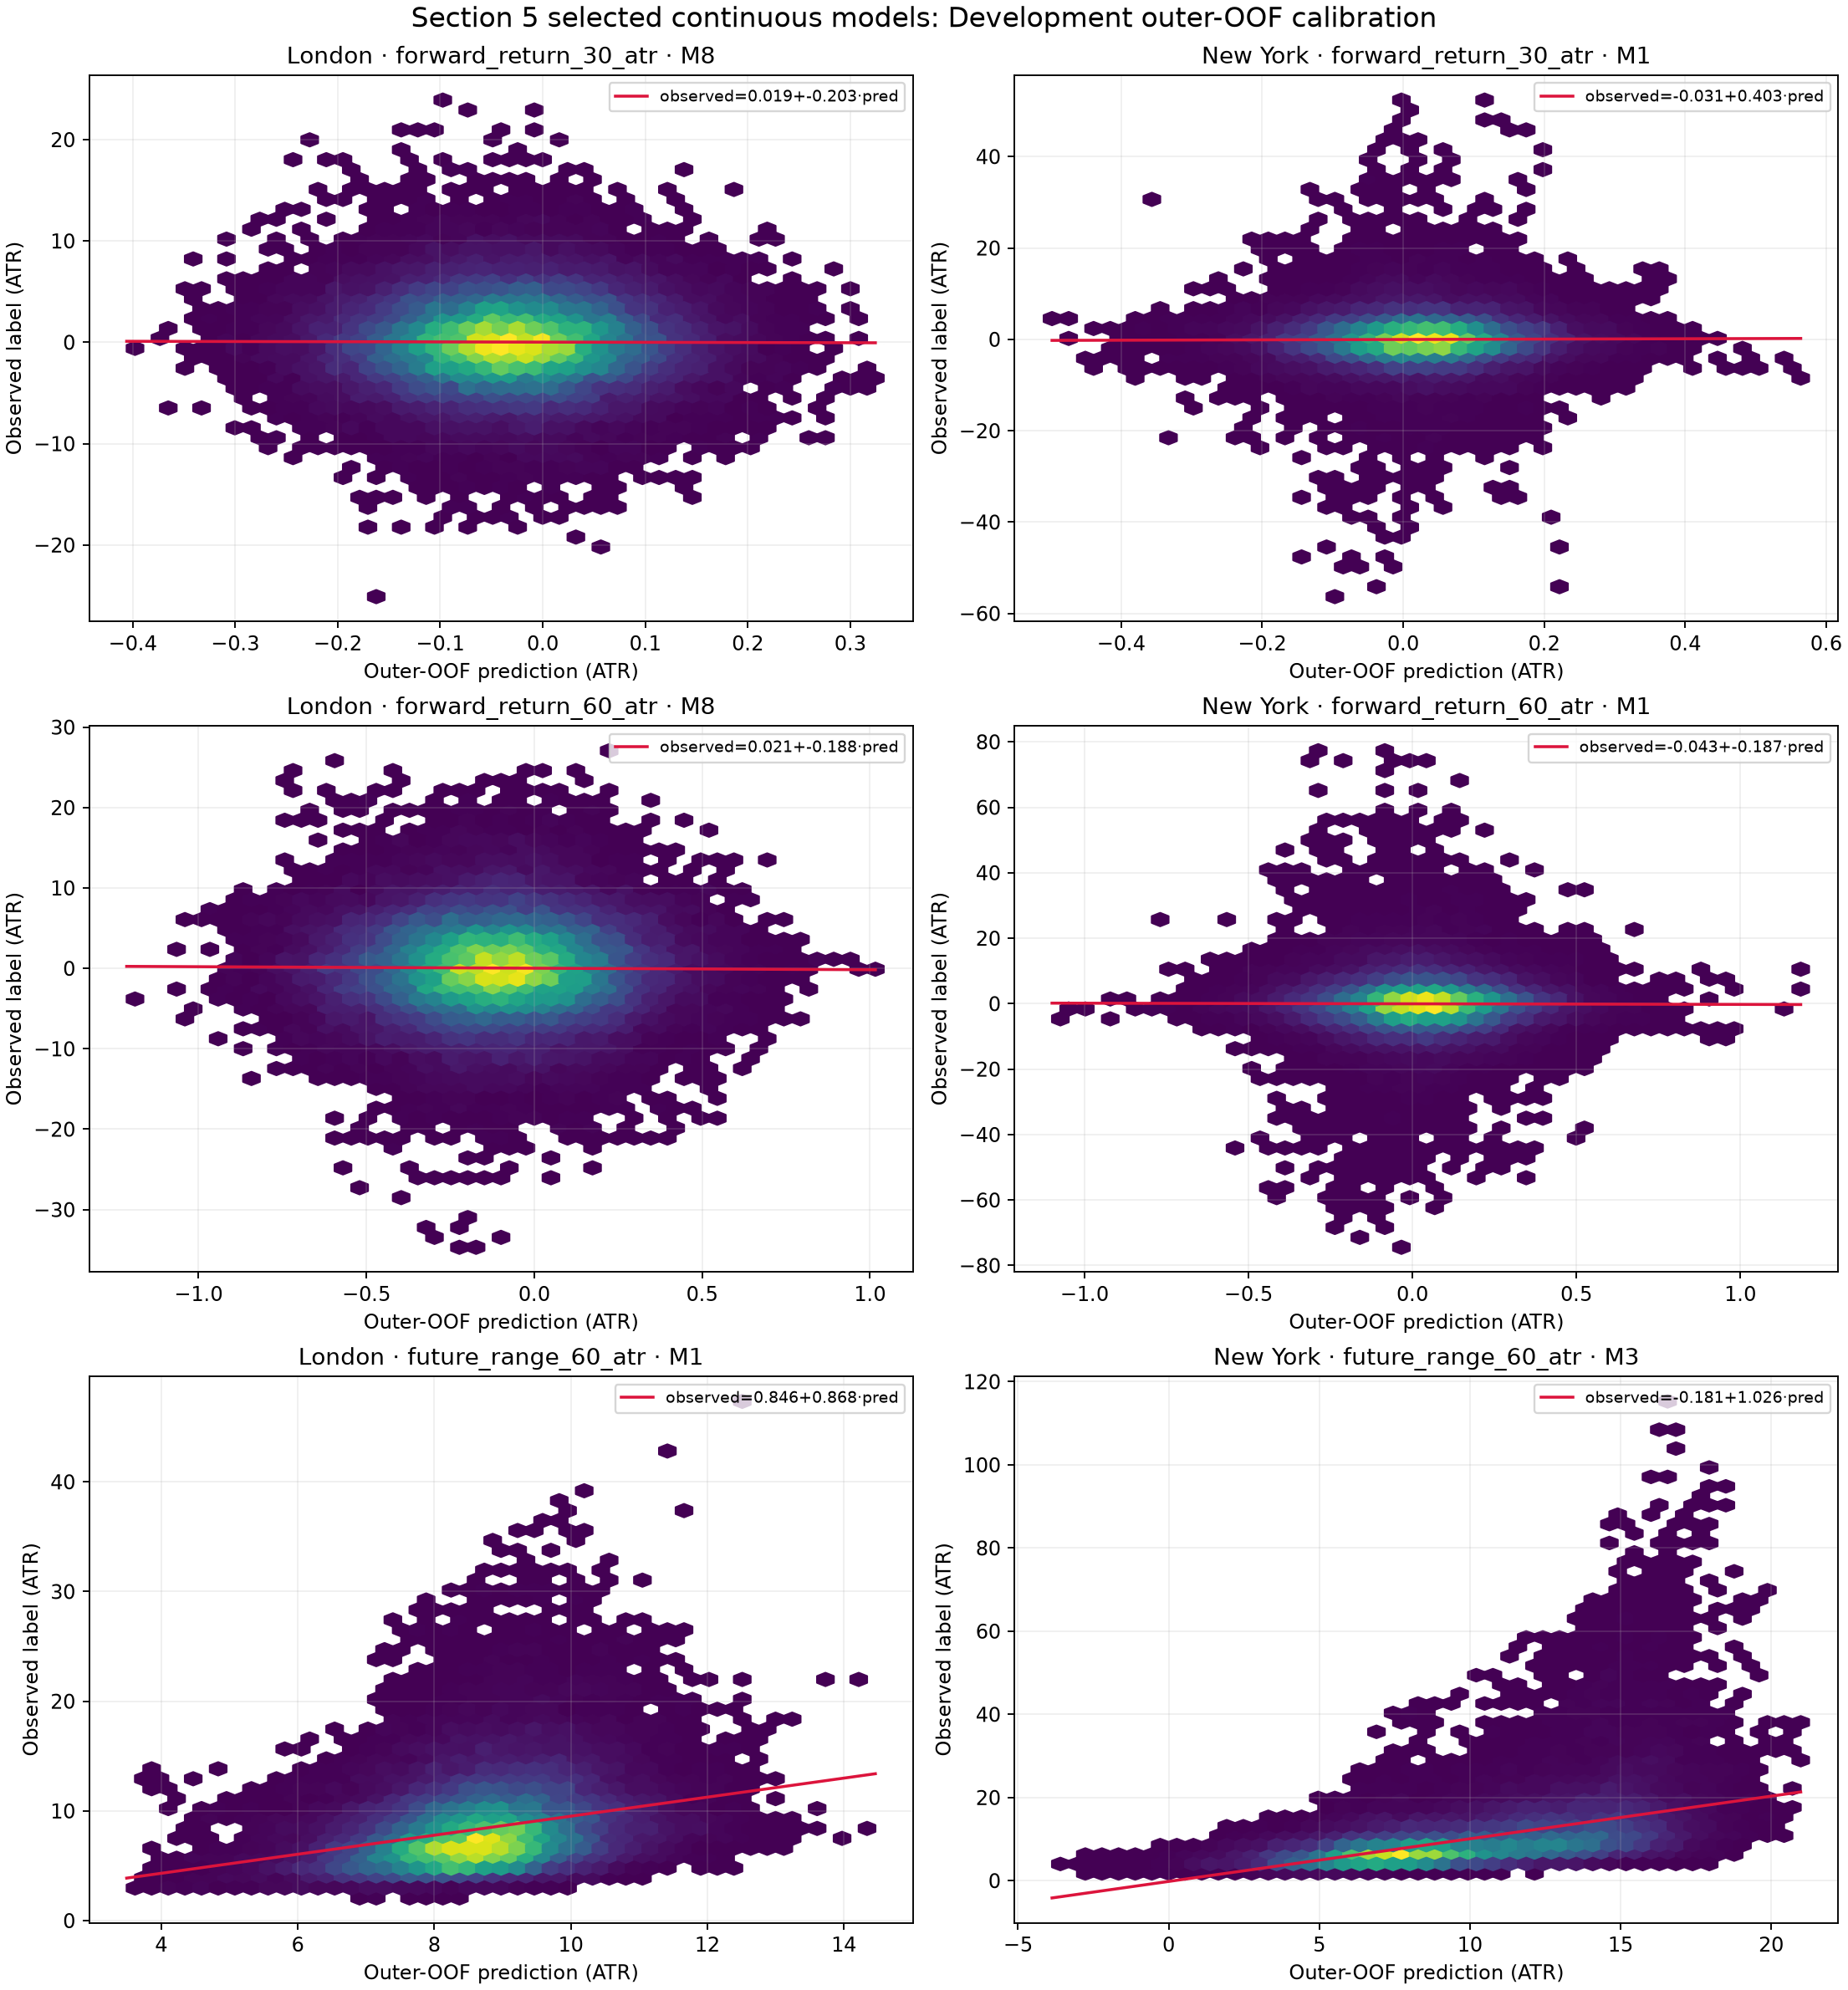

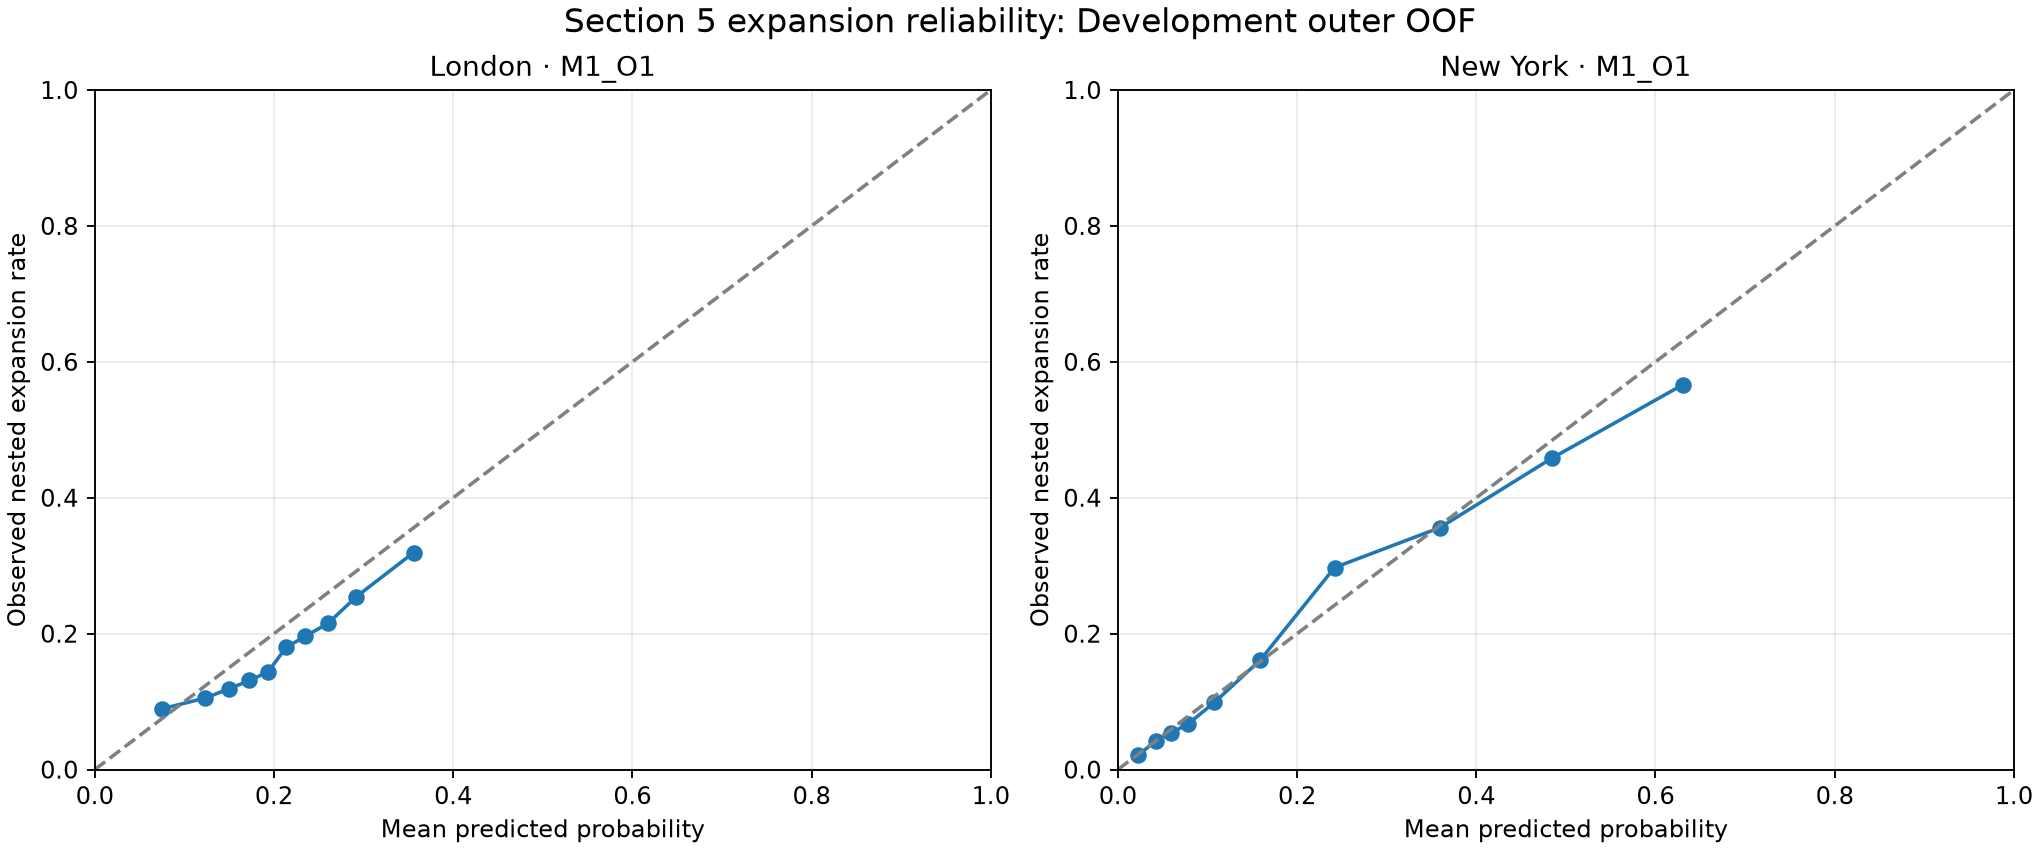

In [23]:
selected_metric_keys = selected_continuous[
    ['session', 'target', 'model_family']
]
selected_metrics = section5_result.continuous_metrics.merge(
    selected_metric_keys,
    on=['session', 'target', 'model_family'],
    how='inner', validate='one_to_one',
)
display(selected_metrics)
selected_expansion = section5_result.expansion_metrics.loc[
    section5_result.expansion_metrics['selected_expansion_family']
].copy()
display(selected_expansion)
display(section5_result.frozen_thresholds)

display(Image(filename=str(
    ROOT / REPORT_NAMESPACE / 'section5_continuous_oof_calibration.png'
)))
display(Image(filename=str(
    ROOT / REPORT_NAMESPACE / 'section5_expansion_reliability.png'
)))

### 5.4 Frozen all-Development objects, numerical thresholds, and no-policy decision

One all-Development object is serialized for each selected session/target continuous model and each selected session expansion classifier. Numerical p90/p80 thresholds are fitted only from selected Development outer-OOF predictions. They are retained for complete trial accounting but remain inactive when the directional model gate fails.

No P&L, Sharpe ratio, cost result, or GC/MGC economic outcome is computed in this section.

In [24]:
section5_report_dir = ROOT / REPORT_NAMESPACE
section5_data_dir = ROOT / DATA_NAMESPACE
checkpoint5 = json.loads(
    (section5_report_dir / 'section5_checkpoint.json').read_text(encoding='utf-8')
)
manifest5_path = section5_report_dir / 'section5_hash_manifest.json'
policy5_path = section5_data_dir / 'section5_pre_validation_policy.json'
assert sha256_file(manifest5_path) == checkpoint5['frozen_hashes']['section5_manifest_sha256']
policy5 = json.loads(policy5_path.read_text(encoding='utf-8'))
policy_hash_payload = dict(policy5)
reported_policy_hash = policy_hash_payload.pop('pre_validation_policy_sha256')
recomputed_policy_hash = hashlib.sha256(
    json.dumps(policy_hash_payload, sort_keys=True, separators=(',', ':'), ensure_ascii=False).encode('utf-8')
).hexdigest()
assert recomputed_policy_hash == reported_policy_hash
assert reported_policy_hash == checkpoint5['frozen_hashes']['pre_validation_policy_sha256']
assert checkpoint5['retrospective_validation_outcomes_read'] is False
assert checkpoint5['historical_final_outcomes_read'] is False
assert checkpoint5['gc_mgc_economics_read'] is False
assert checkpoint5['continuous_models_attempted'] == 54
assert checkpoint5['expansion_models_attempted'] == 12
assert checkpoint5['policy_freezes_attempted'] == 2
assert checkpoint5['policy_status'] == 'FROZEN_NO_POLICY'
assert section5_result.complete_trial_ledger.loc[
    section5_result.complete_trial_ledger['notebook_section'].eq(5), 'status'
].eq('COMPLETE').sum() == 68

reloaded_models = joblib.load(section5_data_dir / 'section5_frozen_models.joblib')
assert set(reloaded_models['continuous']) == set(section5_result.frozen_continuous_models)
assert set(reloaded_models['expansion']) == set(section5_result.frozen_expansion_models)
for key, model in section5_result.frozen_continuous_models.items():
    reloaded = reloaded_models['continuous'][key]
    assert reloaded.configuration == model.configuration
    assert reloaded.input_schema_sha256 == model.input_schema_sha256
for key, model in section5_result.frozen_expansion_models.items():
    reloaded = reloaded_models['expansion'][key]
    assert reloaded.configuration == model.configuration
    assert reloaded.input_schema_sha256 == model.input_schema_sha256

print(checkpoint5['no_policy_reason'])
print('Exact locked Validation batch command:')
print(checkpoint5['exact_locked_validation_batch_command'])
display(section5_result.frozen_model_registry)
display(Markdown(
    f"**Checkpoint 5:** `{checkpoint5['status']}`  \n"
    f"Policy: `{checkpoint5['policy_status']}`  \n"
    f"Manifest: `{checkpoint5['frozen_hashes']['section5_manifest_sha256']}`  \n"
    f"Policy hash: `{reported_policy_hash}`"
))

NO_DIRECTIONAL_MODEL_HAS_COMPLETE_DEVELOPMENT_SUPPORT: the exact six outer folds provide 378 valid OOF dates per session, below the frozen 400-date model gate.
Exact locked Validation batch command:
.\.venv\Scripts\python.exe scripts\run_fes_project1_research.py --section 6 --non-interactive --section5-manifest-sha256 5a5513722f49a552fa17793cc0a71fb831ea6897d29b9252a3839dc6db6e67c3 --policy-sha256 5ba74d5f44100be957254857f9b0aea51a95ab68f1260395667c991abc82c4fc


,model_key,model_role,session,target,model_family,configuration_json,configuration_sha256,input_schema_sha256,fit_rows,fit_dates,coefficient_sha256,transform_state_sha256,validation_status,expansion_range_threshold_atr
0,london|forward_return_30_atr,continuous,London,forward_return_30_atr,M8,"{""component_count"":2,""preprocessing"":""S0"",""profile_family"":""PLS"",""profile_representati...",6b7d4fbf04ecfe7b30e7d5daaf38e130bd7bd7a8f08b56d9003cf3e22e5ceb64,00b5e4eedd9f278a841098ebac55498bffba52ff5286289163bb6e6a044df5bc,114130,638,295bca622acef59e94d4f457f9e542aaf653b9fd9bca70a994eb0c5faa7fc019,e483bae3335223f718c183727727b6ea49ad944ff8f5b6c45802d80353cdab42,UNREAD,NaN
1,london|forward_return_60_atr,continuous,London,forward_return_60_atr,M8,"{""component_count"":2,""preprocessing"":""S1"",""profile_family"":""PLS"",""profile_representati...",20b1095a8dc095ca52c36f5fbb7e0fbd91afcf3da9f51bd5a37691986cc607a7,179ddb68e9897538af406958cc64e87457d994af98e63d34bfff7c87f4d5d607,113966,638,ba157d1e366811fbb3f4f1df3b904133fb75cd1f50cf0c2c9314e97310b68b0b,8371d18fa9e280c79ff0a65203d16d0fb3f62baec4c53022005512a5772405e4,UNREAD,NaN
2,london|future_range_60_atr,continuous,London,future_range_60_atr,M1,"{""preprocessing"":""S1"",""ridge_alpha"":0.0001,""scalar_columns"":[""atr_20"",""atr_ratio_20_60...",9257ec8a2fd63f36700e45989c0b5226f2a24e490934ea9c9551d849c4b54ad8,bf2d6af3bd3fdf0f742ba0296432ff712f5de62743ad1399eb6a64eadfe6def3,113966,638,2c747f52e26dcc2345cddd82f34bf36873577b7f9b9c2fceefb767c6511cf5e5,58d2c2eeca5e7f087b5337a0da5ffd6a3e89377a895dc1cf51ad6f0c0763456a,UNREAD,NaN
3,new_york|forward_return_30_atr,continuous,New York,forward_return_30_atr,M1,"{""preprocessing"":""S0"",""ridge_alpha"":0.0001,""scalar_columns"":[""return_5m_atr"",""return_1...",68dda9ff0bf22f7ea859a2b5e7675c4d7a19f46a04f9c2bf44d0a094e37301b5,f2730ddbbaf7e8ffd68358760ca2a02cdea11187d7feb48d3cb62c99cea0d0cf,190871,638,ecf8b77eb2abb88554d4f0c7873861119c8e1f5ddab1f24827f09cfa436b631b,18574866111e3231b2c8361b80da184a25aa04dcba45a7fac0b0cb442b018b01,UNREAD,NaN
4,new_york|forward_return_60_atr,continuous,New York,forward_return_60_atr,M1,"{""preprocessing"":""S0"",""ridge_alpha"":0.0001,""scalar_columns"":[""return_5m_atr"",""return_1...",68dda9ff0bf22f7ea859a2b5e7675c4d7a19f46a04f9c2bf44d0a094e37301b5,f2730ddbbaf7e8ffd68358760ca2a02cdea11187d7feb48d3cb62c99cea0d0cf,190718,638,373cfa3b8004b213f603b8ee9ad90ec5c07da9b1bf510e256867cbb82e156b4f,62f505aa95b106bc68b096a3b02b838f748d7f6eceacd7f6027dcc6203941092,UNREAD,NaN
5,new_york|future_range_60_atr,continuous,New York,future_range_60_atr,M3,"{""preprocessing"":""S1"",""ridge_alpha"":0.0001,""scalar_columns"":[""atr_20"",""atr_ratio_20_60...",6e8e391d840a4091e1ee066383955594e3dd92f32d12130f2917cb8163b1f78a,a7251678c40bca36daab192d8f3f2b9d7bec2313230080cdda1d9f4511241b41,190718,638,14dafdd07753e0cad05438e6604a29f8cab468307573ac29c42dc1a922d9b744,c81843b61453aea5b3582683c60ae32038b94fedce5e2293cb11adb7c857ec53,UNREAD,NaN
6,london|expansion_label_60,expansion_classifier,London,expansion_label_60,M1_O1,"{""C"":0.01,""preprocessing"":""S0"",""scalar_columns"":[""atr_20"",""atr_ratio_20_60"",""atr_ratio...",e2e3af3efa6a6e590fae4fc2be8da016e85ce5c7988afc7a127824137ed592bf,bf2d6af3bd3fdf0f742ba0296432ff712f5de62743ad1399eb6a64eadfe6def3,113966,638,e7bf2843a98cb54485e79b0151ab3620f9e31d48565a979aceb989638e67f0b4,cafe842311f40dd58e1f5cdb21f65a1a70791677d74778c59ba7100ec46da030,UNREAD,10.752688
7,new_york|expansion_label_60,expansion_classifier,New York,expansion_label_60,M1_O1,"{""C"":0.01,""preprocessing"":""S1"",""scalar_columns"":[""atr_20"",""atr_ratio_20_60"",""atr_ratio...",561d1c8445d284ced19dbc6446fc5d1df9219f86c8946d5c9401fd3702f2dfb5,bf2d6af3bd3fdf0f742ba0296432ff712f5de62743ad1399eb6a64eadfe6def3,190718,638,07cb444fb25ace9fc1062bce8f78b6ba049b26169eb5aada46e4e3847e11c537,c1b4f45a4a546a38ceade6b733959a7546a62edf5270dd49854ba9a77cb759e6,UNREAD,12.608696


**Checkpoint 5:** `COMPLETED_STOP_BEFORE_SECTION_6`  
Policy: `FROZEN_NO_POLICY`  
Manifest: `5a5513722f49a552fa17793cc0a71fb831ea6897d29b9252a3839dc6db6e67c3`  
Policy hash: `5ba74d5f44100be957254857f9b0aea51a95ab68f1260395667c991abc82c4fc`

### 5.5 Checkpoint 5 - stop before retrospective Validation

Section 5 is complete. All 54 continuous models, 12 expansion classifiers, and two policy-freeze trials have completed Development accounting. London 60-minute direction selected a stable combined scalar-plus-P2-PLS M8 and showed a positive paired Development IC delta versus D1; New York retained D1/M1. Neither session can pass the frozen directional advancement contract because the exact complete outer-fold design yields only 378 OOF dates versus the required 400, and no-policy is therefore frozen mechanically.

The session-specific numerical p90/p80 values, all-Development model objects, complete transform state, cost/sequencing/evaluation configuration, policy hash, artifact manifest, and exact locked Section 6 command are saved. **Stop here. Do not open retrospective Validation or inspect economics before explicit Section 6 authorization.**

# Section 6 - Single locked Validation batch and GC economics

The exact Section 5 command was executed once outside the notebook after all 33 frozen artifacts, the policy, model bundle, and base configuration hashes passed. The batch opened 118,076 retrospective Validation rows from 2024, scored the unchanged frozen objects, applied the Development-fitted quintiles and p90/p80 values, and wrote an immutable completion hash without an intermediate choice or refit.

Historical Final remains unread. Because Section 5 froze `FROZEN_NO_POLICY`, the batch did not open GC/MGC economic bars or manufacture direction from the unsigned opportunity model.


### 6.1 One-time completion, hashes, and access boundary

The cells below only reload the completed immutable batch. They do not rerun Validation, refit a model, or alter a result.


In [25]:
section6_report_dir = ROOT / REPORT_NAMESPACE
section6_data_dir = ROOT / DATA_NAMESPACE
completion6_path = section6_report_dir / 'section6_batch_completion.json'
checkpoint6_path = section6_report_dir / 'section6_checkpoint.json'
manifest6_path = section6_report_dir / 'section6_hash_manifest.json'
completion6 = json.loads(completion6_path.read_text(encoding='utf-8'))
checkpoint6 = json.loads(checkpoint6_path.read_text(encoding='utf-8'))
manifest6 = json.loads(manifest6_path.read_text(encoding='utf-8'))

assert completion6['status'] == 'COMPLETED_ONE_TIME_LOCKED_BATCH'
assert checkpoint6['single_locked_validation_batch_completed'] is True
assert checkpoint6['retrospective_validation_outcomes_read'] is True
assert checkpoint6['historical_final_outcomes_read'] is False
assert checkpoint6['gc_economic_bars_read'] is False
assert checkpoint6['gc_economics_executed'] is False
assert sha256_file(manifest6_path) == completion6['section6_manifest_sha256']
for artifact in manifest6['artifacts']:
    path = ROOT / artifact['path']
    assert path.stat().st_size == artifact['bytes']
    assert sha256_file(path) == artifact['sha256']

section6_access = pd.read_csv(section6_report_dir / 'section6_access_audit.csv')
assert section6_access.loc[
    section6_access['source'].eq('Historical Final outcomes'), 'rows_loaded'
].eq(0).all()
assert section6_access.loc[
    section6_access['source'].eq('GC/MGC economic bars'), 'rows_loaded'
].eq(0).all()

print(f"Section 6 artifacts verified: {len(manifest6['artifacts'])}")
print(f"Batch completion SHA-256: {completion6['batch_completion_sha256']}")
print(f"Section 6 manifest SHA-256: {completion6['section6_manifest_sha256']}")
display(section6_access)


Section 6 artifacts verified: 26
Batch completion SHA-256: 72ff658248cae3b6408641c8b08316c5878623d826b16f896cfaf4dd24c4d32f
Section 6 manifest SHA-256: d496653b5ff6a26dc8f69c2c7d9c91031e3c9c49eada20452ce58e613ba1a2ab


,source,read_scope,rows_loaded,partitions_loaded,outcomes_loaded
0,data/processed/statistical_research/fes_project1/v1/scalar_features_validation_sealed_...,presealed outcome-free Validation scalar features,118076,Validation,False
1,data/processed/statistical_research/fes_project1/v1/raw_profile_p0_validation_sealed_g...,presealed outcome-free Validation P0 profiles,117712,Validation,False
2,data/processed/statistical_research/feature_matrix_gc.parquet,physical parquet filter Validation; projected inputs,118076,Validation,False
3,data/processed/statistical_research/forward_labels_gc.parquet,single locked physical Validation outcome read,118076,Validation,True
4,Historical Final outcomes,not opened; no Final projection exists,0,NaN,False
5,GC/MGC economic bars,not opened because frozen policy is ineligible,0,NaN,False


### 6.2 Final feature and interaction gates

Four preregistered base-feature/session hypotheses meet every frozen Development-plus-Validation feature gate. This is feature evidence, not a directional trading policy. No interaction meets the joint incremental gate.


In [26]:
feature_gates6 = pd.read_csv(section6_report_dir / 'section6_final_feature_gates.csv')
interaction_gates6 = pd.read_csv(section6_report_dir / 'section6_final_interaction_gates.csv')
feature_advancers6 = feature_gates6.loc[
    feature_gates6['final_feature_label'].eq('FEATURE_ADVANCES')
].copy()
interaction_advancers6 = interaction_gates6.loc[
    interaction_gates6['final_interaction_label'].eq('INTERACTION_ADVANCES')
].copy()

assert len(feature_gates6) == 20
assert len(feature_advancers6) == 4
assert len(interaction_gates6) == 8
assert interaction_advancers6.empty
display(feature_advancers6[[
    'session', 'feature_name', 'target',
    'development_daily_ic_mean', 'validation_daily_ic_mean',
    'validation_daily_ic_ci_low', 'validation_daily_ic_ci_high',
    'validation_partial_absolute_retention',
    'development_top_bottom_spread_ticks',
    'validation_top_bottom_spread_ticks',
    'final_feature_label',
]])
display(interaction_gates6[[
    'session', 'interaction_name',
    'development_mean_daily_ic_delta',
    'validation_mean_daily_ic_delta',
    'validation_delta_ci_low', 'validation_delta_ci_high',
    'failed_gates', 'final_interaction_label',
]])


,session,feature_name,target,development_daily_ic_mean,validation_daily_ic_mean,validation_daily_ic_ci_low,validation_daily_ic_ci_high,validation_partial_absolute_retention,development_top_bottom_spread_ticks,validation_top_bottom_spread_ticks,final_feature_label
7,London,return_acf_energy_60,future_range_60_atr,0.030571,0.034511,-0.009141,0.076238,0.741011,0.122409,1.778692,FEATURE_ADVANCES
8,London,range_volume_spearman_30,future_range_60_atr,-0.101875,-0.072502,-0.111937,-0.036844,0.537515,4.480957,2.102769,FEATURE_ADVANCES
14,New York,lagged_volume_return_spearman_30,forward_return_60_atr,0.018339,0.031421,-0.002457,0.063081,1.047930,-2.863811,-5.129849,FEATURE_ADVANCES
19,New York,volume_profile_slope_30,future_range_60_atr,0.043675,0.039834,0.020772,0.059800,0.515444,4.226198,2.773759,FEATURE_ADVANCES


,session,interaction_name,development_mean_daily_ic_delta,validation_mean_daily_ic_delta,validation_delta_ci_low,validation_delta_ci_high,failed_gates,final_interaction_label
0,London,curvature_coherence_30,-0.003003,-0.001099,-0.002060,-1.138445e-04,gate_development_incremental_support|gate_validation_delta|gate_validation_ci_above_zero,INTERACTION_DOES_NOT_ADVANCE
1,London,tail_pressure_activity_60,-0.001341,-0.000529,-0.001084,4.697542e-07,gate_development_incremental_support|gate_validation_delta|gate_validation_ci_above_zero,INTERACTION_DOES_NOT_ADVANCE
2,London,lagged_volume_confirmation_30,-0.001120,-0.001729,-0.003563,4.186393e-05,gate_development_incremental_support|gate_validation_delta|gate_validation_ci_above_zero,INTERACTION_DOES_NOT_ADVANCE
3,London,vwap_trend_alignment_30,0.001043,-0.015028,-0.034011,3.344264e-03,gate_development_incremental_support|gate_validation_delta|gate_validation_ci_above_zero,INTERACTION_DOES_NOT_ADVANCE
4,New York,curvature_coherence_30,0.000166,0.001204,-0.002218,4.408112e-03,gate_development_incremental_support|gate_validation_delta|gate_validation_ci_above_zero,INTERACTION_DOES_NOT_ADVANCE
5,New York,tail_pressure_activity_60,0.000102,0.000020,-0.000596,6.018606e-04,gate_development_incremental_support|gate_validation_delta|gate_validation_ci_above_zero,INTERACTION_DOES_NOT_ADVANCE
6,New York,lagged_volume_confirmation_30,-0.000986,0.000516,-0.001702,2.478692e-03,gate_development_incremental_support|gate_validation_delta|gate_validation_ci_above_zero,INTERACTION_DOES_NOT_ADVANCE
7,New York,vwap_trend_alignment_30,-0.006756,-0.001133,-0.021482,2.058425e-02,gate_development_incremental_support|gate_validation_delta|gate_validation_ci_above_zero,INTERACTION_DOES_NOT_ADVANCE


### 6.3 Frozen-model Validation evidence and fixed score thresholds

All six selected continuous objects have positive retrospective Validation IC, but none passes the complete advancement contract. London M8 loses paired IC to D1 on both directional horizons in Validation; the other selected objects are anchors or show no qualifying incremental improvement. Every comparison also retains only 378 Development OOF dates versus the required 400.

The expansion classifiers remain useful descriptive opportunity scores but are ineligible: they are the O1 anchor (zero paired improvement), and their frozen session-specific training thresholds do not match the authoritative single Development-wide expansion-label threshold.


In [27]:
continuous_validation6 = pd.read_csv(
    section6_report_dir / 'section6_validation_continuous_metrics.csv'
)
model_gates6 = pd.read_csv(section6_report_dir / 'section6_final_model_gates.csv')
expansion_validation6 = pd.read_csv(
    section6_report_dir / 'section6_validation_expansion_metrics.csv'
)
candidate_counts6 = pd.read_csv(section6_report_dir / 'section6_candidate_counts.csv')

assert len(continuous_validation6) == 6
assert not model_gates6['model_advances'].astype(bool).any()
assert not expansion_validation6['classifier_advances'].astype(bool).any()
assert not expansion_validation6['threshold_contract_match'].astype(bool).any()
assert not candidate_counts6['policy_execution_allowed'].astype(bool).any()
display(model_gates6[[
    'session', 'target', 'model_family',
    'development_daily_ic_mean', 'development_paired_delta',
    'development_valid_dates', 'validation_daily_ic_mean',
    'validation_daily_ic_ci_low', 'validation_daily_ic_ci_high',
    'validation_paired_delta', 'validation_paired_delta_ci_low',
    'validation_paired_delta_ci_high', 'validation_valid_dates',
    'failed_gates', 'model_advances',
]])
display(expansion_validation6)
display(candidate_counts6)


,session,target,model_family,development_daily_ic_mean,development_paired_delta,development_valid_dates,validation_daily_ic_mean,validation_daily_ic_ci_low,validation_daily_ic_ci_high,validation_paired_delta,validation_paired_delta_ci_low,validation_paired_delta_ci_high,validation_valid_dates,failed_gates,model_advances
0,London,forward_return_30_atr,M8,0.035623,0.009203,378,0.198829,0.177374,0.220879,-0.027014,-0.032855,-0.020725,246,gate_development_delta|gate_development_delta_ci|gate_validation_delta|gate_validation...,False
1,London,forward_return_60_atr,M8,0.009381,0.048675,378,0.072638,0.038957,0.107594,-0.039829,-0.068551,-0.011162,245,gate_validation_delta|gate_validation_delta_ci|gate_development_dates|gate_quarter_sta...,False
2,London,future_range_60_atr,M1,0.447132,0.000000,378,0.429844,0.397415,0.463479,0.000000,0.000000,0.000000,245,gate_development_delta|gate_development_delta_ci|gate_validation_delta|gate_validation...,False
3,New York,forward_return_30_atr,M1,0.117552,0.000000,378,0.068051,0.041300,0.095216,0.000000,0.000000,0.000000,246,gate_development_delta|gate_development_delta_ci|gate_validation_delta|gate_validation...,False
4,New York,forward_return_60_atr,M1,0.172917,0.000000,378,0.133756,0.101915,0.165271,0.000000,0.000000,0.000000,246,gate_development_delta|gate_development_delta_ci|gate_validation_delta|gate_validation...,False
5,New York,future_range_60_atr,M3,0.634872,0.001151,378,0.627334,0.602418,0.652379,0.001185,-0.001230,0.003549,246,gate_development_delta|gate_development_delta_ci|gate_validation_delta|gate_validation...,False


,session,model_family,partition,rows,valid_dates,event_prevalence,roc_auc,pr_auc,brier_score,prevalence_baseline_brier,...,development_probability_p80,p80_flagged_rows,p80_precision,p80_recall,p80_lift,authoritative_range_threshold_atr,model_training_range_threshold_atr,threshold_contract_match,classifier_advances,classifier_verdict
0,London,M1_O1,Retrospective Validation,43927,245,0.164204,0.659798,0.273834,0.131024,0.137365,...,0.274541,4277,0.324293,0.192292,1.974935,11.797753,10.752688,False,False,CLASSIFIER_INELIGIBLE_OR_NO_INCREMENTAL_VALUE
1,New York,M1_O1,Retrospective Validation,73482,246,0.230152,0.798627,0.534161,0.146546,0.177504,...,0.422523,6623,0.635966,0.249054,2.763246,11.797753,12.608696,False,False,CLASSIFIER_INELIGIBLE_OR_NO_INCREMENTAL_VALUE


,partition,session,policy_variant,evaluation_rows,evaluation_dates,direction_score_flags,expansion_score_flags,candidate_flags,direction_threshold_p90,expansion_threshold_p80,policy_execution_allowed,policy_status
0,Development outer OOF,London,direction_only_p90,67722,378,6773,13545,6773,0.439427,0.274541,False,FROZEN_NO_POLICY
1,Development outer OOF,London,direction_p90_and_expansion_p80,67722,378,6773,13545,1183,0.439427,0.274541,False,FROZEN_NO_POLICY
2,Development outer OOF,New York,direction_only_p90,113171,378,11318,22635,11318,0.320785,0.422523,False,FROZEN_NO_POLICY
3,Development outer OOF,New York,direction_p90_and_expansion_p80,113171,378,11318,22635,2067,0.320785,0.422523,False,FROZEN_NO_POLICY
4,Retrospective Validation,London,direction_only_p90,43927,245,148,4277,148,0.439427,0.274541,False,FROZEN_NO_POLICY
5,Retrospective Validation,London,direction_p90_and_expansion_p80,43927,245,148,4277,10,0.439427,0.274541,False,FROZEN_NO_POLICY
6,Retrospective Validation,New York,direction_only_p90,73482,246,1668,6623,1668,0.320785,0.422523,False,FROZEN_NO_POLICY
7,Retrospective Validation,New York,direction_p90_and_expansion_p80,73482,246,1668,6623,237,0.320785,0.422523,False,FROZEN_NO_POLICY


### 6.4 GC economics, Sharpe, and exact verdict

The p90/p80 exceedance counts are retained for trial accounting, but they are inactive scores—not tradable candidates—because no 60-minute directional model passes. Therefore zero policies are sequenced, all three cost scenarios are explicitly not applicable, drawdown and daily-net-R Sharpe are undefined, the max-Sharpe adjusted p-value has a policy-family size of zero, and the GC gate cannot permit MGC work.


In [28]:
gc_economics6 = pd.read_csv(section6_report_dir / 'section6_gc_economics.csv')
gc_drawdown6 = pd.read_csv(section6_report_dir / 'section6_gc_drawdown.csv')
sharpe6 = pd.read_csv(section6_report_dir / 'section6_daily_net_r_sharpe.csv')
gc_verdict6 = pd.read_csv(section6_report_dir / 'section6_gc_gate_verdict.csv')

assert gc_economics6['executed_trades'].eq(0).all()
assert gc_economics6['mean_net_r'].isna().all()
assert gc_drawdown6['maximum_drawdown_r'].isna().all()
assert sharpe6['daily_net_r_sharpe'].isna().all()
assert sharpe6['policies_in_family'].eq(0).all()
assert not gc_verdict6['gc_economics_executed'].astype(bool).any()
assert not gc_verdict6['mgc_work_permitted'].astype(bool).any()
assert gc_verdict6.loc[0, 'headline_verdict'] == 'PREDICTIVE_ONLY_NOT_DIRECTIONAL'
display(gc_economics6)
display(gc_drawdown6)
display(sharpe6)
display(gc_verdict6)
display(Markdown(
    f"**Checkpoint 6:** `{checkpoint6['status']}`  \n"
    f"Batch: `{completion6['batch_completion_sha256']}`  \n"
    f"Verdict: `{gc_verdict6.loc[0, 'headline_verdict']}`  \n"
    f"MGC work permitted: `{bool(gc_verdict6.loc[0, 'mgc_work_permitted'])}`"
))


,policy_variant,partition,cost_scenario,round_trip_cost_ticks,cost_assumption_type,evaluation_dates_available,executed_trades,gross_expectancy_ticks,net_expectancy_ticks,mean_net_r,net_r_ci_low,net_r_ci_high,profit_factor,total_net_r,economics_status
0,direction_only_p90,Development outer OOF,frictionless,0.0,proxy assumption; not a fill model,378,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
1,direction_only_p90,Development outer OOF,base,2.6,proxy assumption; not a fill model,378,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
2,direction_only_p90,Development outer OOF,pessimistic,4.6,proxy assumption; not a fill model,378,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
3,direction_only_p90,Retrospective Validation,frictionless,0.0,proxy assumption; not a fill model,246,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
4,direction_only_p90,Retrospective Validation,base,2.6,proxy assumption; not a fill model,246,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
5,direction_only_p90,Retrospective Validation,pessimistic,4.6,proxy assumption; not a fill model,246,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
6,direction_p90_and_expansion_p80,Development outer OOF,frictionless,0.0,proxy assumption; not a fill model,378,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
7,direction_p90_and_expansion_p80,Development outer OOF,base,2.6,proxy assumption; not a fill model,378,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
8,direction_p90_and_expansion_p80,Development outer OOF,pessimistic,4.6,proxy assumption; not a fill model,378,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
9,direction_p90_and_expansion_p80,Retrospective Validation,frictionless,0.0,proxy assumption; not a fill model,246,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE


,policy_variant,partition,maximum_drawdown_r,time_under_water_dates,pnl_concentration_top_10_dates,worst_1pct_daily_net_r,worst_5pct_daily_net_r,worst_10pct_daily_net_r,break_even_round_trip_cost_ticks,drawdown_status
0,direction_only_p90,Development outer OOF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
1,direction_only_p90,Retrospective Validation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
2,direction_p90_and_expansion_p80,Development outer OOF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
3,direction_p90_and_expansion_p80,Retrospective Validation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE


,policy_variant,partition,daily_net_r_sharpe,sharpe_ci_low,sharpe_ci_high,max_sharpe_adjusted_p_value,policies_in_family,policy_family_names,sharpe_status
0,direction_only_p90,Development outer OOF,NaN,NaN,NaN,NaN,0,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
1,direction_only_p90,Retrospective Validation,NaN,NaN,NaN,NaN,0,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
2,direction_p90_and_expansion_p80,Development outer OOF,NaN,NaN,NaN,NaN,0,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE
3,direction_p90_and_expansion_p80,Retrospective Validation,NaN,NaN,NaN,NaN,0,NaN,NOT_APPLICABLE_NO_DIRECTIONAL_MODEL_PASSED_FROZEN_GATE


,policy_status,directional_model_gate_pass_count,policies_sequenced,gc_economics_executed,gc_strategy_gate_pass,mgc_work_permitted,gc_gate_verdict,headline_verdict,reason
0,FROZEN_NO_POLICY,0,0,False,False,False,GC_GATE_NOT_APPLICABLE_NO_DIRECTIONAL_MODEL,PREDICTIVE_ONLY_NOT_DIRECTIONAL,NO_DIRECTIONAL_MODEL_HAS_COMPLETE_DEVELOPMENT_SUPPORT: the exact six outer folds provi...


**Checkpoint 6:** `COMPLETED_STOP_BEFORE_SECTION_7`  
Batch: `72ff658248cae3b6408641c8b08316c5878623d826b16f896cfaf4dd24c4d32f`  
Verdict: `PREDICTIVE_ONLY_NOT_DIRECTIONAL`  
MGC work permitted: `False`

### 6.5 Checkpoint 6 - stop before MGC transfer

The one-time retrospective Validation batch is complete. Four base-feature hypotheses survive their frozen evidence gates, but no interaction, continuous model, classifier, or directional policy advances. GC economics and Sharpe are not applicable under the preregistered no-direction rule; no economic bar was opened, and the GC gate does not permit Section 7 MGC work.

Headline verdict: **`PREDICTIVE_ONLY_NOT_DIRECTIONAL`**.

**Stop here. Historical Final remains unread. Do not begin MGC transfer before explicit Section 7 authorization.**
